<h1 style="color:blue; font-size:20pt; font-weight:bold;font-family: 'Times New Roman', Times, serif;"> TP 3: ELEVAGE PASTORAL </h1>

## Préparation de l'environnement stata

In [110]:
#pip install stata_setup

In [111]:
#pip install ipywidgets

In [112]:
import warnings
warnings.filterwarnings("ignore")

In [113]:
%%capture
# Spécifier le chemin pour son executable stata
import stata_setup
stata_setup.config("C:/Users/SMART/Desktop/Stata17","se")


<h2 style="color:blue; font-size:18pt; font-weight:bold;font-family: 'Times New Roman', Times, serif;"> PARTIE 1: PREPARATION ET NETTOYAGE DES DONNEES </h2>

### **Définition de l'environnement de travail**
Il sera question dans cette partie d'executer le fichier de nettoyage partagé `1. cleaning.do`, et de le commenter

In [114]:
%%stata
*## DEFINTION OF WORKING SPACE
capture{
* Define root
global root "E:/Ecole/AS2/Semestre1/Stat_agricole/TP3_elevage_pastoral"

* Define sub-paths
global Datawork "${root}/TP_elevage"
global data "${Datawork}/Data"
global codes "${Datawork}/codes"
global outputs "${Datawork}/Outputs"

* Define input file path
global inputfile "${data}/famille_troupeau.dta"
}


. *## DEFINTION OF WORKING SPACE
. capture{

. 


### **Nettoyage de la base de données**

Cette partie permet de nettoyer le jeu de données, en traitant les valeurs manquantes, les outliers,... 
Pour ce faire, nous executerons le fichier de nettoyage qui accompagnait le dossier du projet (`1. cleaning.do`). Ce fichier lui même fait appel à un autre fichier de nettoyage (`emigration_cleaning.do`), également présent dans le dossier du projet.

La base initiale comporte **10 046** observations décrites par **478** variables. Un premier traitement est effectué sur la variable `codeduquestionnaire`, qui est renommé en `ID`. Par la suite, toutes les observations n'ayant pas d'`ID` ont été supprimées de la base. De même, en supprimant les doublons d'`ID`, on garantit que cette variable identifie chaque observation de la base de manière unique. Par la suite, le fichier **cleaning.do** permet de créer la variable `country`, à partir de `ID`; la taille de chaque ménage a également été calculée, ainsi que l'**équivalent adulte**. Toutes ces modifications sont sauvegardées dans une nouvelle base <span style="color:blue; font-weight:bold"> FT_cleanID.dta </span> contenant désormais **382 enregistrements** décrits par **475 variables**. 

Cette nouvelle base est ensuite utilisée, pour effectuer des traitements concernant **les ventes de bétail**. Plus spécifiquement, il conserve les variables d'intérêt, les harmonise et restructure les données en format **long**. Certaines variables de la base sont ensuite nettoyées de façon individuelle. Les prix extrêmes sont également remplacés par des **missing values**. Le tout est ensuite enregistré dans une nouvelle base nommée <span style="color:blue; font-weight:bold"> vente_betail_cleaned.dta </span> comportant **1 461 observations** et **12 variables**.

Le fichier de nettoyage permet également d'effectuer des traitements relatifs à l'**émigration**, à partir de la base **FT_cleanID.dta**. Spécifiquement, à partir de cette base, uniquement les variables d'intérêt sont conservées. la base est également transformée en format **long**, avant de faire appel au fichier **emigration_cleaning.do**. A ce niveau, il nettoie et uniformise les noms de lieux d'émigration, en les regroupant suivant les principales catégories : **Afrique du Nord, Afrique Centrale, Europe-US, Sénégal, pays côtiers, Mali,...** Les noms des destinations sont ensuite encodés en valeurs numériques. Toutes ces modifications sont enregistrées dans une nouvelle base appelée <span style="color:blue; font-weight:bold"> emigration_cleaned.dta </span> contenant **338 observations** et **8 variables**.

In [115]:
%%stata
// Run the task-specific master do-files 
quietly if (1) {
do "${codes}/1. cleaning.do"
}


. // Run the task-specific master do-files 
. quietly if (1) {

. 


<h2 style="color:blue; font-size:18pt; font-weight:bold;font-family: 'Times New Roman', Times, serif;"> PARTIE 2: SUBSISTANCE DU MENAGE </h2>

Dans cette partie, nous utiliserons la base **FT_cleanID.dta** pour nos traitements.

**Tâches:**

Calculer pour chaque pays,
1. la proportion de familles pratiquant l’agriculture en plus de l’élevage
2. la proportion pour les différentes cultures
3. la taille du ménage en Equivalents adultes (EA) 
4. le nombre de mois d’autosuffisance de la production agricole
5. la taille du cheptel en Unités de bétail tropical (UBT)
6. l’indicateur de viabilité de l’élevage (UBT/EA)

**NB:** Les indicateurs dans cette partie sont calculés par pays

In [116]:
%%stata
capture{
// Importation de la base
use "${data}/FT_cleanID.dta", clear 

drop Nombretotaldepersonnes 

// Calcul de la taille du ménage 
egen HHsize =rsum(HommesadultesHA FemmesadultesFA VieuxV Garçonsde12ansG12 Fillesde12ansF12)
foreach var of varlist HommesadultesHA FemmesadultesFA VieuxV Garçonsde12ansG12 Fillesde12ansF12 {

replace `var'=0 if missing(`var') // On remplace les missing par '0', pour la variable considérée

}

// Calcul de la taille des ménages en équivalent adulte 
gen HHsizeEA = HommesadultesHA + FemmesadultesFA+ VieuxV +0.75*(Garçonsde12ansG12+Fillesde12ansF12)
}


. capture{

. 


### **1. Proportion de familles pratiquant l’agriculture en plus de l’élevage**
--------------------------------------------------------------------------------------------------------------------------------------------------------

Globalement, plus de 50 % des familles exercent l'agriculture en complément de l'élevage, quelle que soit la nation observée. Toutefois, le **Burkina Faso** et le **Niger** se distinguent nettement avec des proportions de **100 %** et **94,29 %**, respectivement. De même, la **Mauritanie**, le **Sénégal** et le **Mali** affichent des taux significatifs, s'élevant respectivement à **62,86 %**, **60 %** et **57,14 %**.



. gen agri_et_elevage = 0

. replace agri_et_elevage = 100 if AGRICULTURE=="Oui"
(279 real changes made)

. 
. tab agri_et_elevage country, col

+-------------------+
| Key               |
|-------------------|
|     frequency     |
| column percentage |
+-------------------+

agri_et_el |                        country
     evage |   Sénégal       Mali  Mauritani  Burkina F      Niger |     Total
-----------+-------------------------------------------------------+----------
         0 |        28         45         26          0          4 |       103 
           |     40.00      42.86      37.14       0.00       5.71 |     26.96 
-----------+-------------------------------------------------------+----------
       100 |        42         60         44         67         66 |       279 
           |     60.00      57.14      62.86     100.00      94.29 |     73.04 
-----------+-------------------------------------------------------+----------
     Total |        70        105        

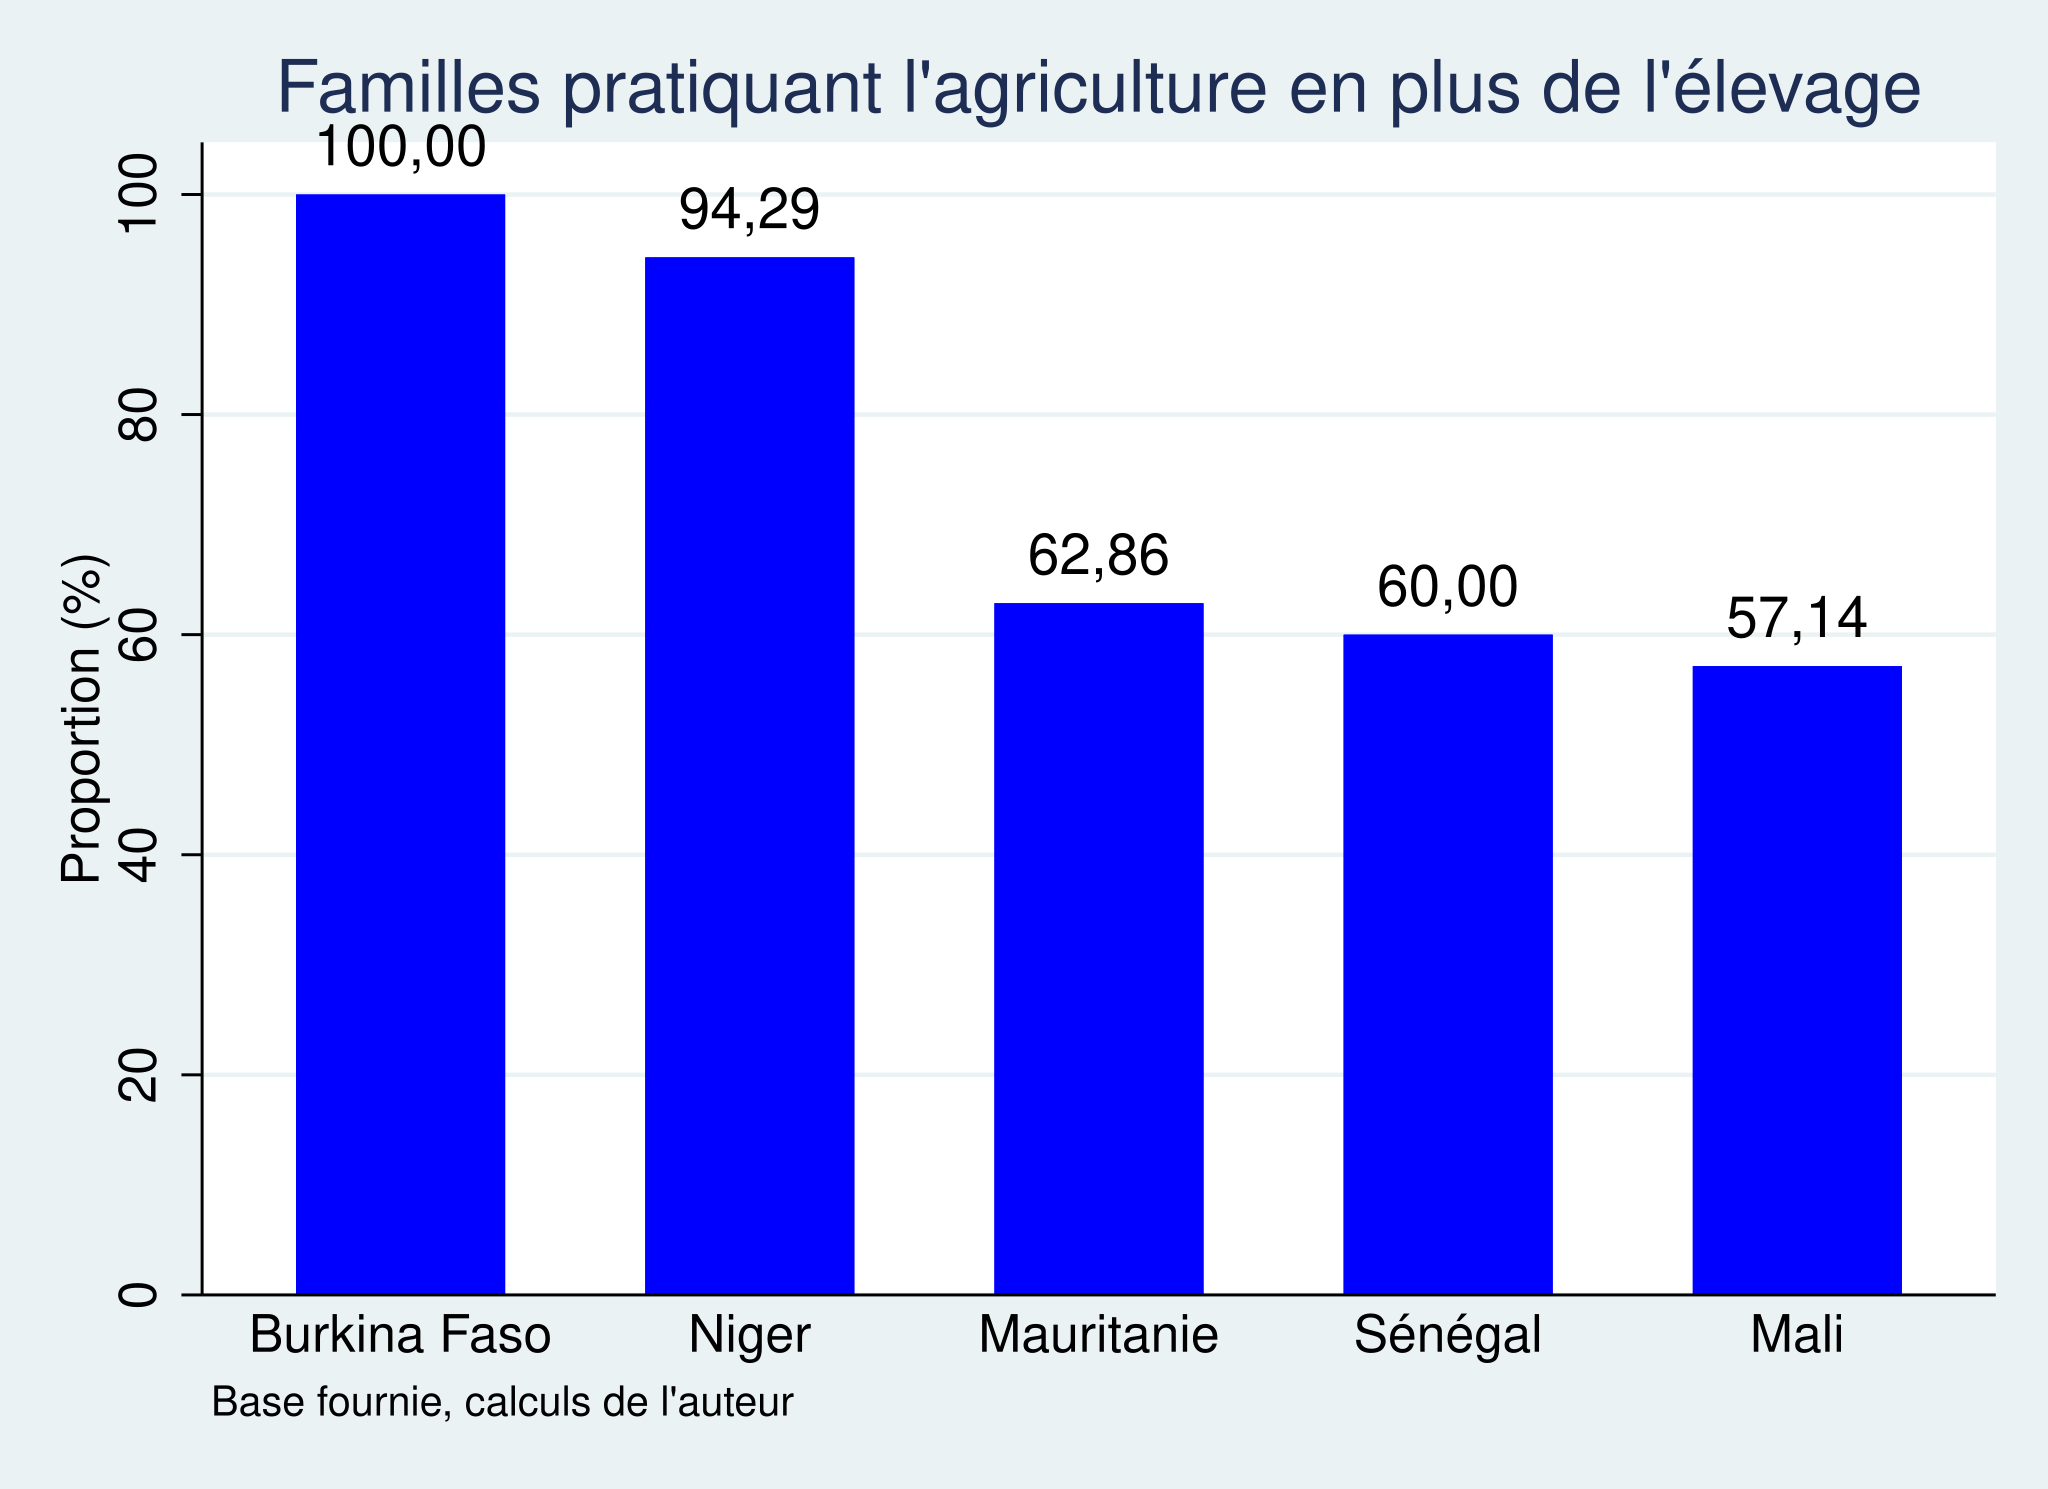

In [117]:
%%stata
gen agri_et_elevage = 0
replace agri_et_elevage = 100 if AGRICULTURE=="Oui"

tab agri_et_elevage country, col
graph bar (mean) agri_et_elevage, over(country, sort(1) descending) ytitle("Proportion (%)") bar(1,color(blue)) blabel(bar, format(%9,2f) size(medium)) title("Familles pratiquant l'agriculture en plus de l'élevage") note("Base fournie, calculs de l'auteur ")
graph export "${outputs}/agri_elevage.png", replace

drop agri_et_elevage

### **2. La proportion pour les différentes cultures**
--------------------------------------------------------------------------------------------------------------------------------------------------------

Les résultats montrent que les **éleveurs** de la région pratiquent principalement des **cultures de subsistance** adaptées aux conditions climatiques locales, tout en intégrant des cultures commerciales pour compléter leurs revenus. Ainsi, 
le **Maïs** est la culture dominante, particulièrement au **Mali** (70,15 %) et au **Burkina Faso** (70 %), servant à la fois pour la consommation et comme culture de rente.
Le **Mil** et le **Niébé** sont des cultures clés, particulièrement au **Niger** (68,57 % et 95,71 % respectivement), adaptées aux conditions arides et jouant un rôle crucial dans la sécurité alimentaire des éleveurs.
L'**Arachide** et le **Coton**, deux cultures importantes au **Sénégal** (Arachide 31,43 %) et au **Mali** (Coton 26,87 %), avec le coton étant une culture commerciale majeure dans les pays producteurs.
**Diversification** : Certains éleveurs pratiquent des **cultures maraîchères** (17,14 % à 31,43 %) pour compléter leur alimentation ou générer des revenus supplémentaires.

En résumé, l'agriculture des éleveurs repose sur un équilibre entre cultures vivrières (Mil, Niébé) et commerciales (Coton, Arachide), en fonction des besoins alimentaires et des opportunités économiques, privilégient des cultures résistantes telles que le **mil** et le **niébé**.

In [118]:
%%stata
// Uniformisation des réponses au niveau des cultures	
quietly foreach var in Mil Sorgho  Maïs Niébé Manioc Arachide{
    display "Traitement sur la culture `var'"
    tab `var',mis
    replace `var' = "Oui" if `var'== "`var'"
    tab `var', mis
}

* Traiter la variable Culturesmaraîchères
quietly tab Culturesmaraîchères, mis
quietly replace Culturesmaraîchères="Oui" if Culturesmaraîchères=="Maraîch."
quietly tab Culturesmaraîchères, mis

quietly foreach var in Mil Sorgho  Maïs Niébé Manioc Arachide Coton Culturesmaraîchères{
    gen part_`var' = 0
    replace part_`var' = 100 if `var'=="Oui"
    display "Proportion de `var' par pays"
    tab part_`var' country, col
}

// Créer un dataframe avec les cultures

quietly ds part_*  // Lister toutes les variables commençant par "part_"
local vars country `r(varlist)' // Stocker "country" + toutes les "part_*"

frame put `vars', into(dataCultures) // Copier ces variables dans le frame "dataCultures"

frame change dataCultures
	
//Résumer les proportions par pays
collapse (mean) part_*, by(country)

//Transformer en tableau unique avec `reshape`
quietly reshape long part_, i(country) j(culture) string
rename part_ proportion

//Afficher le tableau final
list country culture proportion, sepby(country) noobs // sepby regroupe par pays et noobs supprime les numeros d'observation


. // Uniformisation des réponses au niveau des cultures  
. quietly foreach var in Mil Sorgho  Maïs Niébé Manioc Arachide{

. 
. * Traiter la variable Culturesmaraîchères
. quietly tab Culturesmaraîchères, mis

. quietly replace Culturesmaraîchères="Oui" if Culturesmaraîchères=="Maraîch."

. quietly tab Culturesmaraîchères, mis

. 
. quietly foreach var in Mil Sorgho  Maïs Niébé Manioc Arachide Coton Culturesm
> araîchères{

. 
. // Créer un dataframe avec les cultures
. 
. quietly ds part_*  // Lister toutes les variables commençant par "part_"

. local vars country `r(varlist)' // Stocker "country" + toutes les "part_*"

. 
. frame put `vars', into(dataCultures) // Copier ces variables dans le frame "d
> ataCultures"

. 
. frame change dataCultures

.         
. //Résumer les proportions par pays
. collapse (mean) part_*, by(country)

. 
. //Transformer en tableau unique avec `reshape`
. quietly reshape long part_, i(country) j(culture) string

. rename part_ proportion

. 
. //Affi

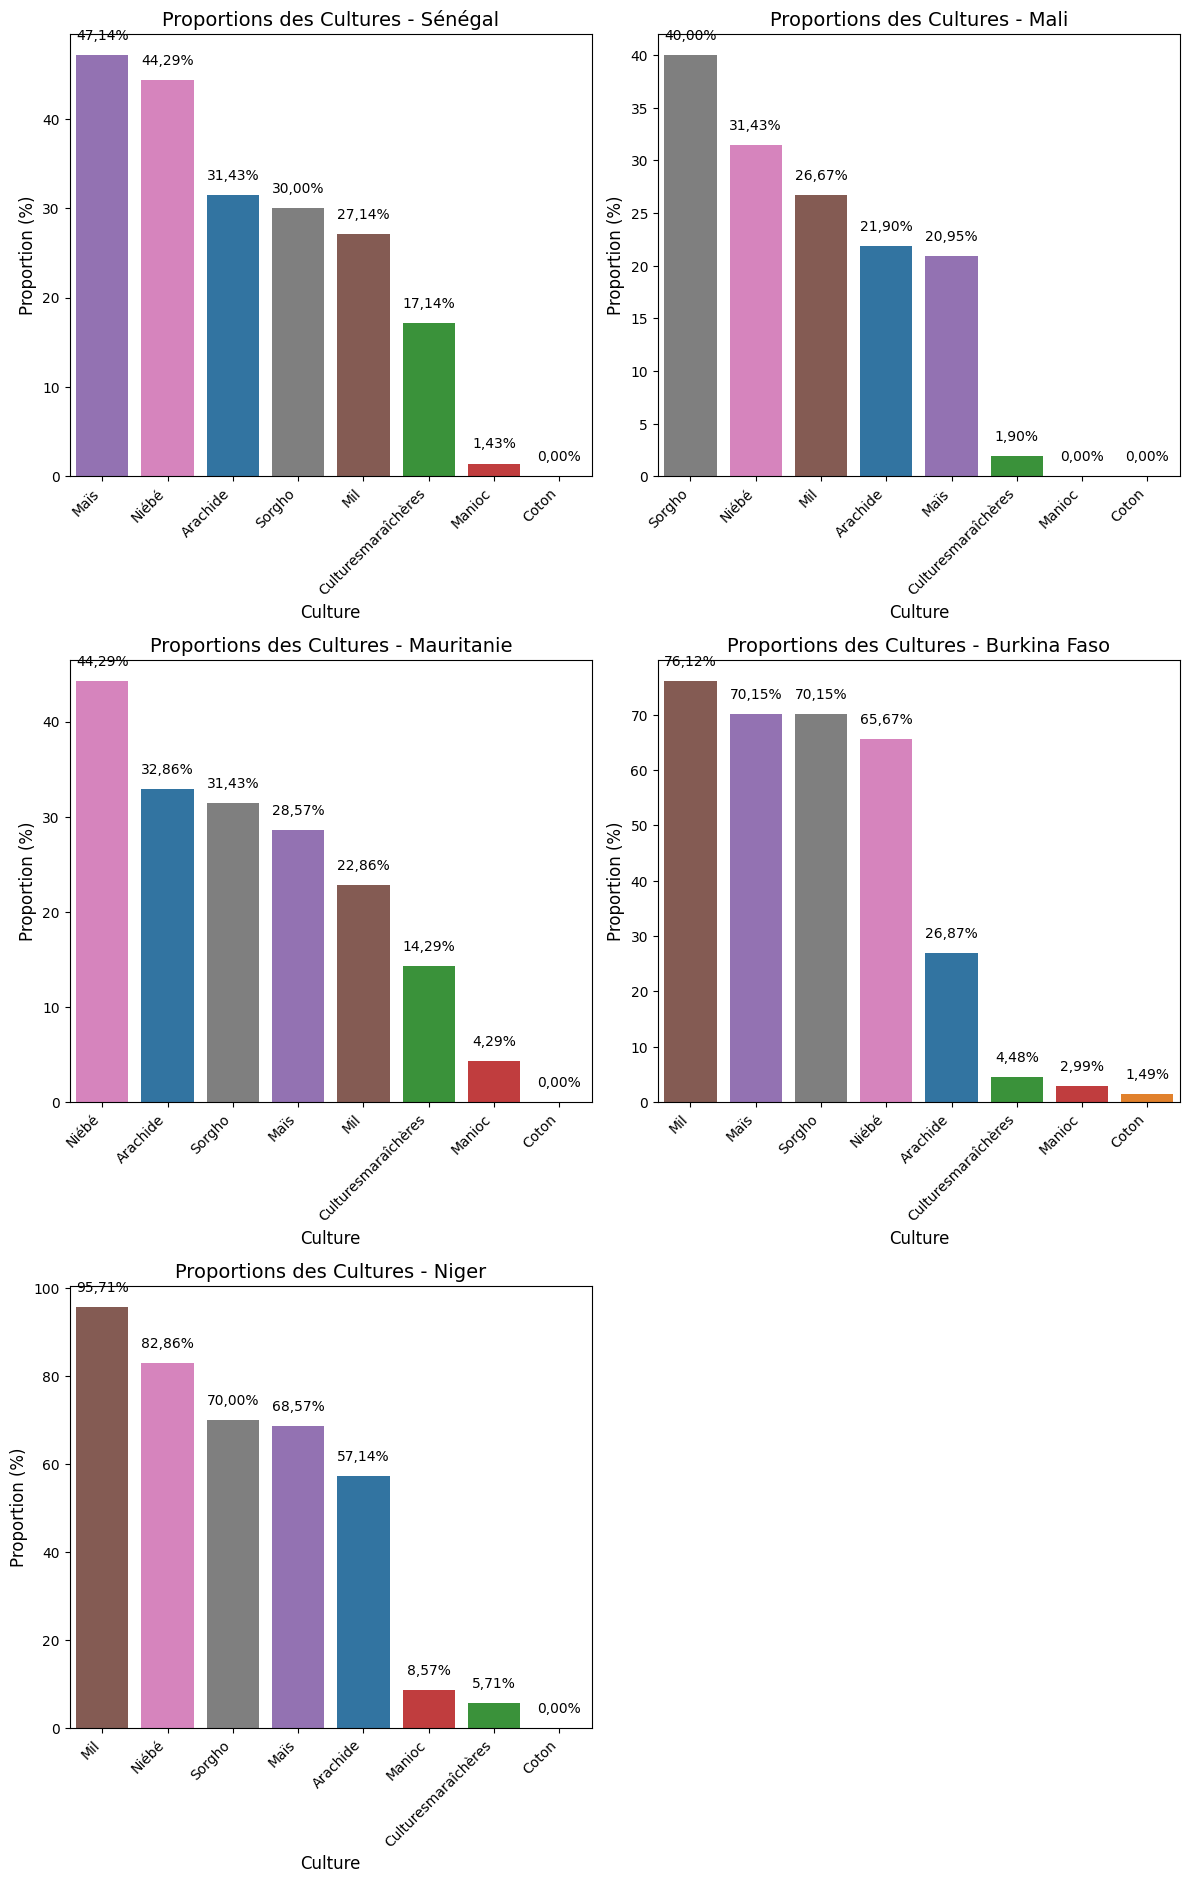

In [119]:
# Réalisation du graphique sous python

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Création du DataFrame à partir des données
data = {
    'country': ['Sénégal', 'Sénégal', 'Sénégal', 'Sénégal', 'Sénégal', 'Sénégal', 'Sénégal', 'Sénégal',
                'Mali', 'Mali', 'Mali', 'Mali', 'Mali', 'Mali', 'Mali', 'Mali',
                'Mauritanie', 'Mauritanie', 'Mauritanie', 'Mauritanie', 'Mauritanie', 'Mauritanie', 'Mauritanie', 'Mauritanie',
                'Burkina Faso', 'Burkina Faso', 'Burkina Faso', 'Burkina Faso', 'Burkina Faso', 'Burkina Faso', 'Burkina Faso', 'Burkina Faso',
                'Niger', 'Niger', 'Niger', 'Niger', 'Niger', 'Niger', 'Niger', 'Niger'],
    'culture': ['Arachide', 'Coton', 'Culturesmaraîchères', 'Manioc', 'Maïs', 'Mil', 'Niébé', 'Sorgho',
                'Arachide', 'Coton', 'Culturesmaraîchères', 'Manioc', 'Maïs', 'Mil', 'Niébé', 'Sorgho',
                'Arachide', 'Coton', 'Culturesmaraîchères', 'Manioc', 'Maïs', 'Mil', 'Niébé', 'Sorgho',
                'Arachide', 'Coton', 'Culturesmaraîchères', 'Manioc', 'Maïs', 'Mil', 'Niébé', 'Sorgho',
                'Arachide', 'Coton', 'Culturesmaraîchères', 'Manioc', 'Maïs', 'Mil', 'Niébé', 'Sorgho'],
    'proportion': [31.42857, 0, 17.14286, 1.428571, 47.14286, 27.14286, 44.28571, 30,
                   21.90476, 0, 1.904762, 0, 20.95238, 26.66667, 31.42857, 40,
                   32.85714, 0, 14.28571, 4.285714, 28.57143, 22.85714, 44.28571, 31.42857,
                   26.86567, 1.492537, 4.477612, 2.985075, 70.14925, 76.1194, 65.67164, 70.14925,
                   57.14286, 0, 5.714286, 8.571428, 68.57143, 95.71429, 82.85714, 70]
}

# Convertir les données en DataFrame
df = pd.DataFrame(data)

# Liste des pays pour lesquels nous allons créer un graphique
countries = ['Sénégal', 'Mali', 'Mauritanie', 'Burkina Faso', 'Niger']

# Dictionnaire des couleurs pour chaque culture
culture_colors = {
    'Arachide': '#1f77b4',
    'Coton': '#ff7f0e',
    'Culturesmaraîchères': '#2ca02c',
    'Manioc': '#d62728',
    'Maïs': '#9467bd',
    'Mil': '#8c564b',
    'Niébé': '#e377c2',
    'Sorgho': '#7f7f7f'
}

# Créer un graphique pour chaque pays
plt.figure(figsize=(12, 30))  # Taille globale de la figure

# Parcourir chaque pays pour créer un graphique spécifique
for i, country in enumerate(countries, 1):
    plt.subplot(5, 2, i)  # Crée un sous-graphe dans une disposition 5x1
    
    # Filtrer les données pour le pays actuel
    country_data = df[df['country'] == country]
    
    # Trier les données par proportion de manière descendante
    country_data = country_data.sort_values(by='proportion', ascending=False)
    
    # Tracer un graphique à barres pour ce pays avec des couleurs fixes
    sns.barplot(data=country_data, x="culture", y="proportion", hue="culture", palette=culture_colors, ci=None)
    
    # Ajouter des étiquettes et un titre
    plt.title(f'Proportions des Cultures - {country}', fontsize=14)
    plt.xlabel('Culture', fontsize=12)
    plt.ylabel('Proportion (%)', fontsize=12)
    
    # Ajouter des étiquettes sur les barres avec deux décimales, et remplacer le point par la virgule
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}%'.replace('.', ','),  # Remplacer le point par la virgule
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    xytext=(0, 9), 
                    textcoords='offset points', 
                    ha='center', va='bottom', fontsize=10)
    
    # Ajuster l'affichage des labels des cultures
    plt.xticks(rotation=45, ha='right')

# Ajuster l'affichage de la figure
plt.tight_layout()
plt.show()

In [120]:
df.head(10)

,country,culture,proportion
0,Sénégal,Arachide,31.428570
1,Sénégal,Coton,0.000000
2,Sénégal,Culturesmaraîchères,17.142860
3,Sénégal,Manioc,1.428571
4,Sénégal,Maïs,47.142860
5,Sénégal,Mil,27.142860
6,Sénégal,Niébé,44.285710
7,Sénégal,Sorgho,30.000000
8,Mali,Arachide,21.904760
9,Mali,Coton,0.000000


In [121]:
%%stata
frame change default  // Revenir au data frame principal
	
// supprimer les variables  temporaires
drop part_*


. frame change default  // Revenir au data frame principal

.         
. // supprimer les variables  temporaires
. drop part_*

. 


### **3. la taille du ménage en Equivalents adultes (EA)**
--------------------------------------------------------------------------------------------------------------------------------------------------------

La taille moyenne des ménages en Équivalent Adulte **(EA)** dans notre base de données est de **19,99 EA**. Le **Sénégal** et le **Burkina Faso** présentent les valeurs les plus élevées, avec respectivement **25,26 EA** et **23,34 EA**, tandis que les tailles les plus faibles sont observées en **Mauritanie (15,15 EA)** et au **Niger (16,96 EA)**.



. // 3. Taille du ménage en Equivalent Adulte (EA)
. tabstat HHsizeEA, by(country) s(mean)

Summary for variables: HHsizeEA
Group variable: country 

     country |      Mean
-------------+----------
     Sénégal |  25.25714
        Mali |  19.57857
  Mauritanie |  15.14643
Burkina Faso |  23.33955
       Niger |  16.95714
-------------+----------
       Total |  19.98626
------------------------

. graph bar (mean) HHsizeEA, over(country, sort(1) descending) ytitle("Taille")
>  title("Taille moyenne en EA") bargap(10) bar(1,color(blue)) blabel(bar, form
> at(%9,2f)) note("Base dournie, calculs de l'auteur")

. graph export "${outputs}/hhsizeEA.png", replace 
file E:/Ecole/AS2/Semestre1/Stat_agricole/TP3_elevage_pastoral/TP_elevage/Outpu
> ts/hhsizeEA.png written in PNG format

. 


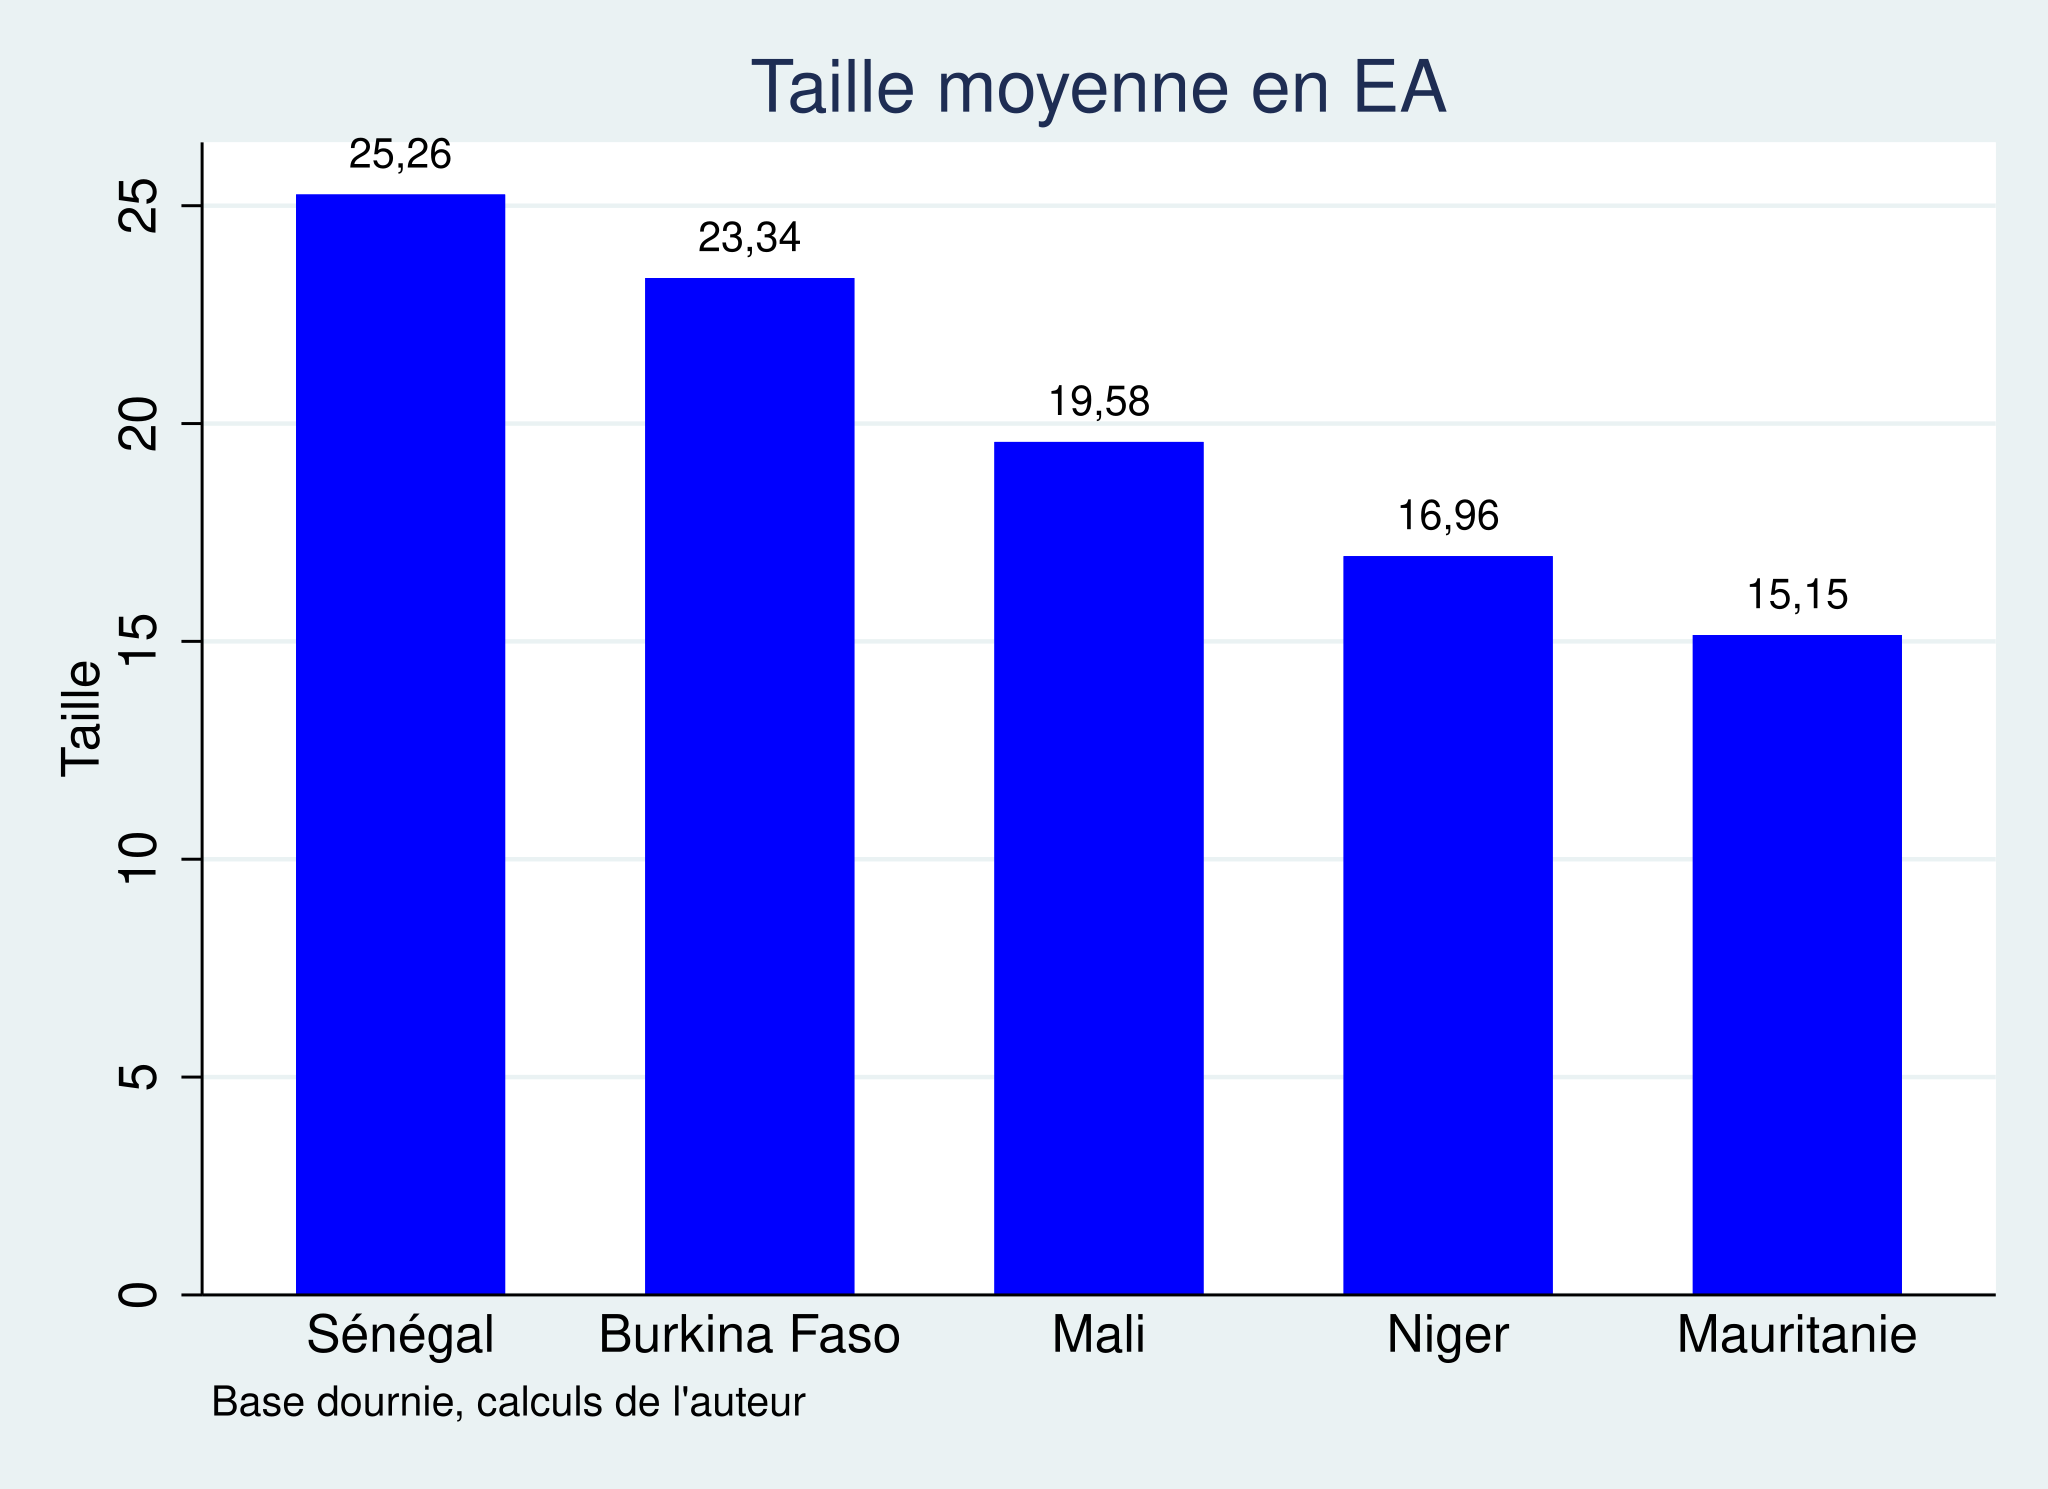

In [122]:

%%stata
// 3. Taille du ménage en Equivalent Adulte (EA)
tabstat HHsizeEA, by(country) s(mean)
graph bar (mean) HHsizeEA, over(country, sort(1) descending) ytitle("Taille") title("Taille moyenne en EA") bargap(10) bar(1,color(blue)) blabel(bar, format(%9,2f)) note("Base dournie, calculs de l'auteur")
graph export "${outputs}/hhsizeEA.png", replace	

### **4. le nombre de mois d’autosuffisance de la production agricole**
--------------------------------------------------------------------------------------------------------------------------------------------------------

Dans les pays étudiés, la couverture moyenne des produits agricoles en termes d'autosuffisance est de **4 mois**. Toutefois, une forte disparité est observée entre le **Niger**, où l'autosuffisance atteint en moyenne **6 mois**, et le **Mali**, où elle se limite à **3 mois**.


. tab Nbremoisautosuffis, mis // On se rend compte qu'il y a des valeurs de 99,
>  ce qui n'est pas normal

  Nbre mois |
auto-suffis |
          . |      Freq.     Percent        Cum.
------------+-----------------------------------
          0 |         10        2.62        2.62
          1 |         17        4.45        7.07
          2 |         30        7.85       14.92
          3 |         48       12.57       27.49
          4 |         38        9.95       37.43
          5 |         25        6.54       43.98
          6 |         37        9.69       53.66
          7 |         34        8.90       62.57
          8 |         14        3.66       66.23
          9 |         11        2.88       69.11
         10 |          6        1.57       70.68
         11 |          1        0.26       70.94
         12 |          4        1.05       71.99
         99 |          3        0.79       72.77
          . |        104       27.23      100.00
------------+-----------------

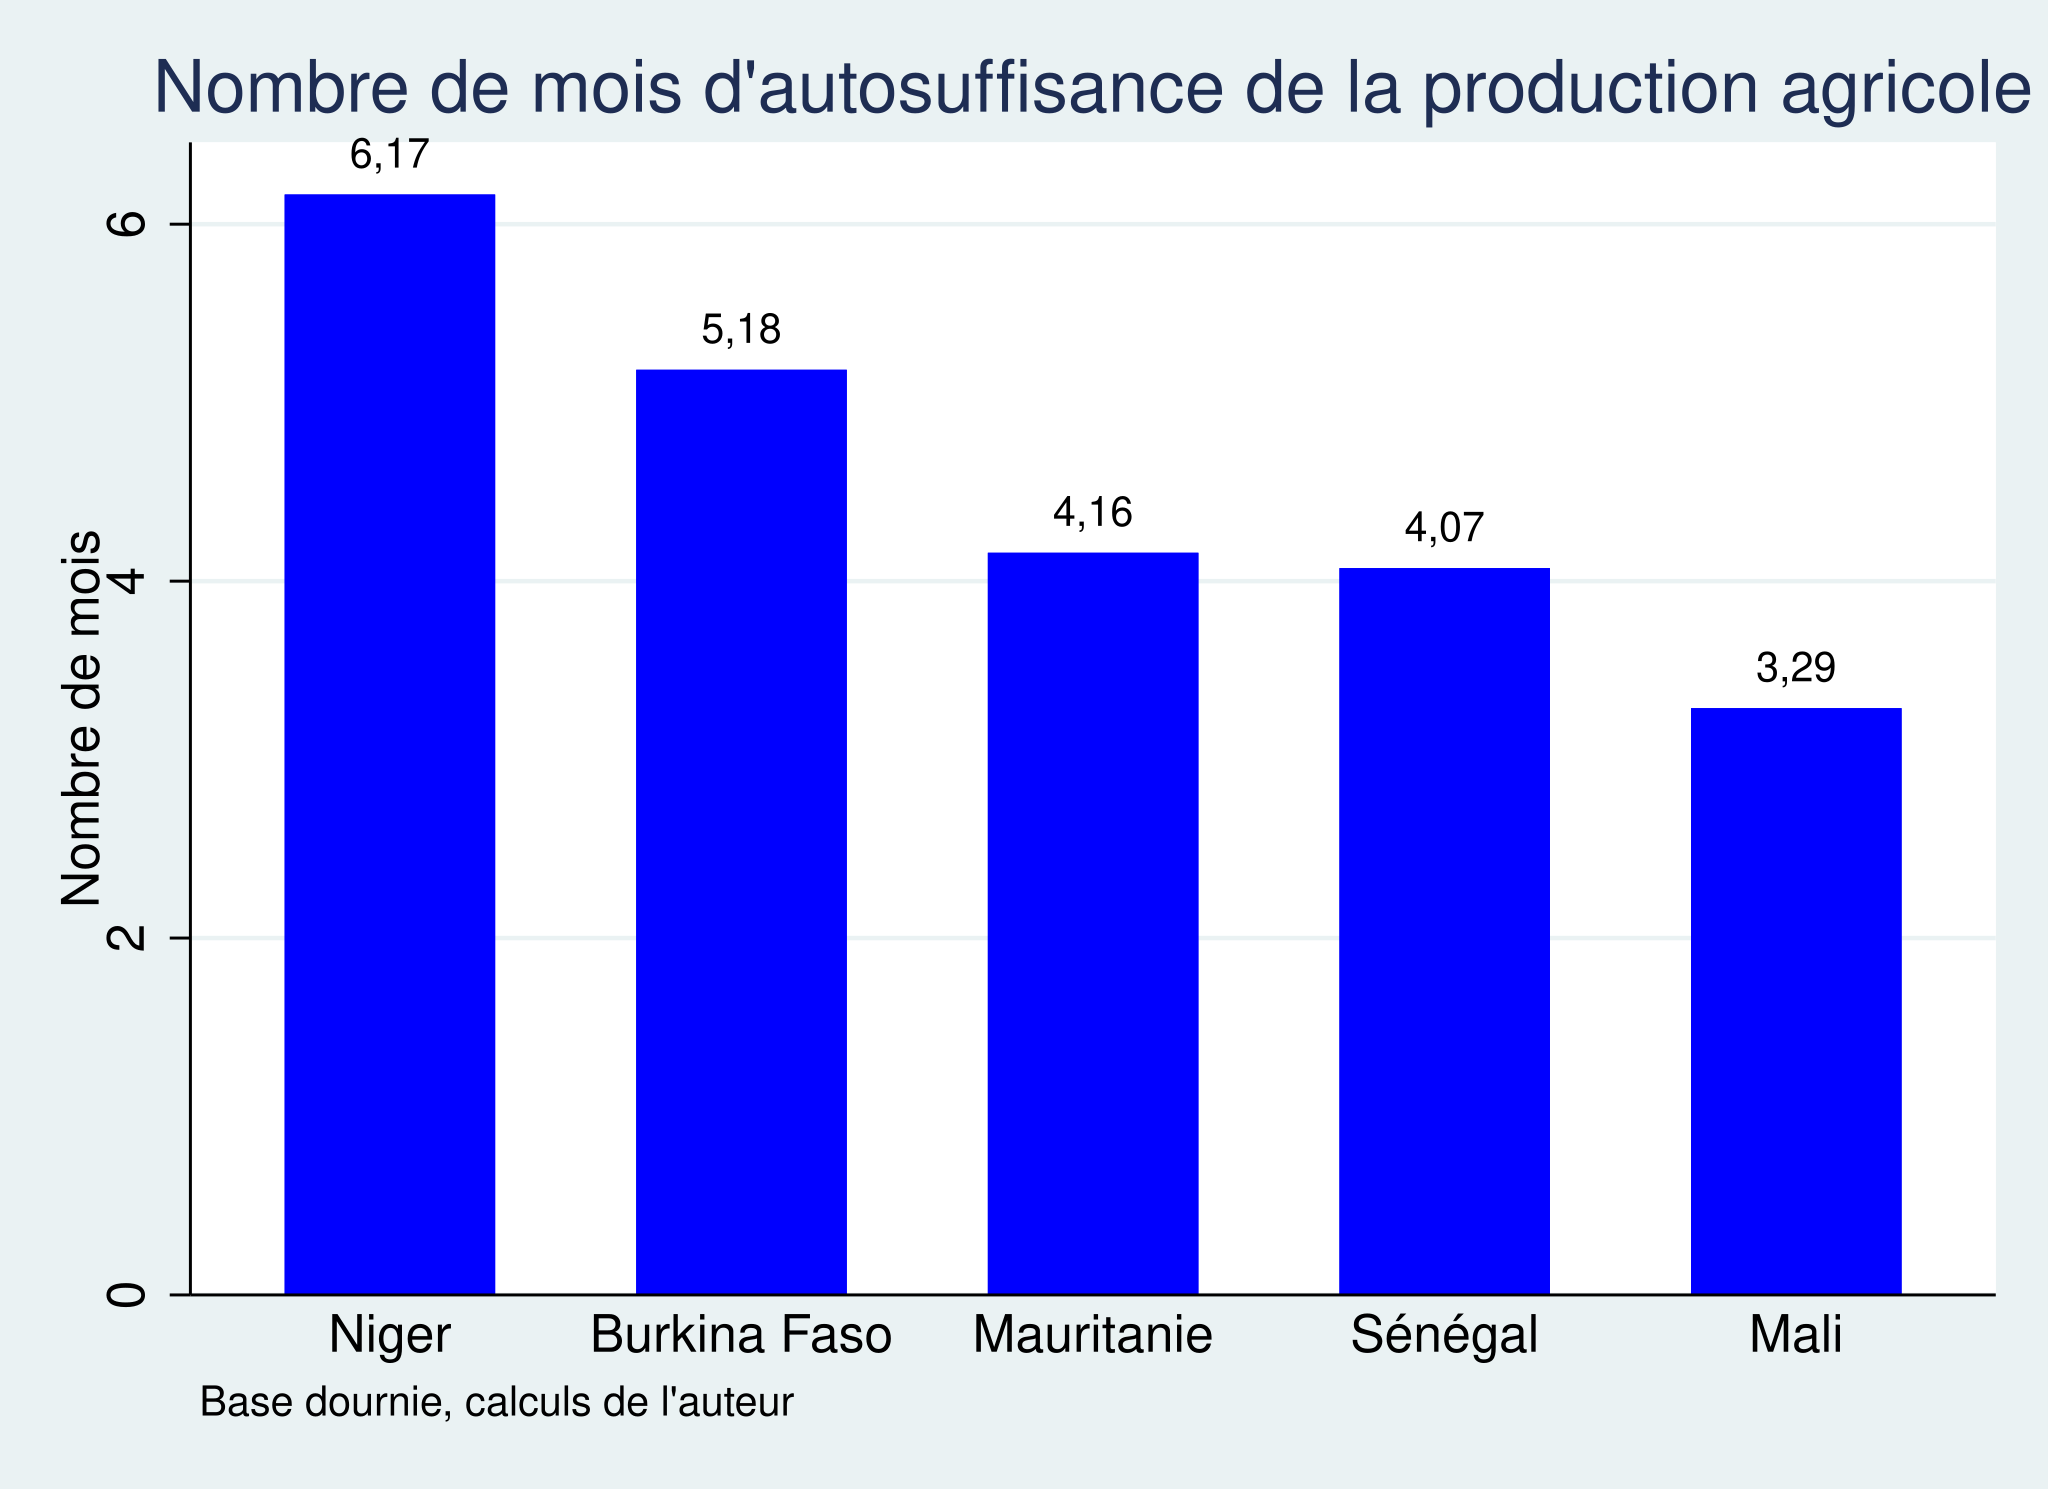

In [123]:
%%stata
tab Nbremoisautosuffis, mis // On se rend compte qu'il y a des valeurs de 99, ce qui n'est pas normal
// Remplacer les nombres de mois valant 99 par missing	
mvdecode Nbremoisautosuffis, mv(99) 

tabstat Nbremoisautosuffis, by(country) s(mean)	
graph bar (mean) Nbremoisautosuffis, over(country, sort(1) descending) ytitle("Nombre de mois") title("Nombre de mois d'autosuffisance de la production agricole") bargap(10) bar(1,color(blue)) blabel(bar, format(%9,2f)) note("Base dournie, calculs de l'auteur")
graph export "${outputs}/mois_autosuffisance.png", replace

### **5. la taille du cheptel en Unités de bétail tropical (UBT)**
--------------------------------------------------------------------------------------------------------------------------------------------------------

La taille moyenne du cheptel en **UBT** varie entre les pays. La Mauritanie affiche quant à elle, la valeur la plus élevée **(88,01 UBT)**, suivie du Mali **(76,47 UBT)** et du Sénégal **(71,89 UBT)**. À l’inverse, le Burkina Faso **(49,92 UBT)** et surtout le Niger **(36,73 UBT)** enregistrent les tailles moyennes les plus faibles. La moyenne globale sur l’ensemble des pays est de **65,61 UBT**, indiquant une disparité notable entre les pays en matière de cheptel.



. quietly ds transh_*

. quietly display "`r(varlist)'"

. 
. // Remplacer les tailles valant 999 par missing
. foreach var in transh_Bovins transh_Ovins transh_Caprins transh_Camelins{
  2.     mvdecode `var', mv(999)
  3. }
transh_Ovins: 6 missing values generated
transh_Cam~s: 1 missing value generated

. 
. // Calcul de la taille UBT
. quietly gen taille_UBT = 0.5*transh_Bovins + 0.1*transh_Ovins + 0.1*transh_Ca
> prins + 0.7*transh_Camelins 

. 
. // Calcul de la taille du cheptel en UBT par pays
. tabstat taille_UBT, by(country) s(mean) 

Summary for variables: taille_UBT
Group variable: country 

     country |      Mean
-------------+----------
     Sénégal |  71.88955
        Mali |  76.46634
  Mauritanie |  88.00588
Burkina Faso |  49.91846
       Niger |  36.72714
-------------+----------
       Total |  65.60566
------------------------

. graph bar (mean) taille_UBT, over(country, sort(1) descending) ytitle("Taille
>  UBT") title("Taille du cheptel en UBT") bargap(10) bar

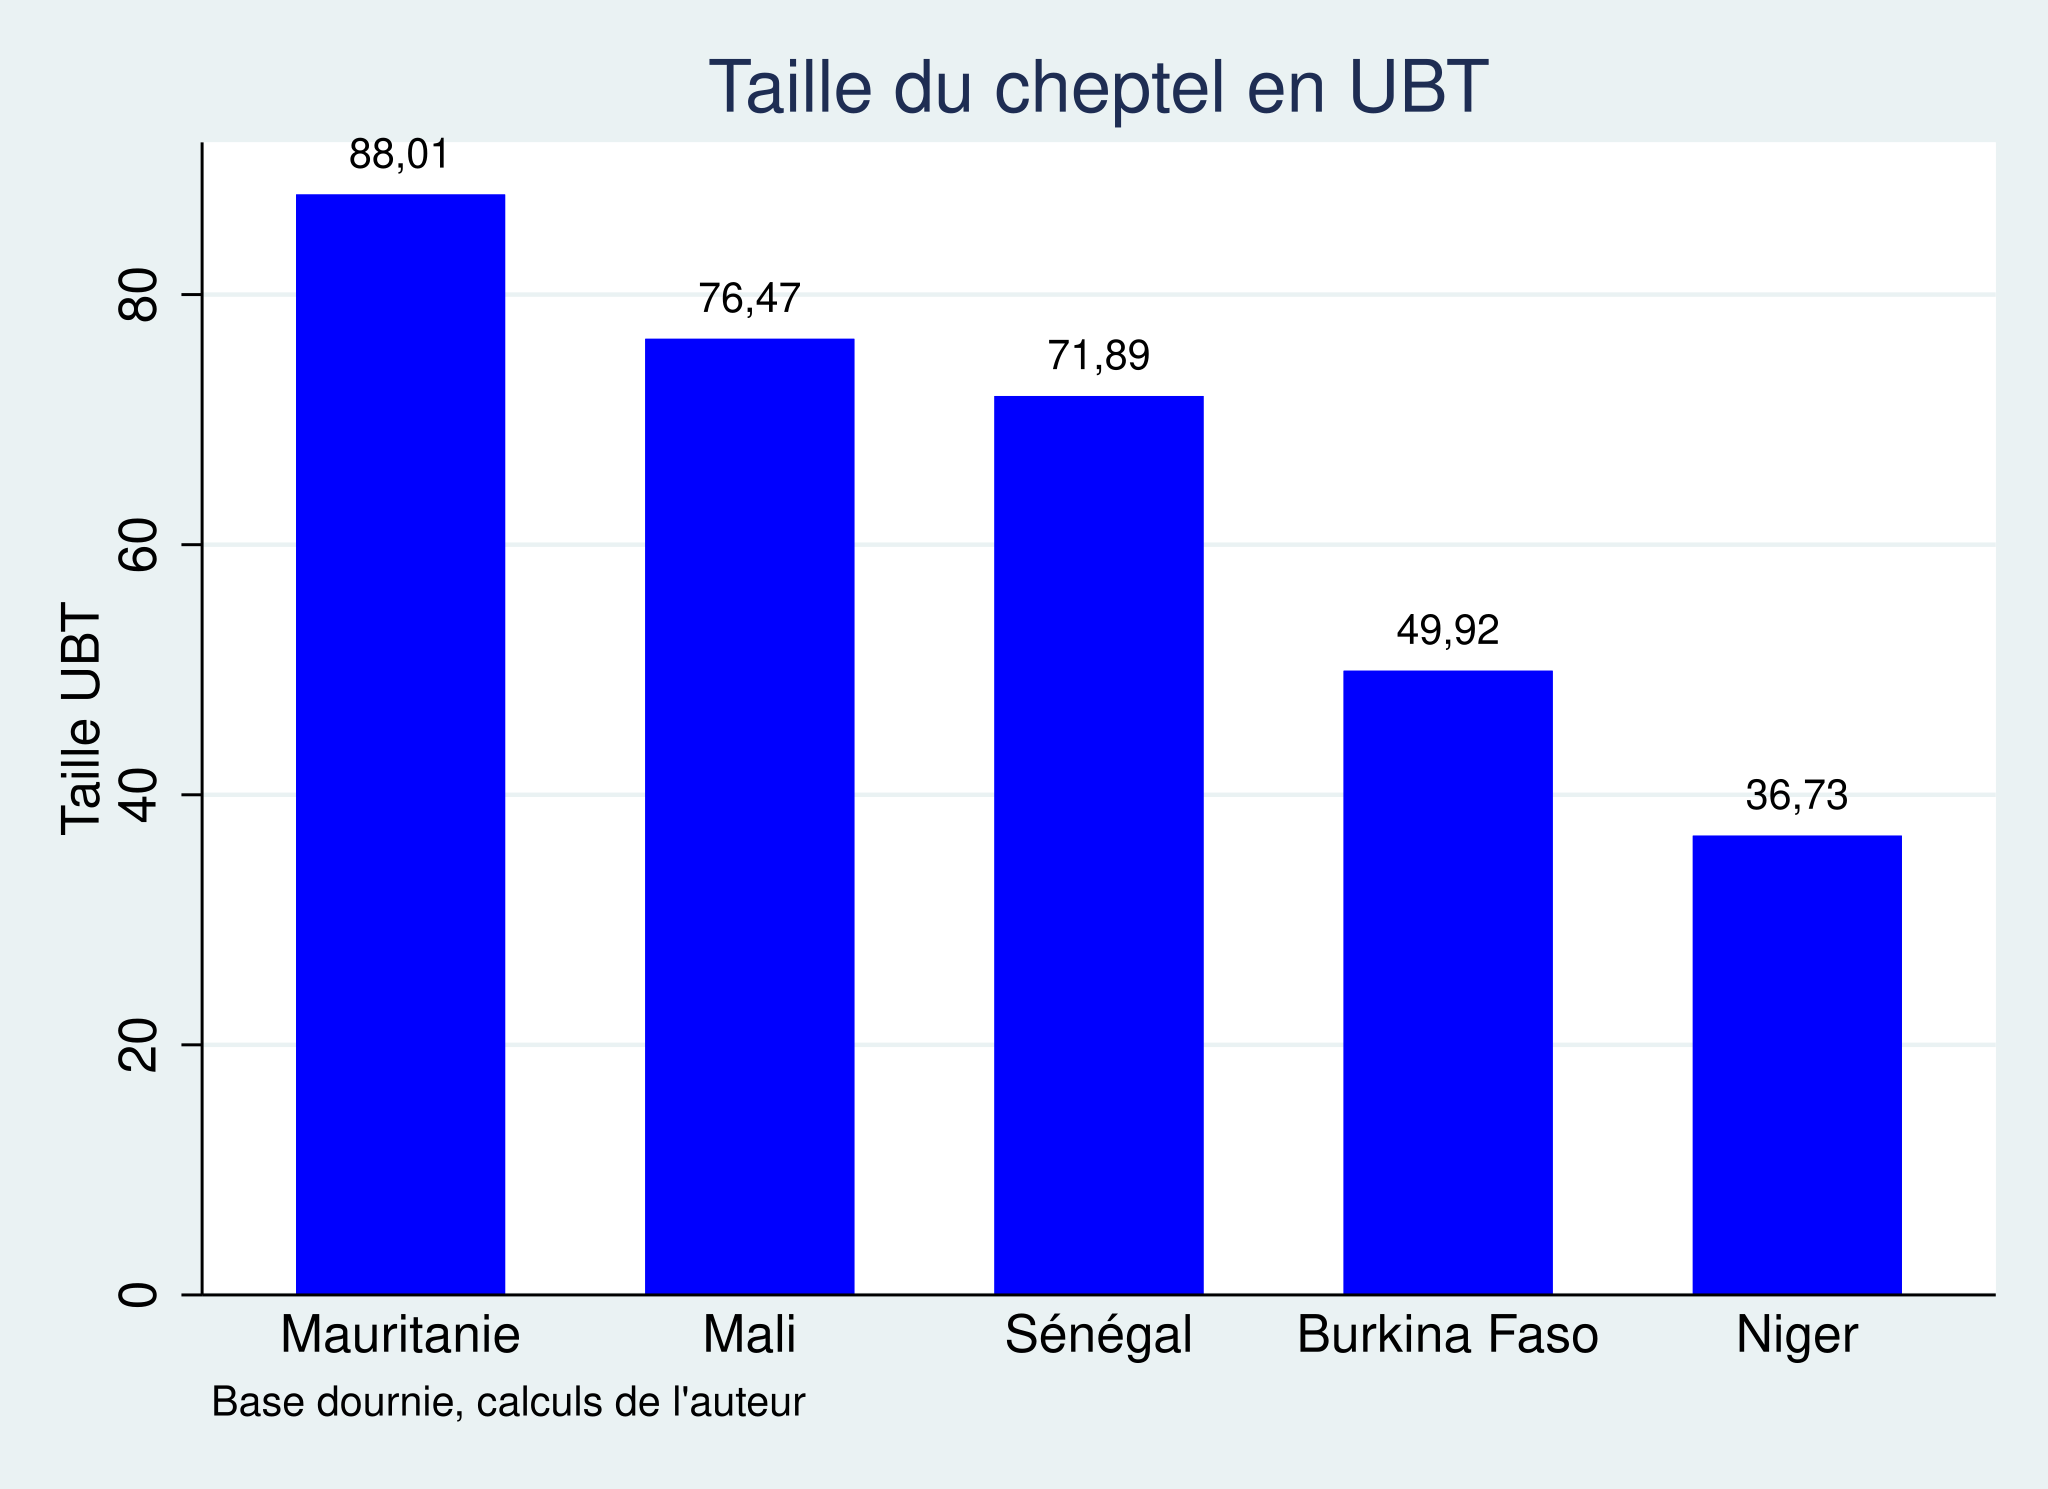

In [124]:
%%stata
quietly ds transh_*
quietly display "`r(varlist)'"

// Remplacer les tailles valant 999 par missing
foreach var in transh_Bovins transh_Ovins transh_Caprins transh_Camelins{
    mvdecode `var', mv(999)
}

// Calcul de la taille UBT
quietly gen taille_UBT = 0.5*transh_Bovins + 0.1*transh_Ovins + 0.1*transh_Caprins + 0.7*transh_Camelins 

// Calcul de la taille du cheptel en UBT par pays
tabstat taille_UBT, by(country) s(mean)	
graph bar (mean) taille_UBT, over(country, sort(1) descending) ytitle("Taille UBT") title("Taille du cheptel en UBT") bargap(10) bar(1,color(blue)) blabel(bar, format(%9,2f)) note("Base dournie, calculs de l'auteur")
graph export "${outputs}/taille_ubt.png", replace

### **6. l’indicateur de viabilité de l’élevage (UBT/EA)**
--------------------------------------------------------------------------------------------------------------------------------------------------------

L'indicateur de viabilité de l'élevage, ou le rapport **UBT/EA**, reflète la capacité qu'à un ménage de subvenir à ses besoins grâce à son cheptel. Il mesure en outre, la dépendance des ménages à l'élevage pour leur subsistance. Ainsi, l'analyse de notre base montre que la valeur moyenne de ce ratio est de **4,42 UBT/EA** avec des disparités suivant les pays. La **Mauritanie** affiche un ratio élevé de **9,02 UBT/EA**, indiquant une forte dépendance à l'élevage, tandis que le **Burkina Faso** a le plus faible ratio à **2,42 UBT/EA**, suggérant une moindre viabilité pastorale. Le **Mali** et le **Sénégal** se situent autour de la moyenne avec respectivement **4,07** et **3,45**.


. gen UBT_par_EA = taille_UBT/HHsizeEA
(11 missing values generated)

.         
. tabstat UBT_par_EA, by(country) s(mean) 

Summary for variables: UBT_par_EA
Group variable: country 

     country |      Mean
-------------+----------
     Sénégal |  3.448387
        Mali |  4.072174
  Mauritanie |  9.022202
Burkina Faso |  2.415941
       Niger |  3.239966
-------------+----------
       Total |  4.419609
------------------------

. graph bar (mean) UBT_par_EA, over(country, sort(1) descending) ytitle("Valeur
> ") title("Indicateur de viabilité de l'élevage (taille_UBT/EA)") bargap(10) b
> ar(1,color(blue)) blabel(bar, format(%9,2f)) note("Base fournie, calculs de l
> 'auteur")

. graph export "${outputs}/indicateur_viabilite.png", replace
file E:/Ecole/AS2/Semestre1/Stat_agricole/TP3_elevage_pastoral/TP_elevage/Outpu
> ts/indicateur_viabilite.png written in PNG format

. 


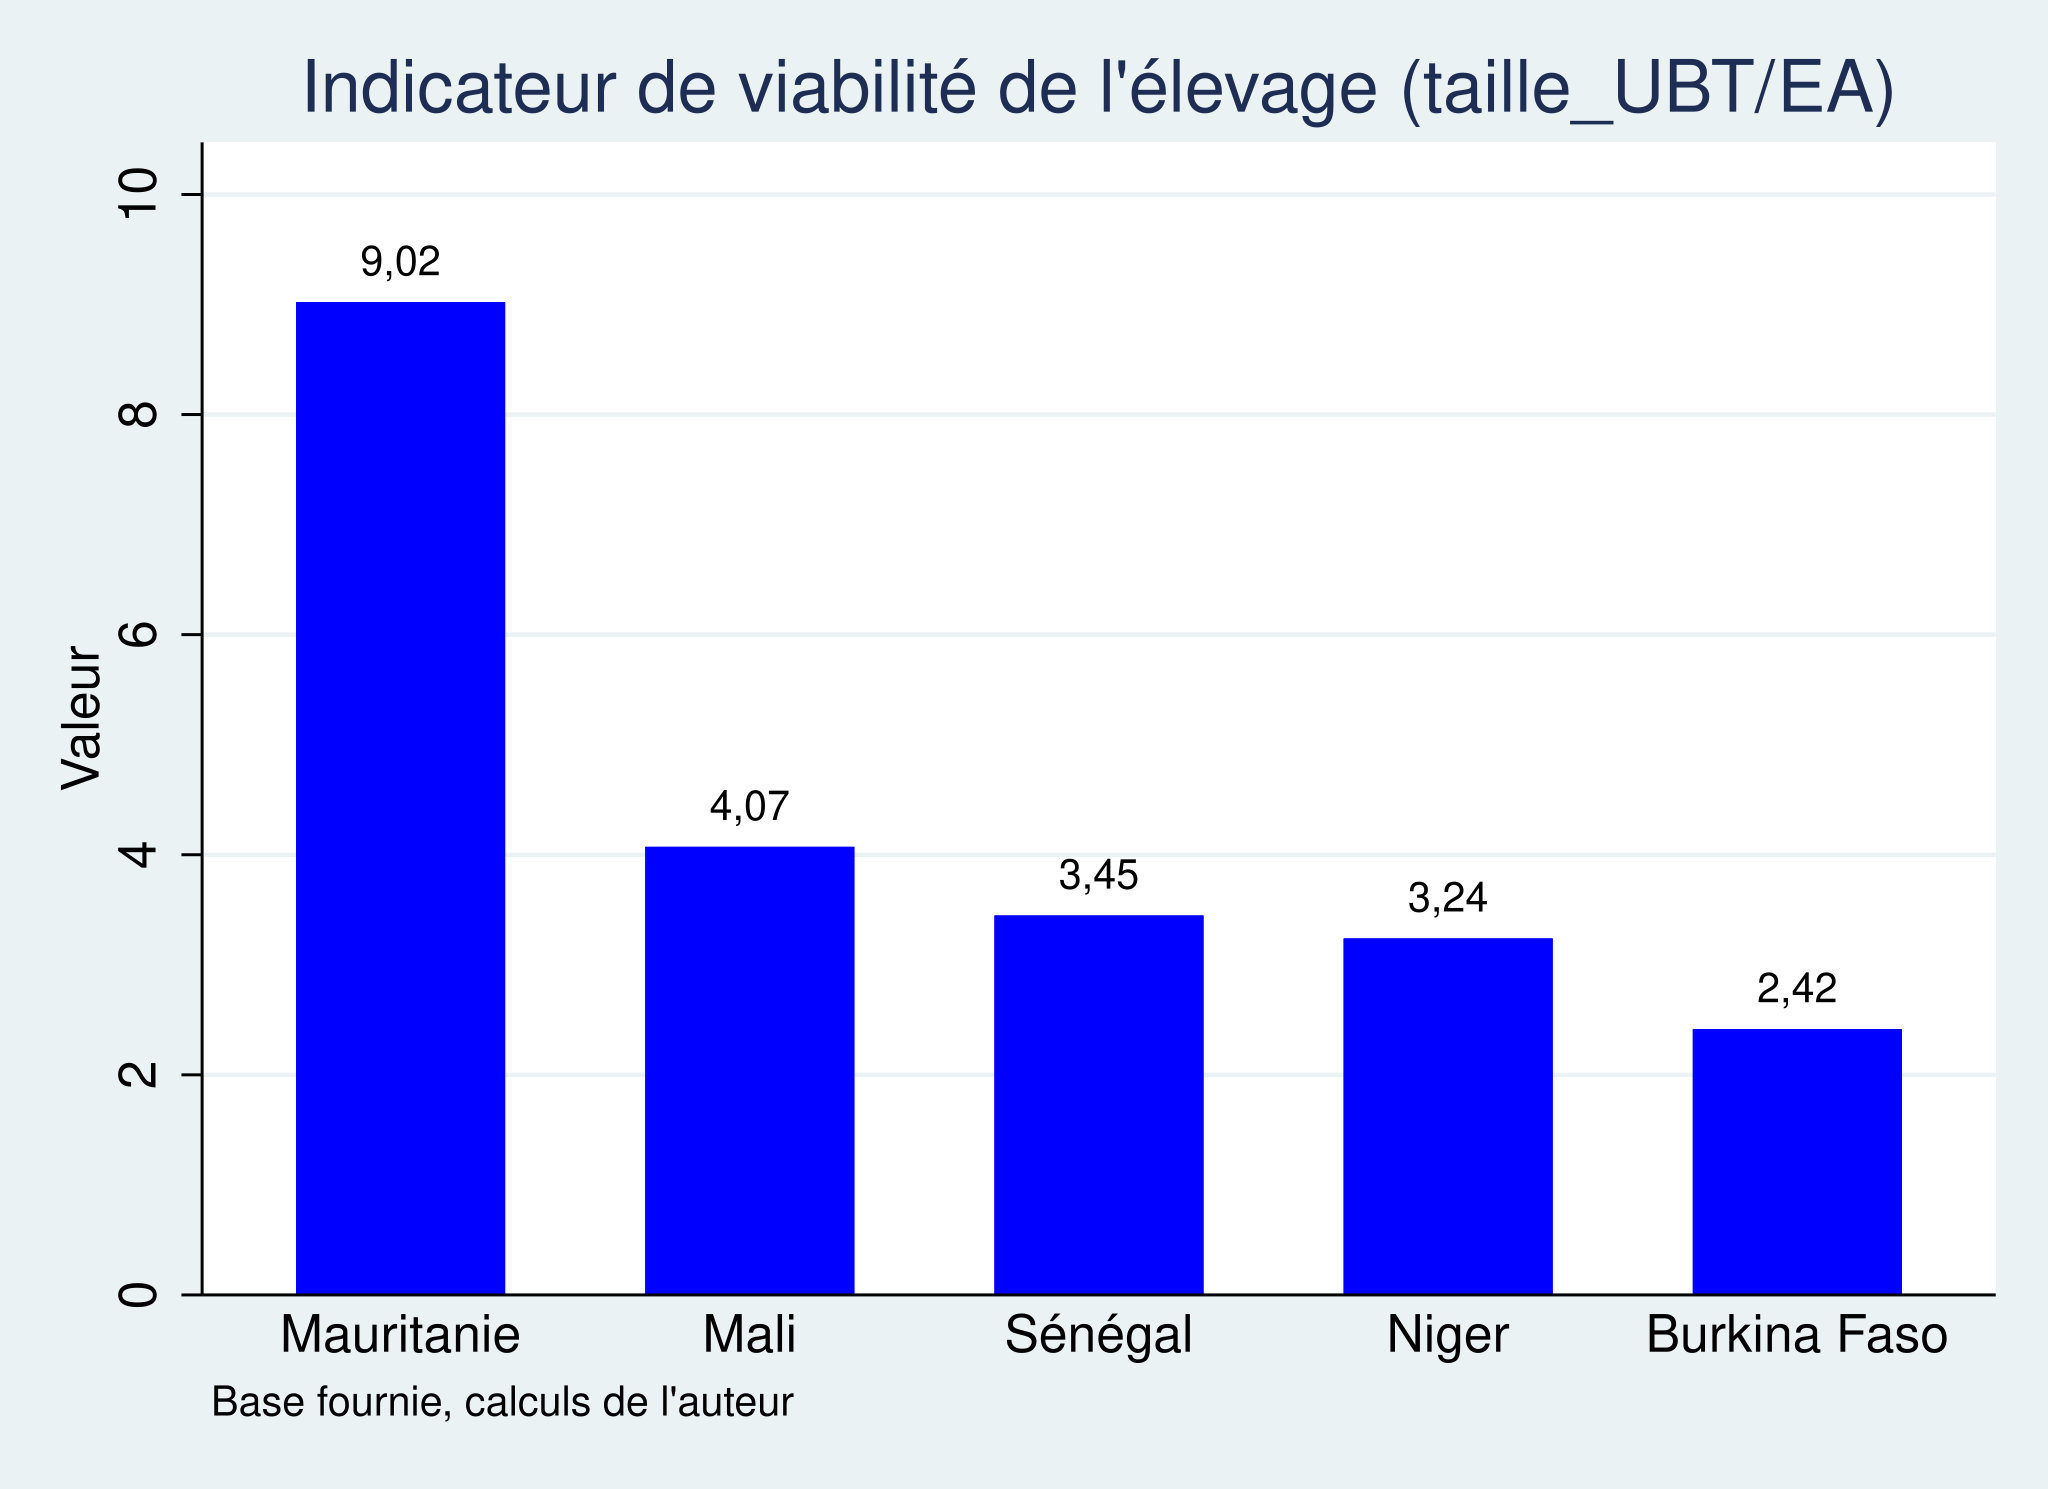

In [125]:
%%stata
gen UBT_par_EA = taille_UBT/HHsizeEA
	
tabstat UBT_par_EA, by(country) s(mean)	
graph bar (mean) UBT_par_EA, over(country, sort(1) descending) ytitle("Valeur") title("Indicateur de viabilité de l'élevage (taille_UBT/EA)") bargap(10) bar(1,color(blue)) blabel(bar, format(%9,2f)) note("Base fournie, calculs de l'auteur")
graph export "${outputs}/indicateur_viabilite.png", replace

<h2 style="color:blue; font-size:18pt; font-weight:bold;font-family: 'Times New Roman', Times, serif;"> PARTIE 3: VENTE DE BETAIL DURANT LA TRANSHUMANCE </h2>

**Tâches:**

1. Générer un tableau montrant pour chaque pays le nombre d’observations, la moyenne, la médiane, l’écart type, le minimum et le maximum des prix de vente
2. Générer un graphique représentant le prix de vente médian par sexe et par pays. La nature exacte du graphique est à votre discrétion.
3. A travers une régression linéaire, modéliser le prix de vente en fonction du sexe, de l’âge, de l’origine, du type de client, de la période de vente et du pays. Que peut-on retenir?
4. Quelles autres variables pourraient être pertinentes à cette régression?

Dans cette partie, nous utiliserons la base **vente_betail_cleaned.dta**

In [126]:
%%stata
// Importation de la base
use "${data}/vente_betail_cleaned.dta", clear 


. // Importation de la base
. use "${data}/vente_betail_cleaned.dta", clear 

. 


### 1. Générer un tableau montrant pour chaque pays le nombre d’observations, la moyenne, la médiane, l’écart type, le minimum et le maximum des prix de vente

--------------------------------------------------------------------------------------------------------------------------------------------------------

Les prix de vente des produits agricoles varient entre les pays étudiés, avec une moyenne allant de **123 282 FCFA** au **Niger** à **146 467 FCFA** au **Mali**, avec une moyenne générale de **138 436 FCFA**. Le **Mali** enregistre les prix les plus élevés, tandis que le **Niger** présente les prix les plus bas. Les écarts de prix sont particulièrement marqués au **Sénégal** et en **Mauritanie**, où des prix très faibles (20 000 FCFA) et très élevés (450 000 FCFA) coexistent. En termes de dispersion, le **Sénégal** et la **Mauritanie** présentent des écarts types plus élevés, ce qui reflète une plus grande variabilité des prix dans ces pays.

In [127]:
%%stata
tabstat Prix, by(country) s(n mean median sd min max)


Summary for variables: Prix
Group variable: country 

     country |         N      Mean       p50        SD       Min       Max
-------------+------------------------------------------------------------
     Sénégal |       345  144650.7    125000  78534.75     35000    450000
        Mali |       426  146466.7    135000  66847.25     24000    400000
  Mauritanie |       225  134639.3    115000  73954.27     20000    410000
Burkina Faso |       273  131225.6    120000  60626.37     30000    378000
       Niger |       181  123282.5    110000  51070.47     25000    350000
-------------+------------------------------------------------------------
       Total |      1450  138435.8    125000     68580     20000    450000
--------------------------------------------------------------------------


### 2. Générer un graphique représentant le prix de vente médian par sexe et par pays. 
--------------------------------------------------------------------------------------------------------------------------------------------------------

Le prix de vente médian est généralement plus élevé pour les bêtes femelles que pour les mâles dans la plupart des pays étudiés, à l'exception du **Sénégal**, où cette tendance est inversée. Le **Niger** affiche un prix médian relativement plus bas que les autres pays, quel que soit le sexe de l'animal, et se situe en dessous du prix médian global de **125 000 FCFA**. La valeur la plus élevée observée est de **140 000 FCFA**, qui correspond au prix médian des mâles au **Sénégal** ainsi qu'au prix médian des femelles en **Mauritanie**. En revanche, au **Mali**, le prix médian reste constant, quel que soit le sexe de l'animal, se chiffrant à **135 000 FCFA**.

In [128]:
%%stata
tabstat Prix, s(median) 
quietly summ Prix, detail
local median_price = r(p50)  //Stocker la médiane globale


. tabstat Prix, s(median) 

    Variable |       p50
-------------+----------
        Prix |    125000
------------------------

. quietly summ Prix, detail

. local median_price = r(p50)  //Stocker la médiane globale

. 



. graph bar (median) Prix, over(Sexe,label(nolabels)) over(country) asyvar bar(
> 1,color(blue)) bar(2,color(navy)) legend(order(1 "Male" 2 "Female") position(
> 6) region(lstyle(none))) blabel(bar,format(%9,0f)) title("Prix de vente média
> n par sexe et par pays") ytitle("Prix de vente") bargap(10) graphregion(color
> ())  yline(125000, lcolor(red) lwidth(medium) lpattern(solid))  ylabel(0(8000
> 0)150000 125000 , add) note("Base fournie, calculs de l'auteur")  text(125000
>  0.5 , place(e) size(medium) color(red))

. graph export "${outputs}/prix_median_par_sexe.png", replace
file E:/Ecole/AS2/Semestre1/Stat_agricole/TP3_elevage_pastoral/TP_elevage/Outpu
> ts/prix_median_par_sexe.png written in PNG format

. 


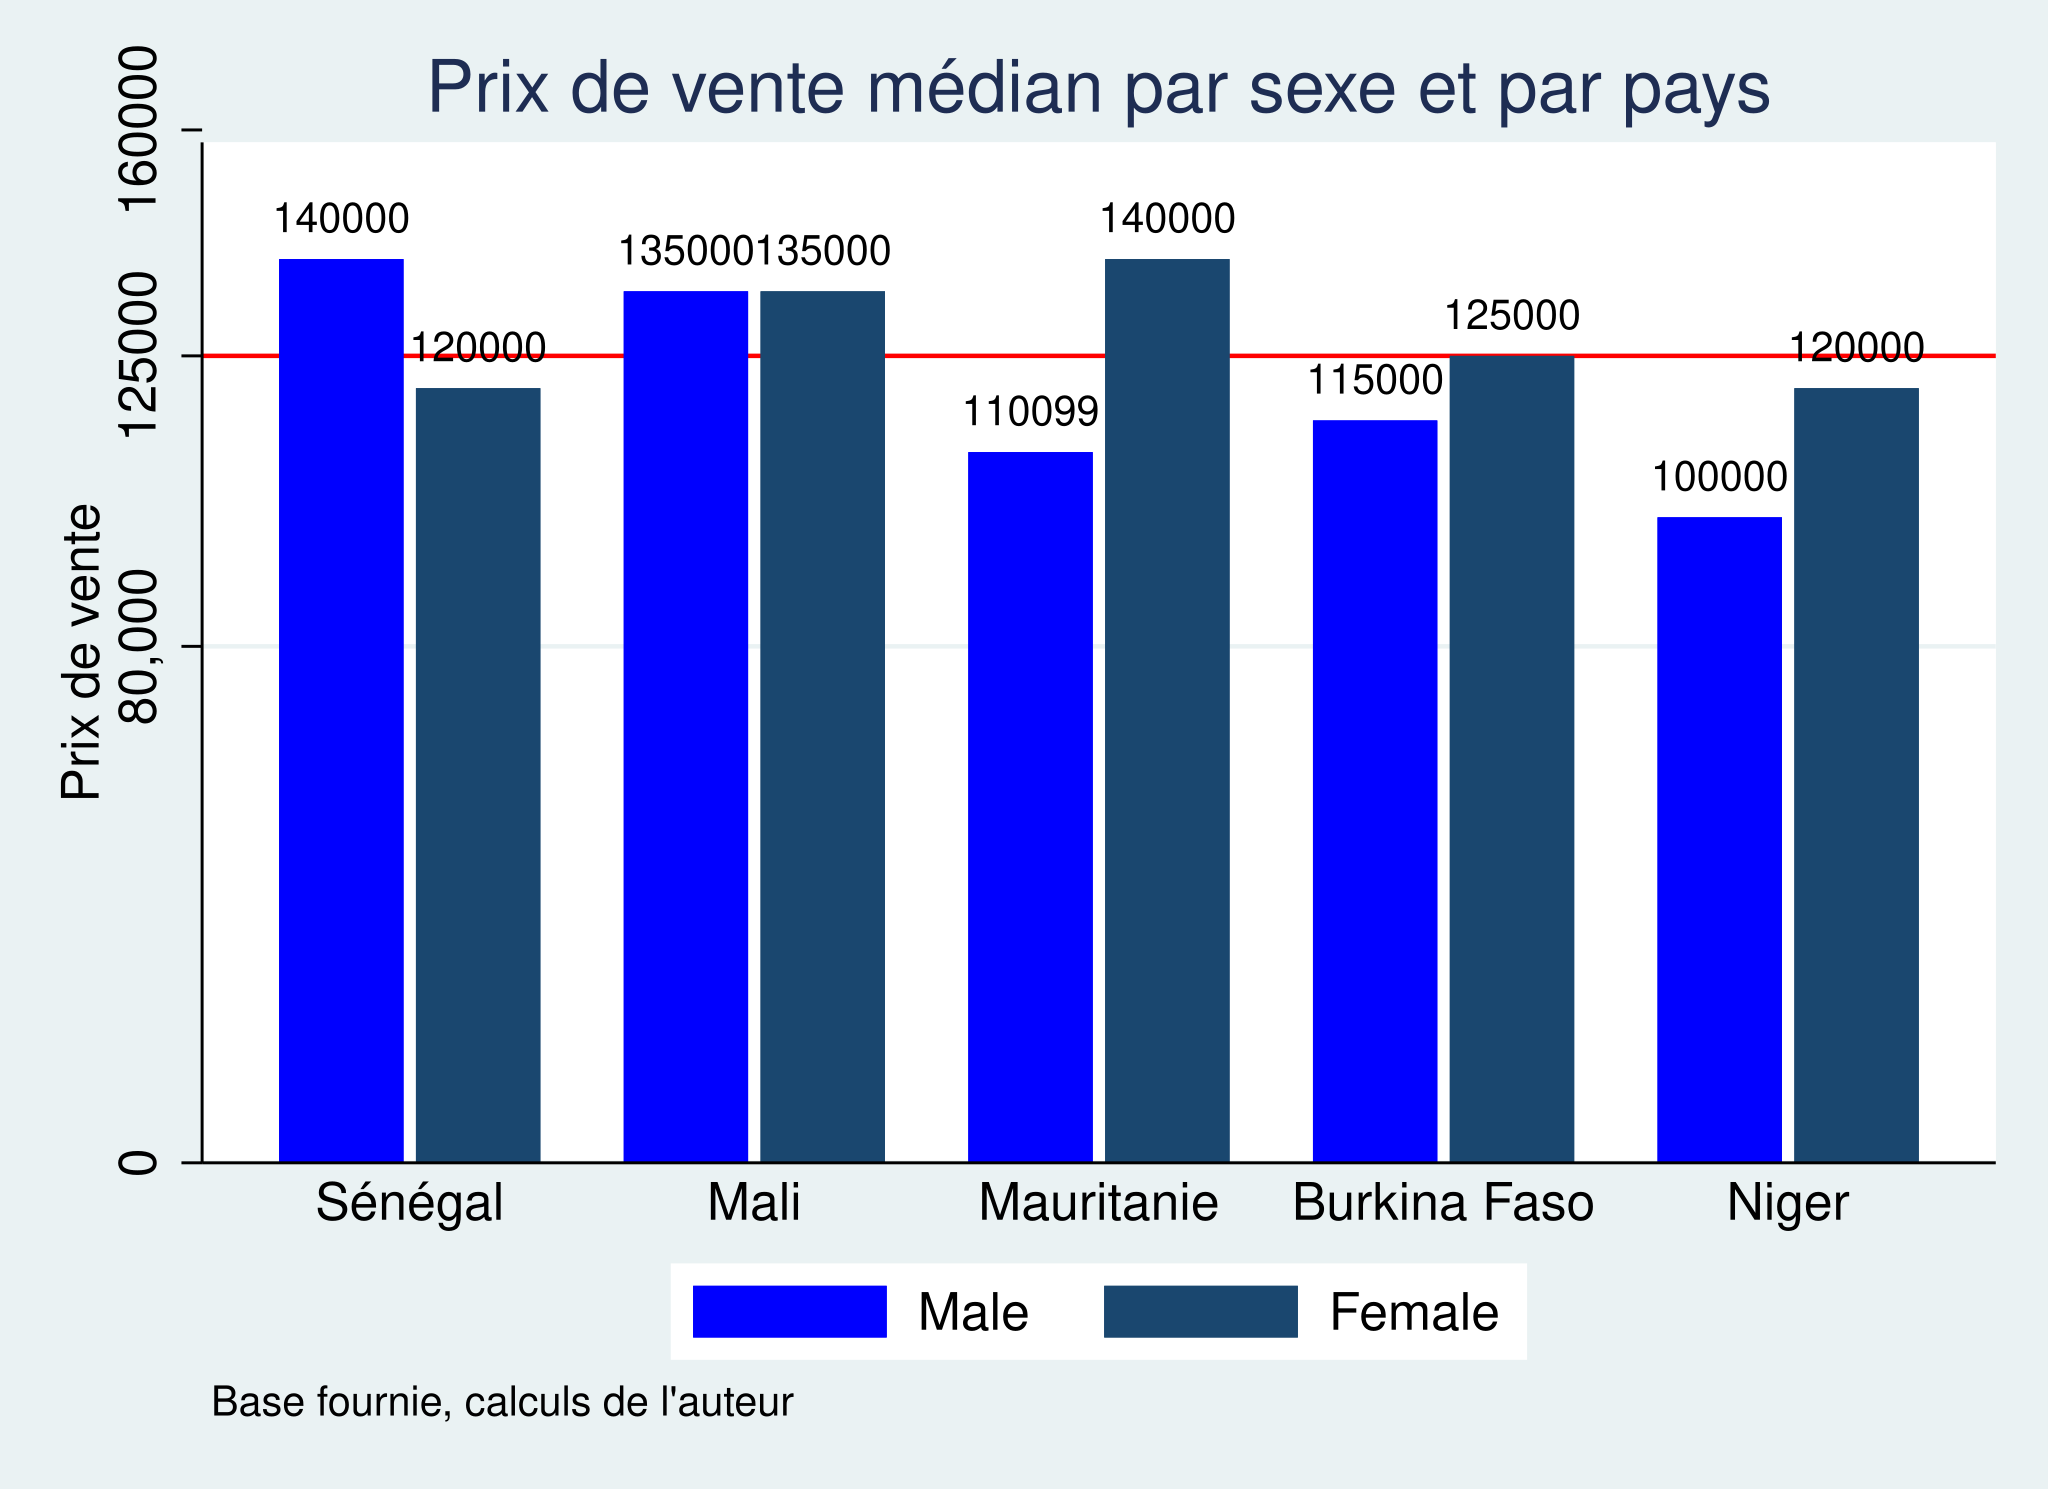

In [129]:
%%stata
graph bar (median) Prix, over(Sexe,label(nolabels)) over(country) asyvar bar(1,color(blue)) bar(2,color(navy)) legend(order(1 "Male" 2 "Female") position(6) region(lstyle(none))) blabel(bar,format(%9,0f)) title("Prix de vente médian par sexe et par pays") ytitle("Prix de vente") bargap(10) graphregion(color())  yline(125000, lcolor(red) lwidth(medium) lpattern(solid))  ylabel(0(80000)150000 125000 , add) note("Base fournie, calculs de l'auteur")  text(125000 0.5 , place(e) size(medium) color(red))
graph export "${outputs}/prix_median_par_sexe.png", replace


. graph box Prix, over(Sexe) over(country) ///
>     box(1, color(blue)) box(2, color(navy)) ///
>     legend(order(1 "Male" 2 "Female") position(6) region(lstyle(none))) ///
>     title("Prix de vente médian par sexe et par pays") ///
>     ytitle("Prix de vente") ///
>     yline(125000, lcolor(red) lwidth(medium) lpattern(solid)) ///
>     ylabel(0(100000)400000 , add) ///
>     note("Base fournie, calculs de l'auteur") ///
>     text(125000 0.5, place(e) size(medium) color(red))

. 
. graph export "${outputs}/box_plot_prix_median.png", replace
file E:/Ecole/AS2/Semestre1/Stat_agricole/TP3_elevage_pastoral/TP_elevage/Outpu
> ts/box_plot_prix_median.png written in PNG format

. 


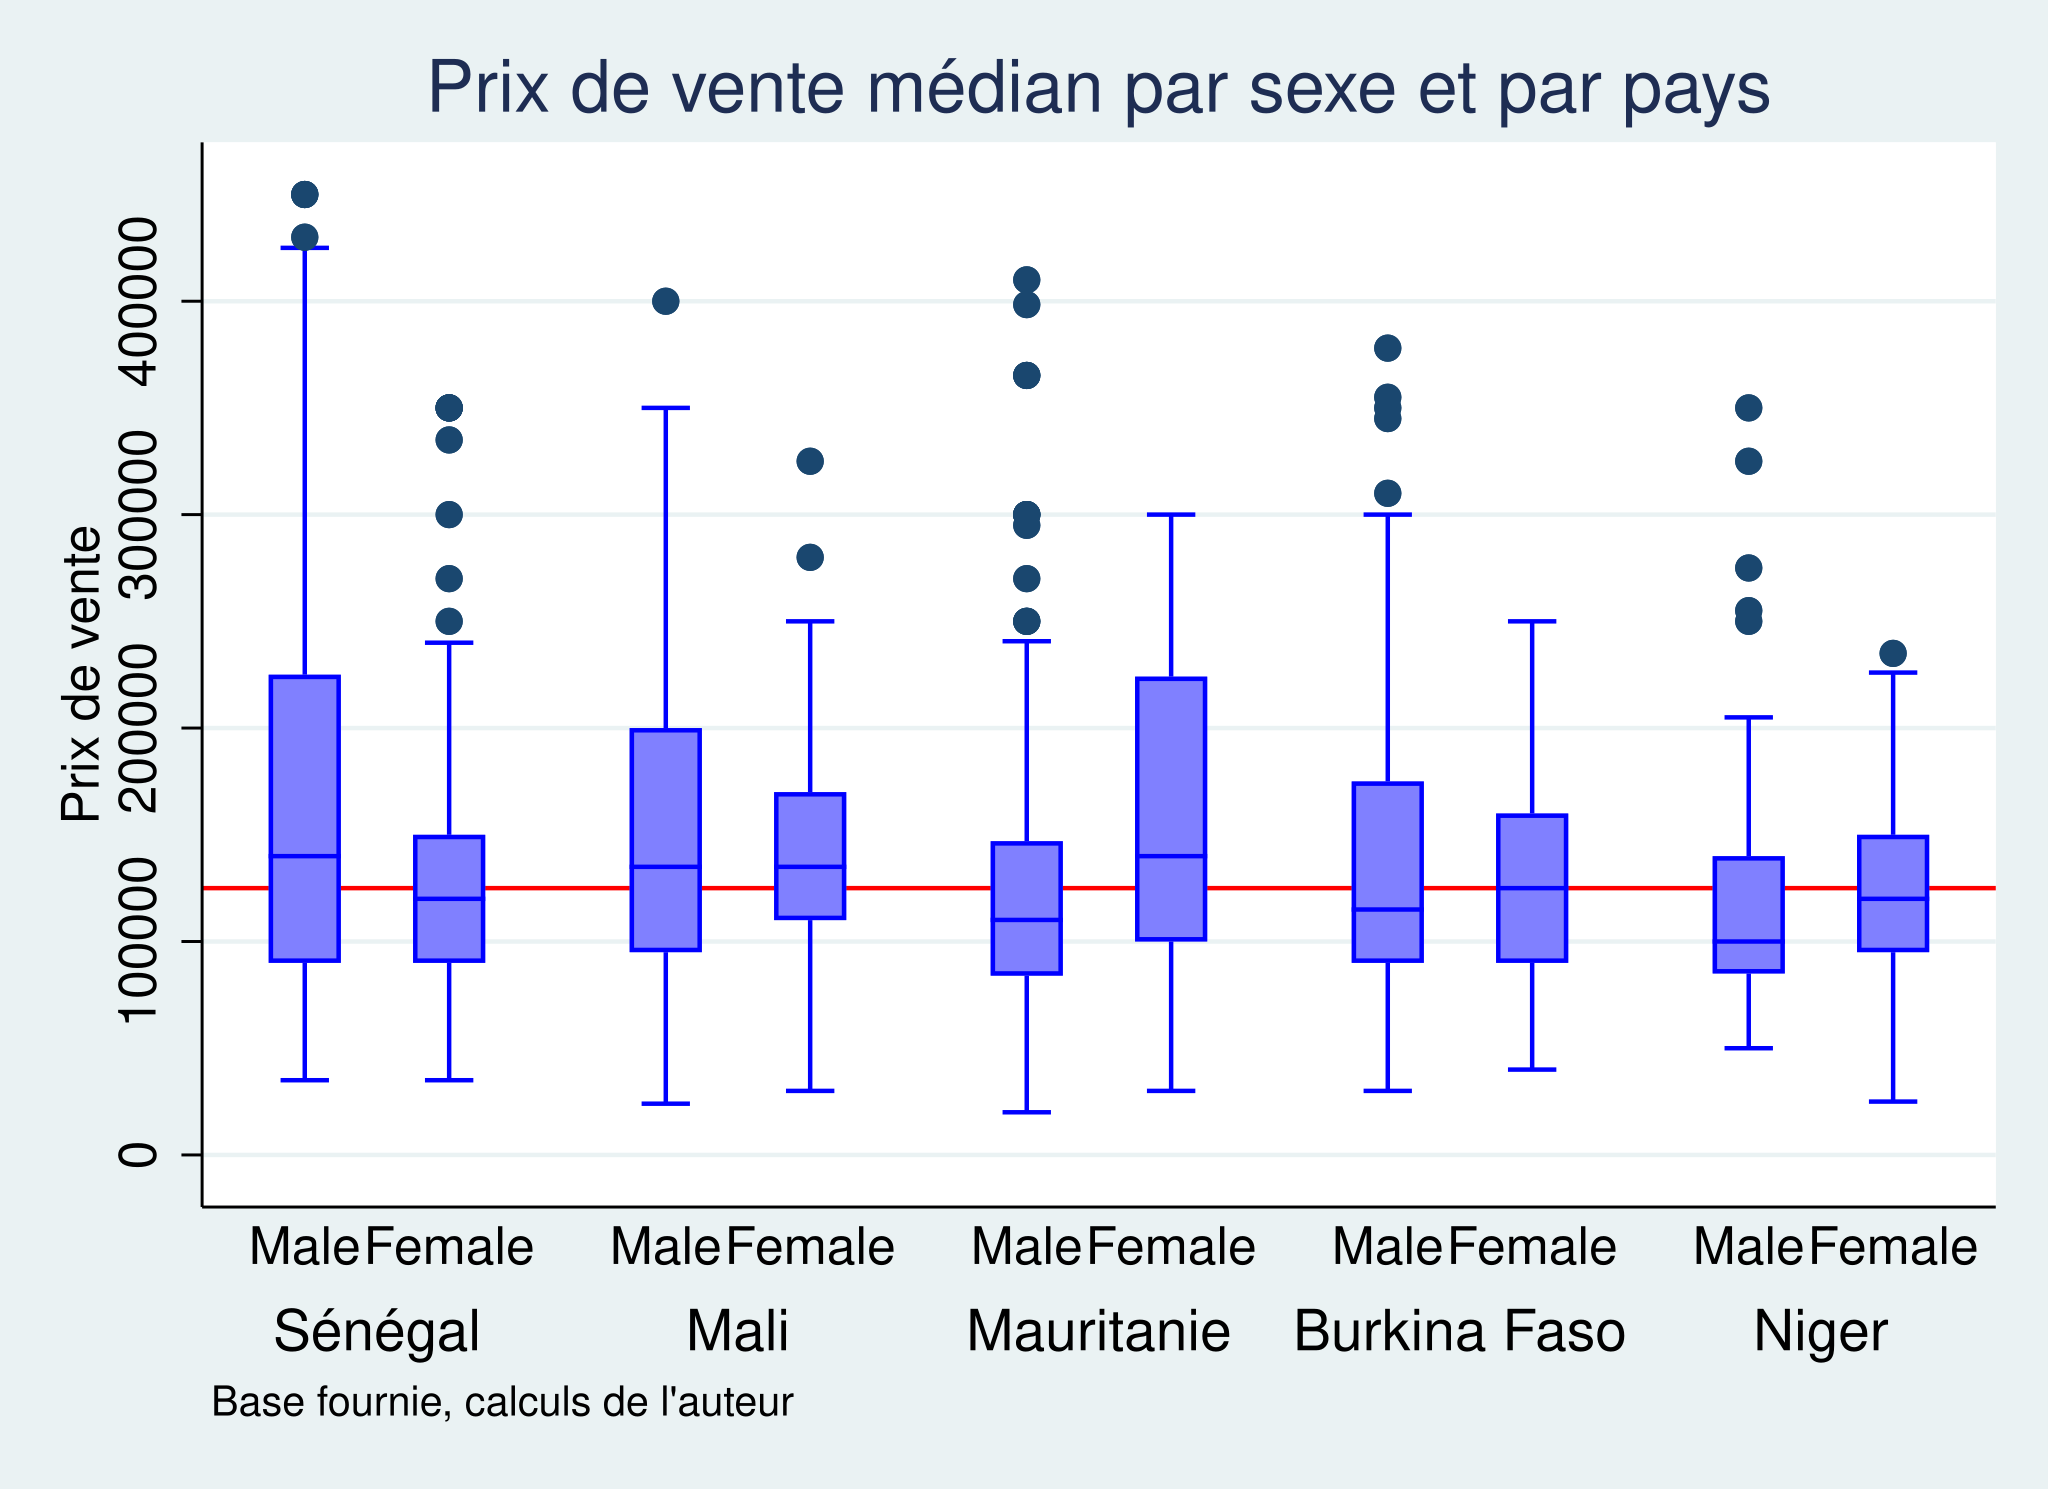

In [130]:
%%stata
graph box Prix, over(Sexe) over(country) ///
    box(1, color(blue)) box(2, color(navy)) ///
    legend(order(1 "Male" 2 "Female") position(6) region(lstyle(none))) ///
    title("Prix de vente médian par sexe et par pays") ///
    ytitle("Prix de vente") ///
    yline(125000, lcolor(red) lwidth(medium) lpattern(solid)) ///
    ylabel(0(100000)400000 , add) ///
    note("Base fournie, calculs de l'auteur") ///
    text(125000 0.5, place(e) size(medium) color(red))

graph export "${outputs}/box_plot_prix_median.png", replace

### 3. A travers une régression linéaire, modéliser le prix de vente en fonction du sexe, de l’âge, de l’origine, du type de client, de la période de vente et du pays. 
--------------------------------------------------------------------------------------------------------------------------------------------------------

Dans cette partie, il s'agit de modéliser le prix de vente à l'aide de variables jugées pertinentes. Pour y parvenir, nous commencerons par inspecter chacune des variables explicatives, afin de détecter d'éventuels **outliers**, puis nous transformerons nos données à travers des procédés tels que **la normalisation** ou **la standardisation**, afin de les ramener à la même échelle. Nous évaluerons également les relations existantes entre nos variables explicatives à travers **une matrice de correlation**, avant de passer à la modélisation proprement dite.

#### **Préparation des données**


. // Box plot des variables explicatives
. graph box Sexe Age Origine Aqui Mois country 

. graph export "${outputs}/box_plot_variables_explicatives.png", replace
file E:/Ecole/AS2/Semestre1/Stat_agricole/TP3_elevage_pastoral/TP_elevage/Outpu
> ts/box_plot_variables_explicatives.png written in PNG format

. 


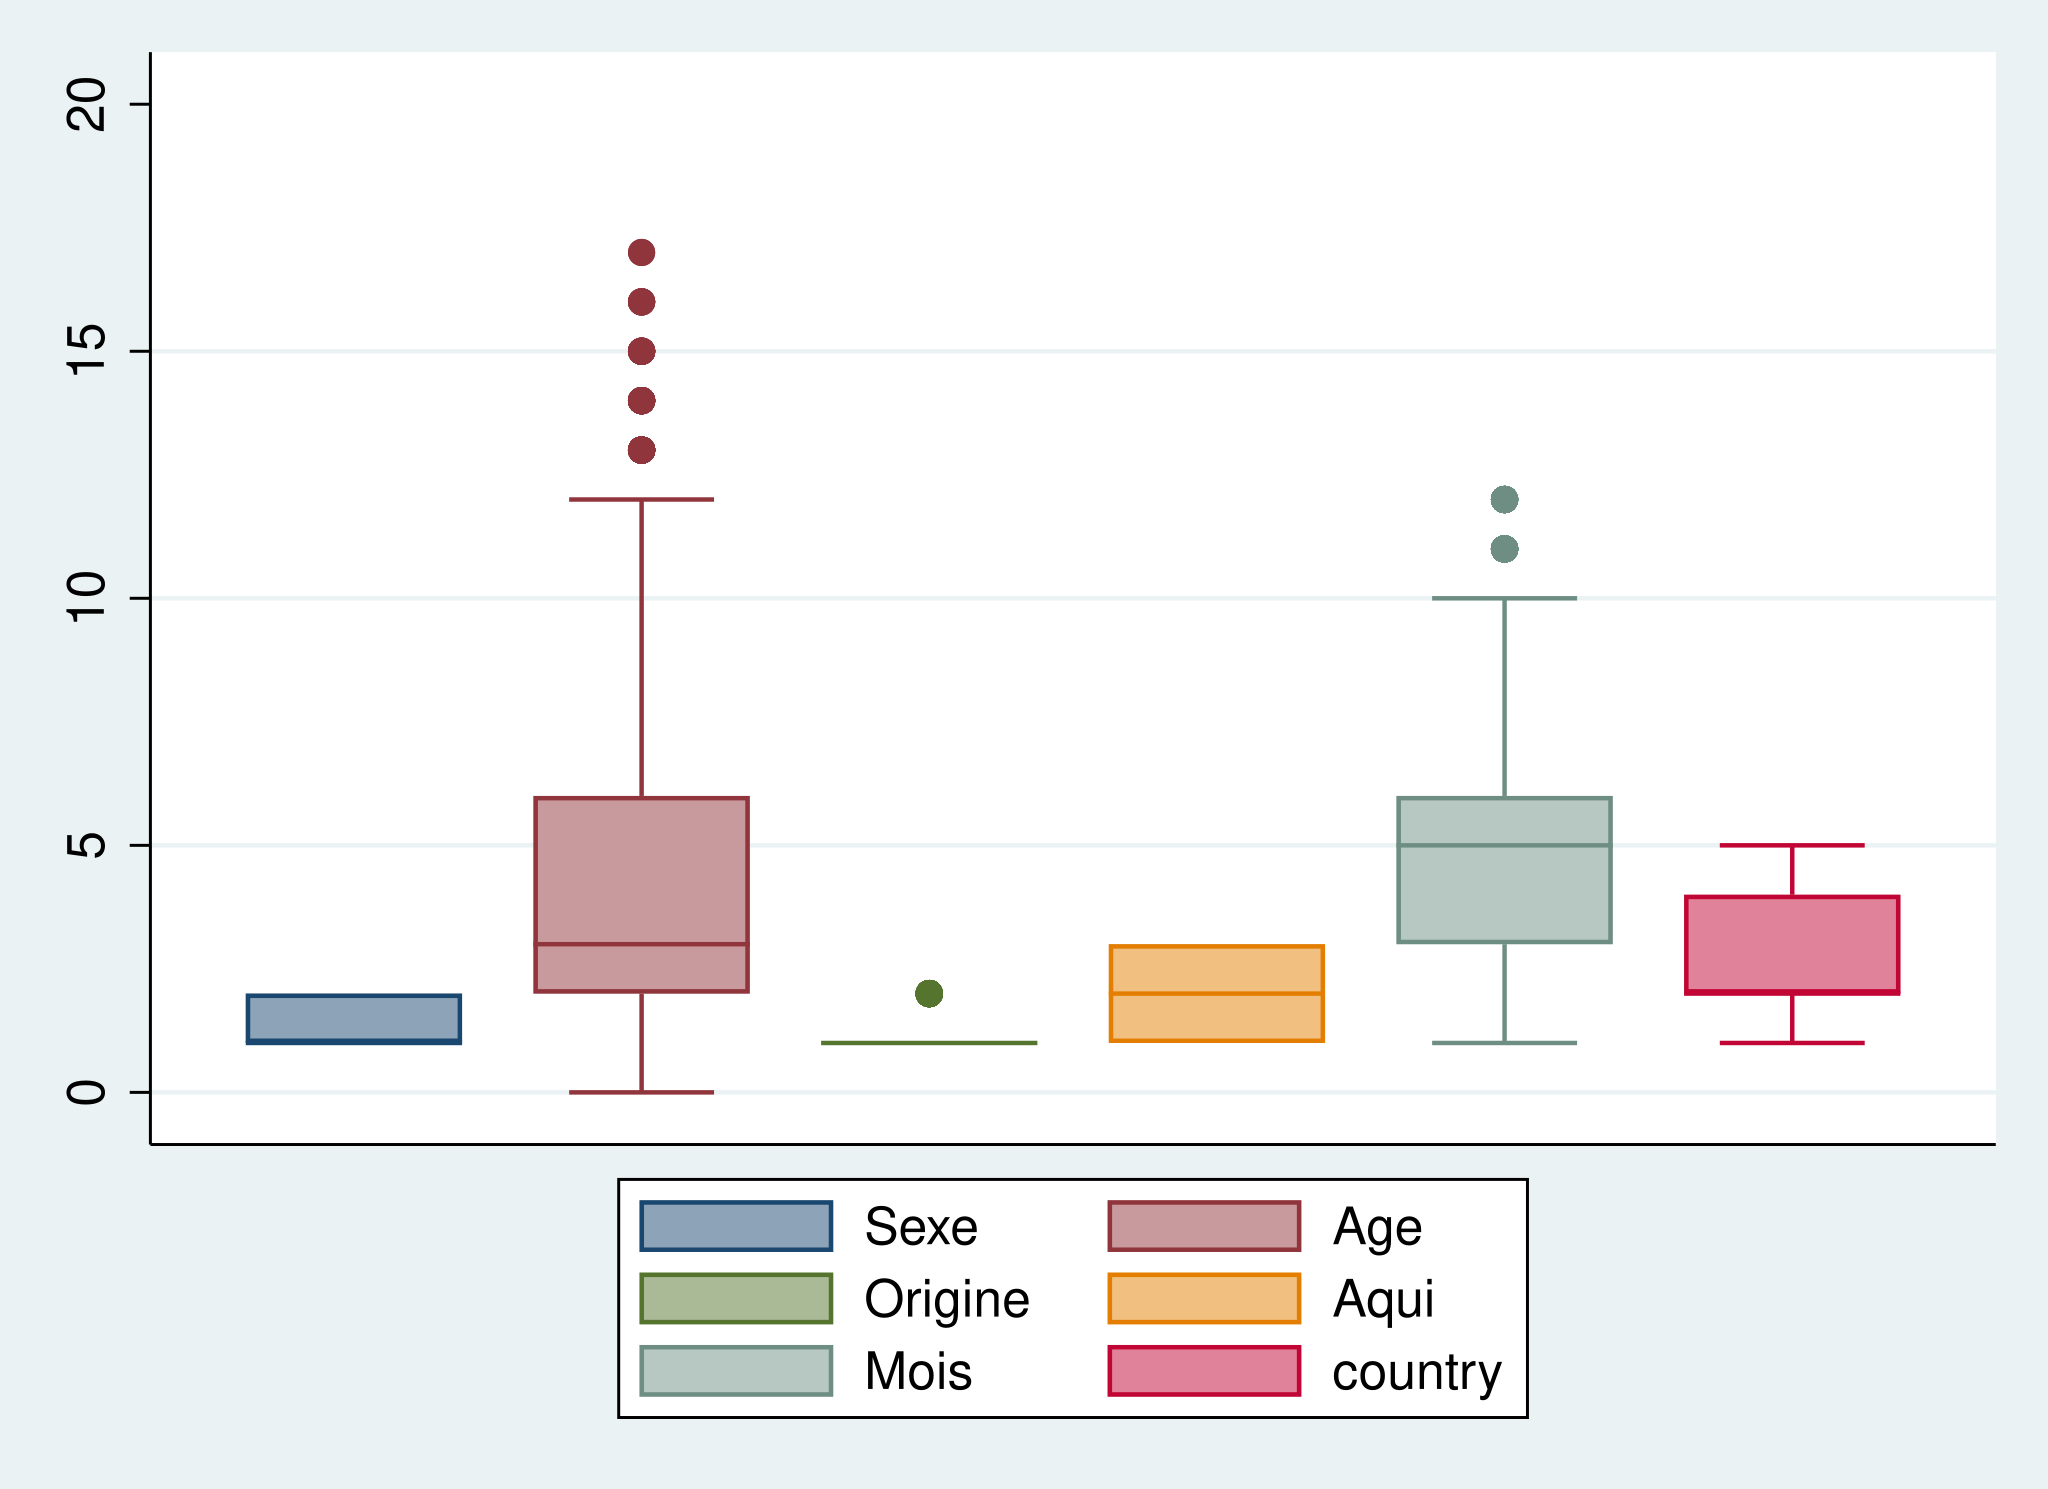

In [131]:
%%stata
// Box plot des variables explicatives
graph box Sexe Age Origine Aqui Mois country 
graph export "${outputs}/box_plot_variables_explicatives.png", replace


. // Box plot de la variable cible
. graph box Prix, title("Box plot du prix")

. graph export "${outputs}/box_plot_prix.png", replace
file E:/Ecole/AS2/Semestre1/Stat_agricole/TP3_elevage_pastoral/TP_elevage/Outpu
> ts/box_plot_prix.png written in PNG format

. 


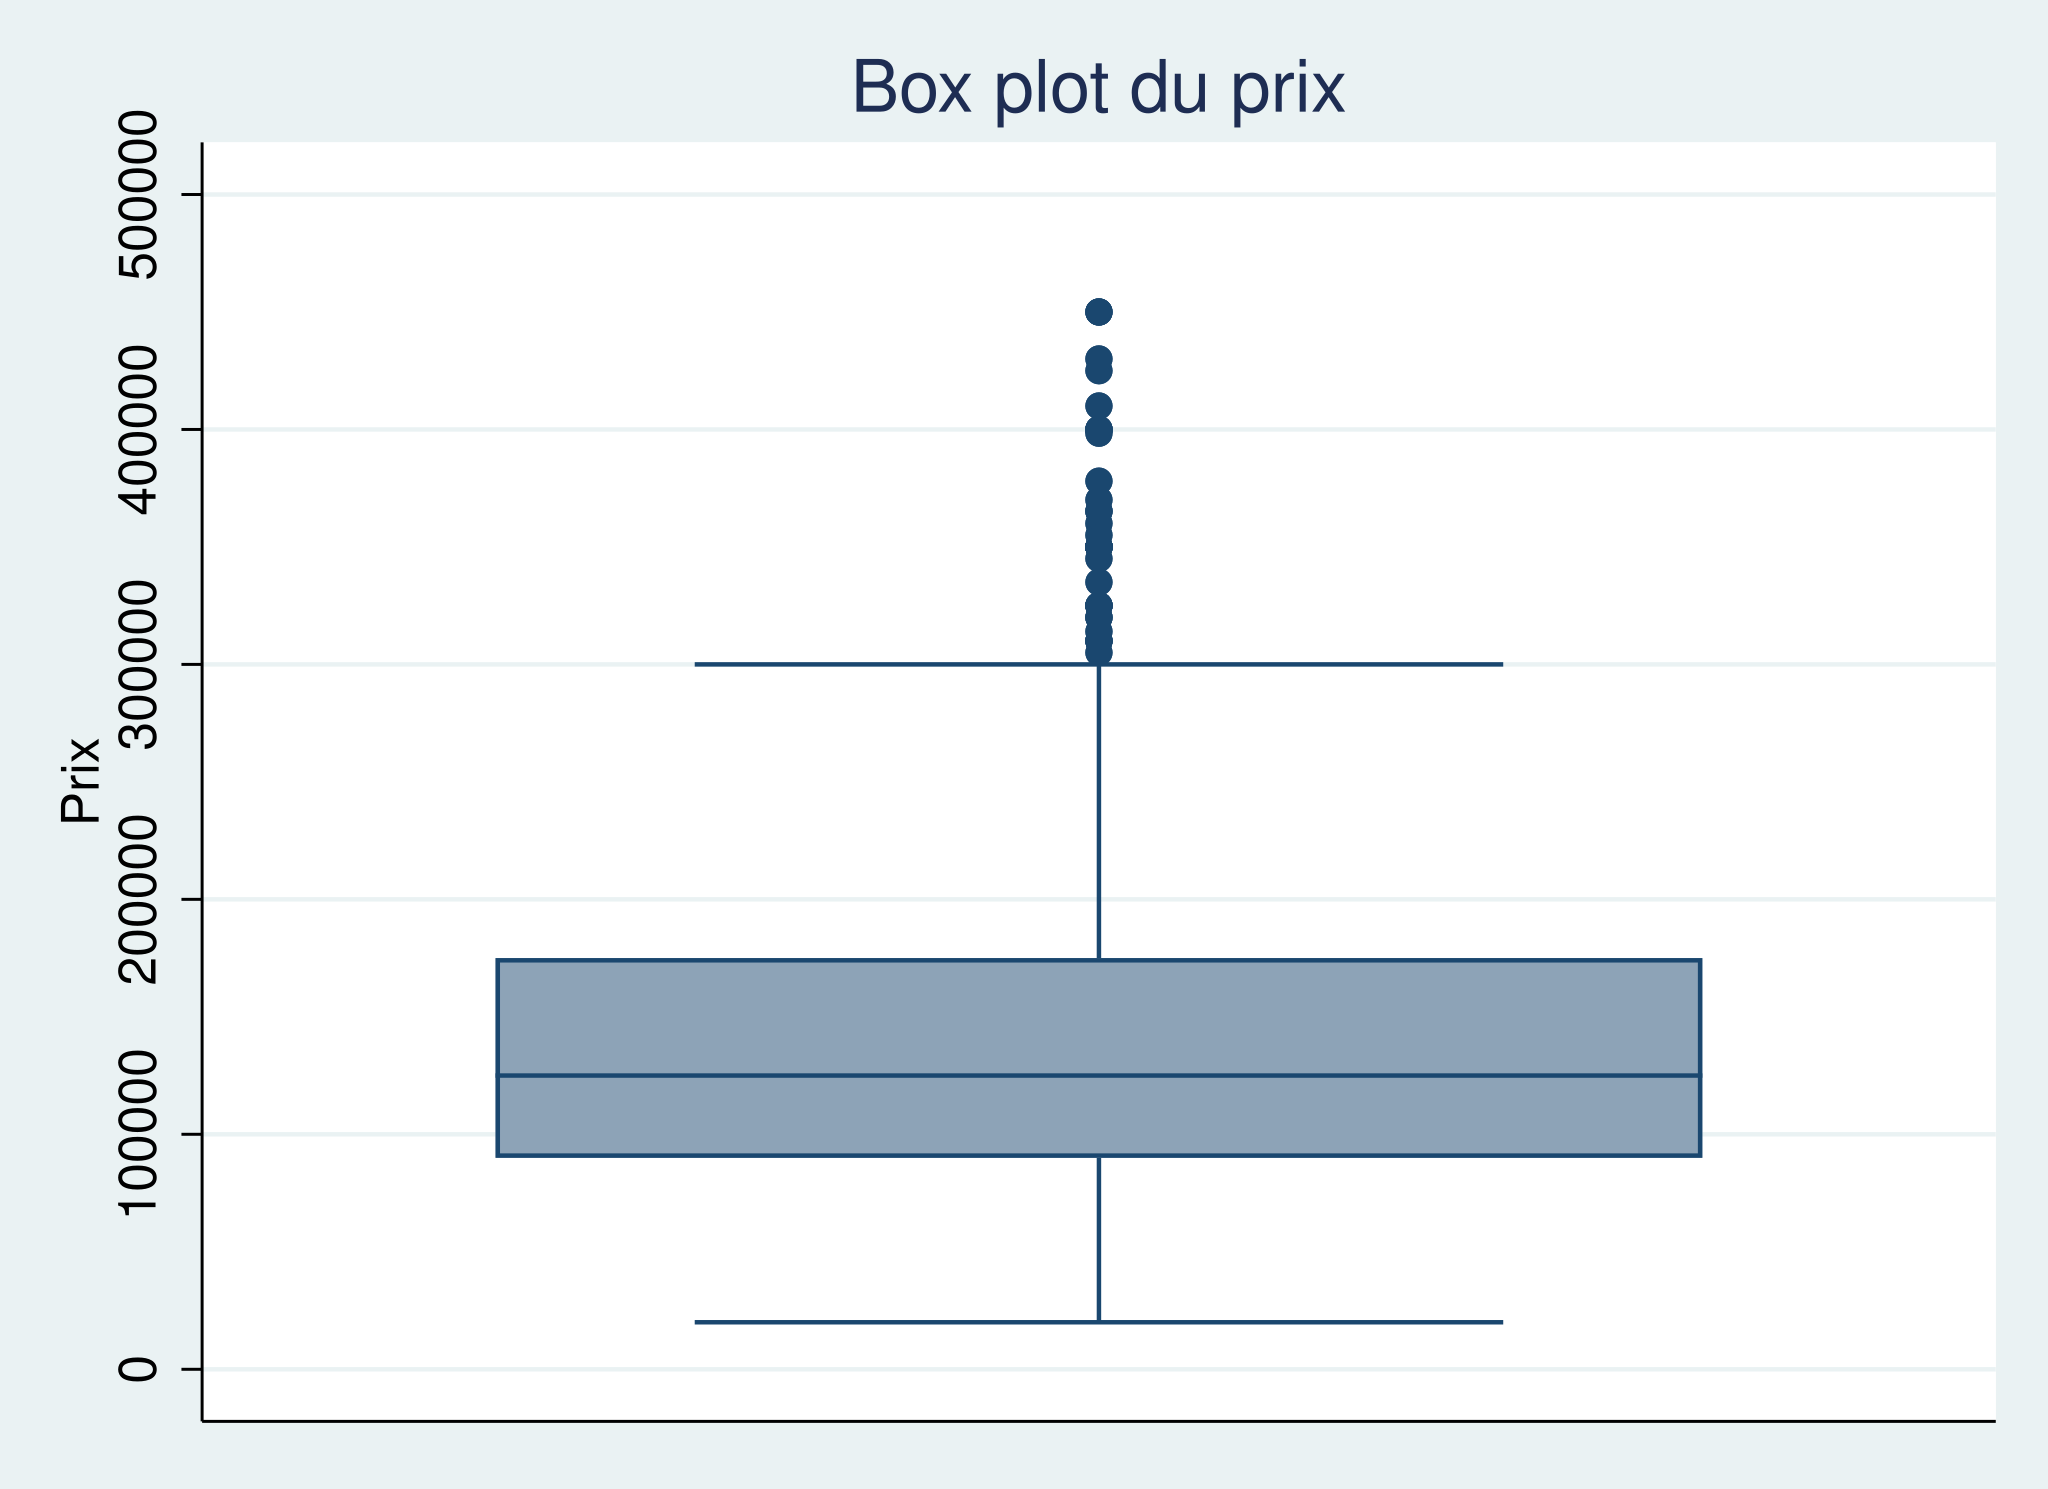

In [132]:
%%stata
// Box plot de la variable cible
graph box Prix, title("Box plot du prix")
graph export "${outputs}/box_plot_prix.png", replace

In [133]:
%%stata
capture{
// Normalisation
foreach var in  Age Mois Origine Aqui country{
        egen min_`var' = min(`var')
        egen max_`var' = max(`var')
        gen sd_`var' = max_`var' - min_`var'
        gen `var'_norm = (`var' - min_`var')/(sd_`var')
        drop min_`var' sd_`var' max_`var'
        tabstat `var'_norm, stat(count mean sd)
    }  
// Standardisation
foreach var in Age Mois Origine Aqui country {
    egen mean_`var' = mean(`var')
    egen sd_`var' = sd(`var')
    gen `var'_sd = (`var' - mean_`var') / sd_`var'
    drop mean_`var' sd_`var'
    
    tabstat `var'_sd, stat(count mean sd)
}
}


. capture{

. 



. // Box plot après normalisation
. graph box Sexe Age_norm Origine_norm Aqui_norm Mois_norm country_norm, title(
> "Box plot après normalisation")

. 


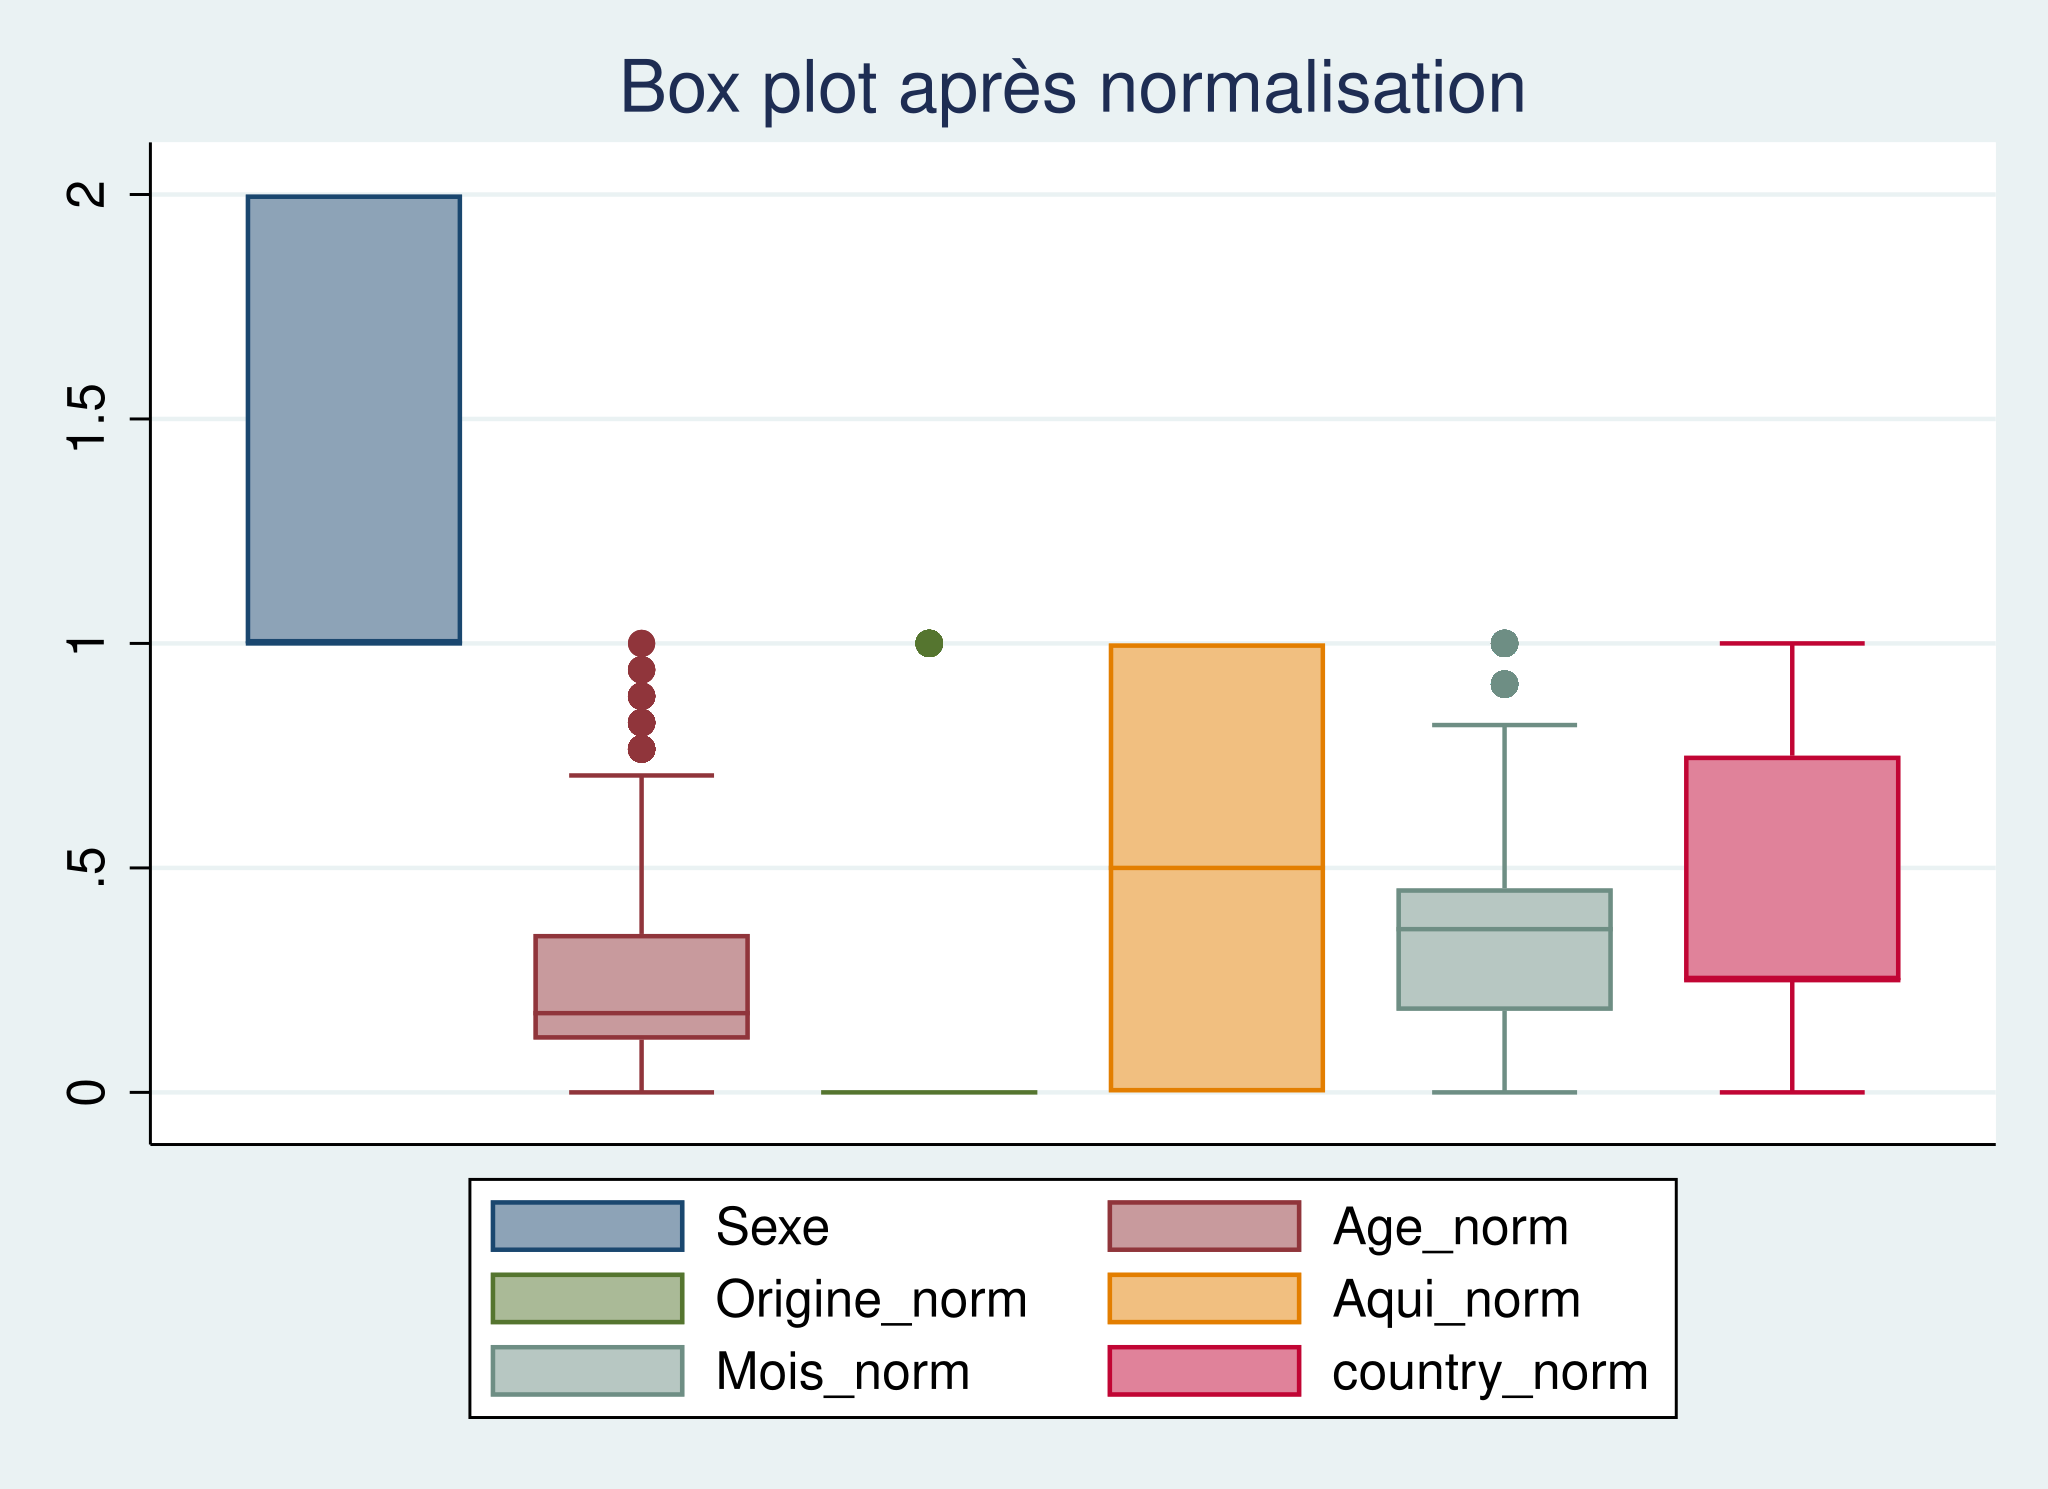

In [134]:
%%stata
// Box plot après normalisation
graph box Sexe Age_norm Origine_norm Aqui_norm Mois_norm country_norm, title("Box plot après normalisation")


. // Box plot après standardisation
. graph box Sexe Age_sd Origine_sd Aqui_sd Mois_sd country_sd, title("Box plot 
> après standardisation")

. 


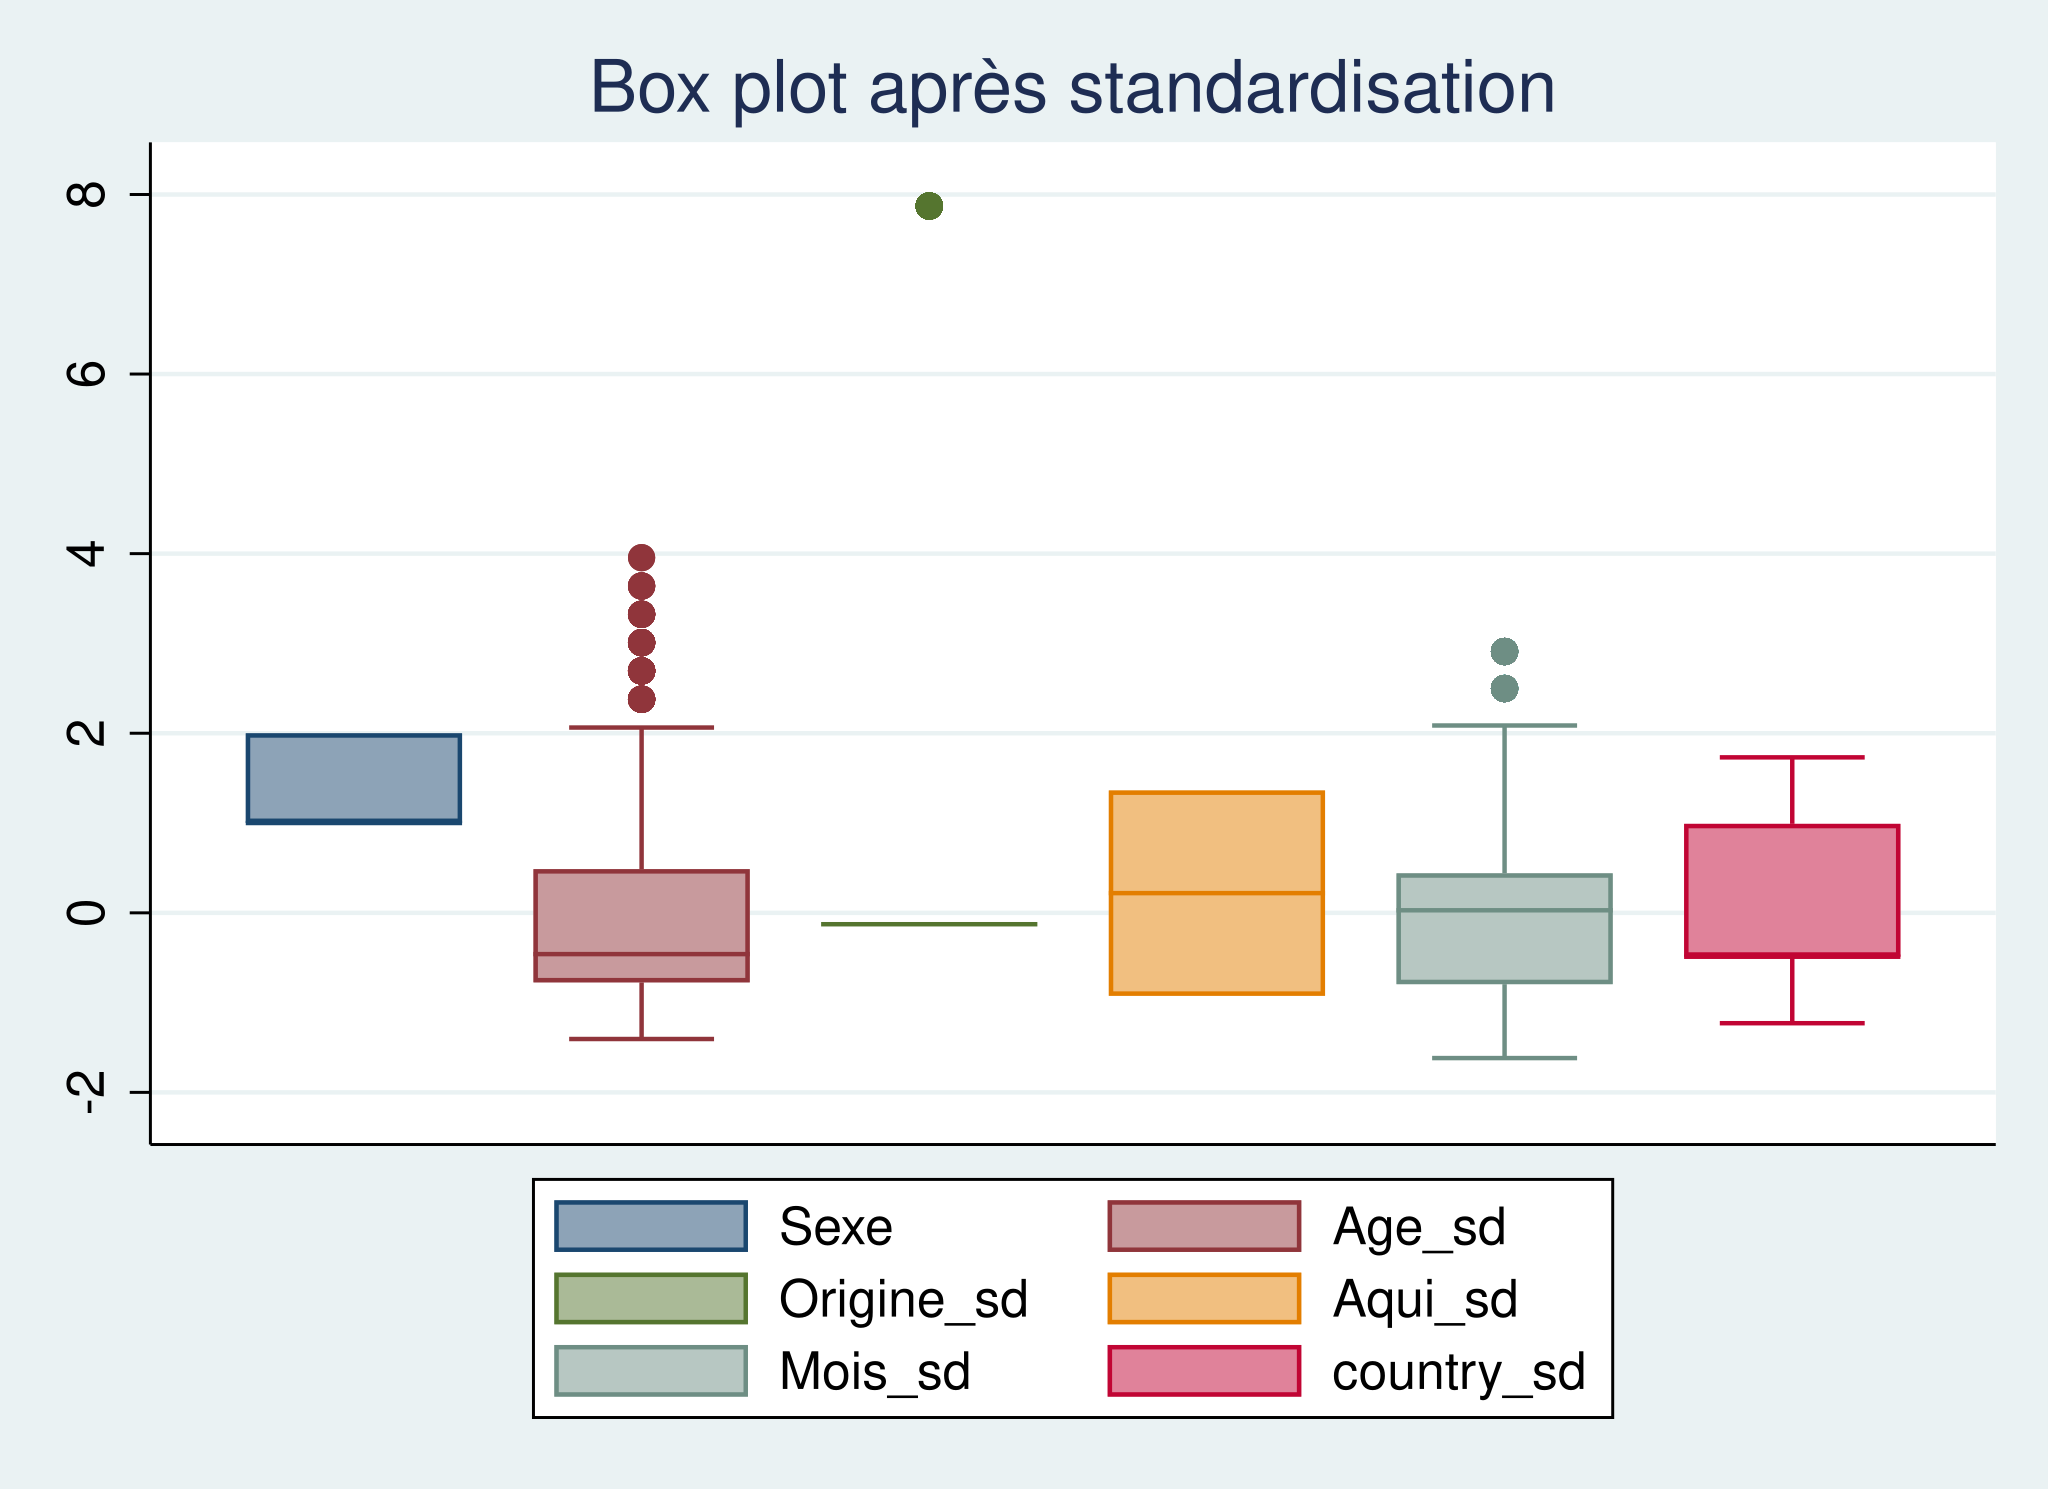

In [135]:
%%stata
// Box plot après standardisation
graph box Sexe Age_sd Origine_sd Aqui_sd Mois_sd country_sd, title("Box plot après standardisation")

In [136]:
%%stata
// Matrice de correlation
pwcorr Sexe Age Origine Aqui Mois country Prix, sig


. // Matrice de correlation
. pwcorr Sexe Age Origine Aqui Mois country Prix, sig

             |     Sexe      Age  Origine     Aqui     Mois  country     Prix
-------------+---------------------------------------------------------------
        Sexe |   1.0000 
             |
             |
         Age |   0.4195   1.0000 
             |   0.0000
             |
     Origine |   0.0137  -0.0218   1.0000 
             |   0.6027   0.4081
             |
        Aqui |   0.0006  -0.0192  -0.0229   1.0000 
             |   0.9817   0.4688   0.3860
             |
        Mois |   0.0297   0.0702  -0.0057  -0.0546   1.0000 
             |   0.2658   0.0085   0.8307   0.0405
             |
     country |  -0.0354  -0.0864  -0.0096  -0.1401  -0.0552   1.0000 
             |   0.1793   0.0010   0.7148   0.0000   0.0378
             |
        Prix |  -0.0792   0.2633  -0.0651  -0.0547   0.0129  -0.1130   1.0000 
             |   0.0026   0.0000   0.0132   0.0381   0.6267   0.0000
            

### **Modélisation**

<span style="color:blue;font-weight:bold;font-size:13pt">Modèle 1 </span>

In [137]:
%%stata
capture{
// Identification des valeurs extrêmes
gen is_outlier=0
foreach varname in Age_sd Origine_sd Mois_sd{
    * Calculer les bornes inférieure et supérieure pour identifier les valeurs aberrantes
    summarize `varname', detail
    scalar lower_bound = r(p25) - 1.5 * (r(p75) - r(p25))  // Limite inférieure
    scalar upper_bound = r(p75) + 1.5 * (r(p75) - r(p25))  // Limite supérieure
    
    * Créer une variable qui identifie les valeurs aberrantes
    replace is_outlier = cond(`varname' < lower_bound |`varname'  > upper_bound,1,is_outlier)
}
}


. capture{

. 



. reg Prix Sexe Age_sd Origine_sd Aqui_sd Mois_sd country_sd if !(is_outlier==1
> )
note: Origine_sd omitted because of collinearity.

      Source |       SS           df       MS      Number of obs   =     1,251
-------------+----------------------------------   F(5, 1245)      =     48.15
       Model |  9.8633e+11         5  1.9727e+11   Prob > F        =    0.0000
    Residual |  5.1001e+12     1,245  4.0965e+09   R-squared       =    0.1621
-------------+----------------------------------   Adj R-squared   =    0.1587
       Total |  6.0865e+12     1,250  4.8692e+09   Root MSE        =     64004

------------------------------------------------------------------------------
        Prix | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        Sexe |  -32546.83    3996.39    -8.14   0.000    -40387.23   -24706.43
      Age_sd |   33114.68   2371.397    13.96   0.000      28462.3    377

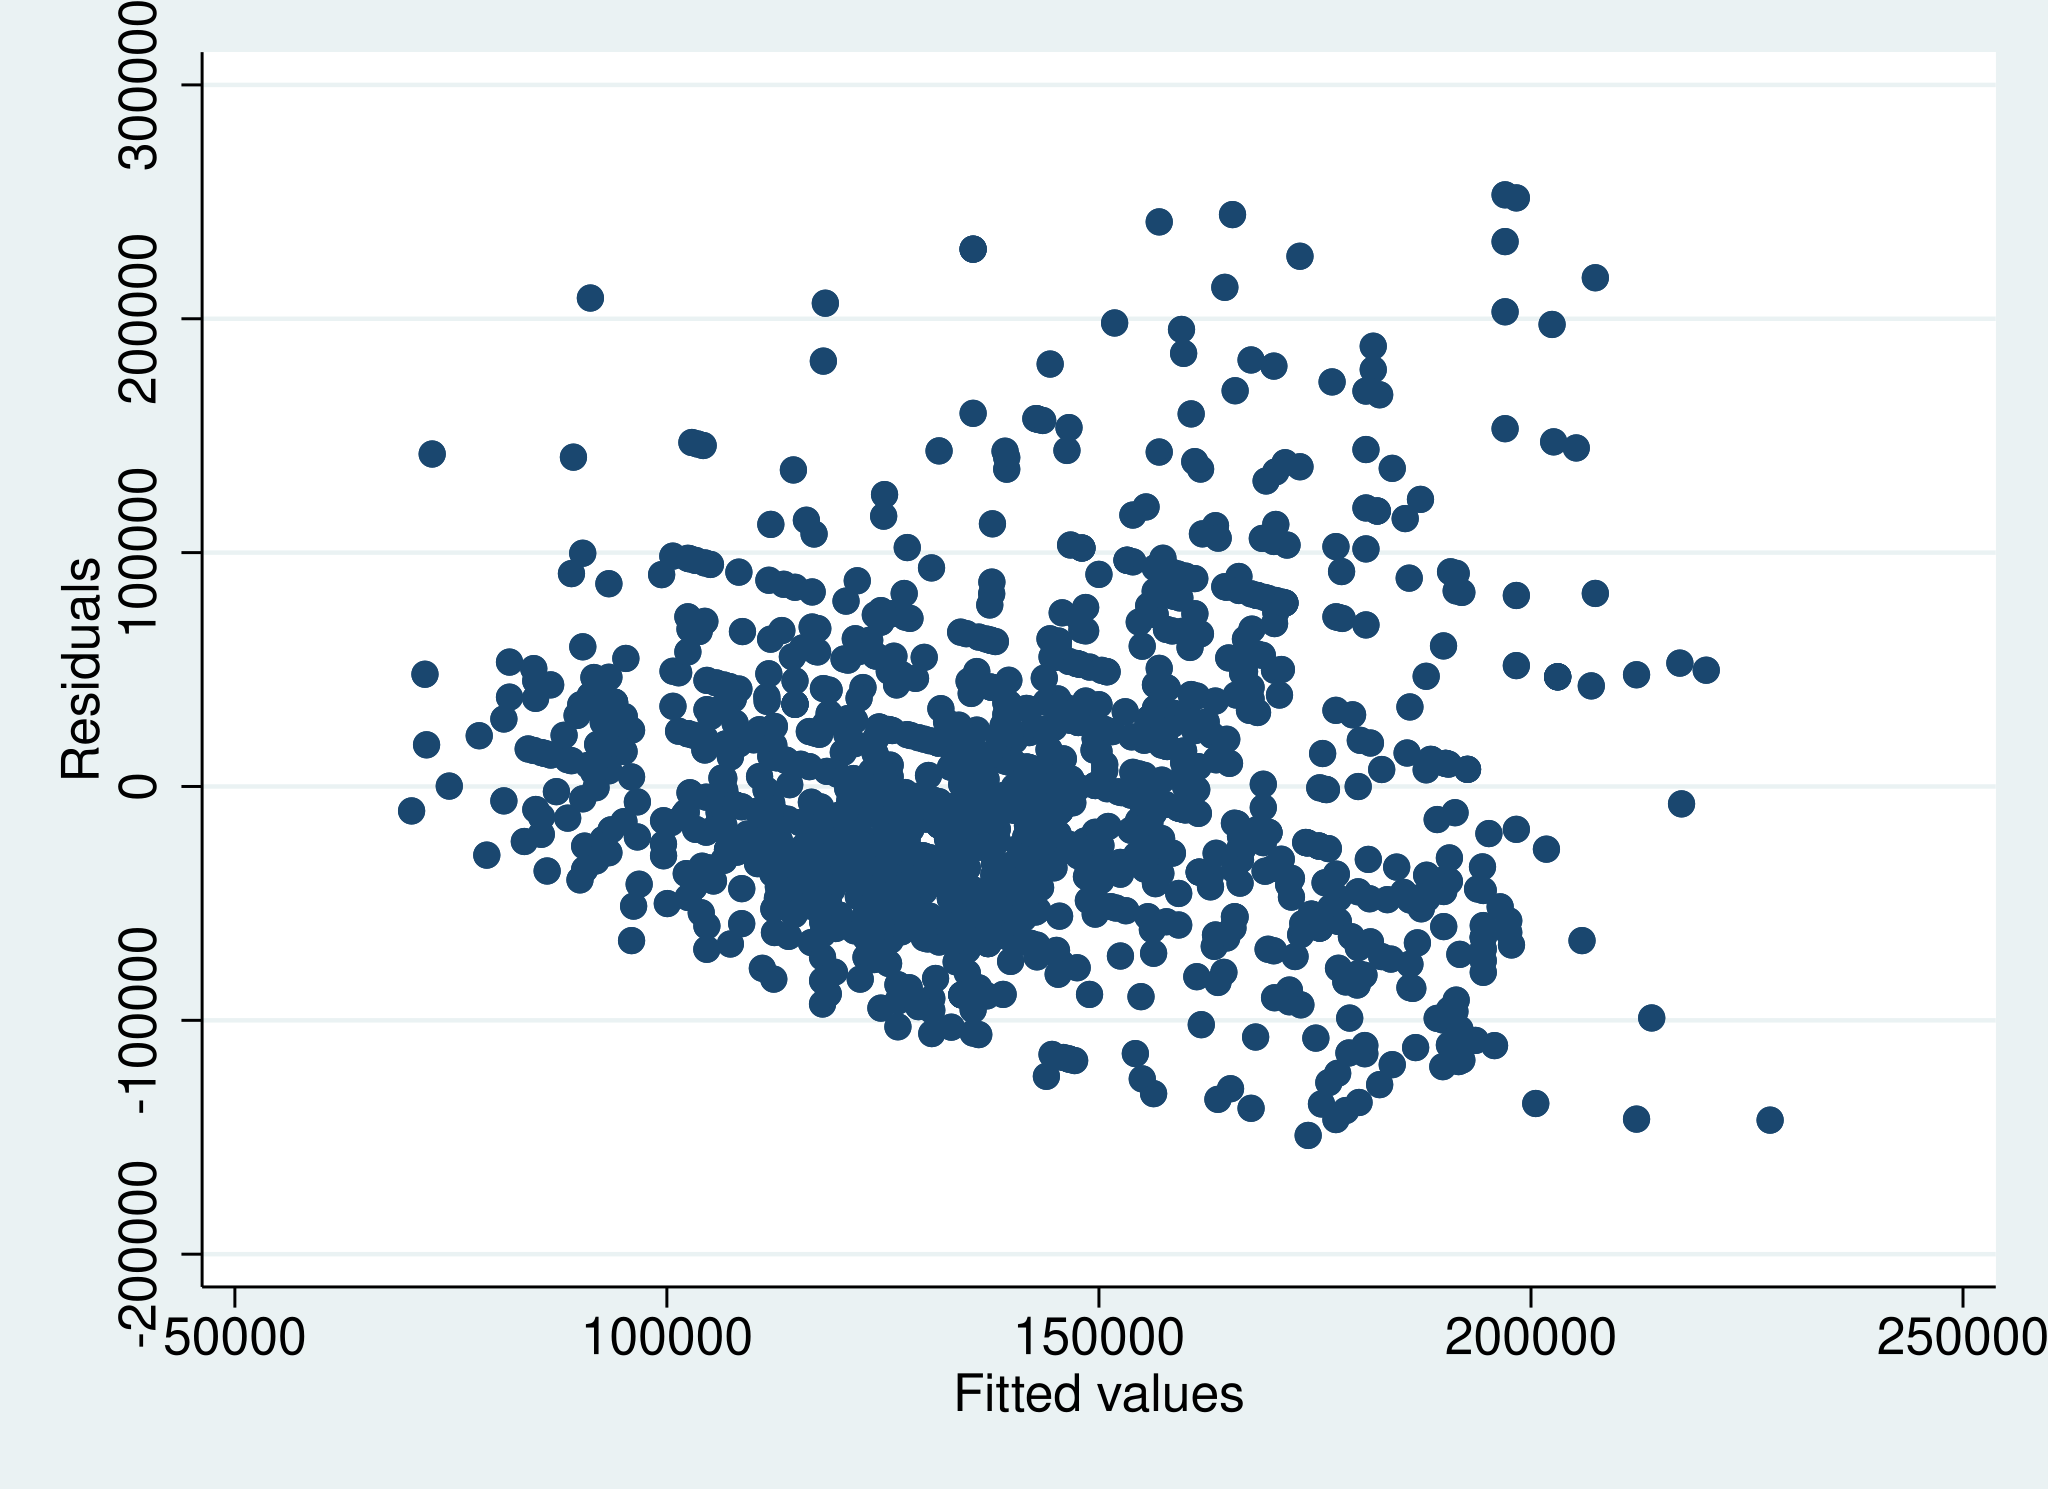

In [138]:
%%stata
reg Prix Sexe Age_sd Origine_sd Aqui_sd Mois_sd country_sd if !(is_outlier==1)

//résidus vs valeurs ajustées
rvfplot
graph export "${outputs}/rvfplot_modele1.png", replace

Le nuage ci dessus montre la distribution des résidus en fonction des valeurs prédites par le modèle. On observe une distribution de par et d'autres de la ligne horizontale **y=0**. Cependant, cette distribution ne semble pas être aléatoire. En effet, une parabole semble se dessiner à travers cette distribution. Cela pourrait indiquer un mauvais choix de variable, ou alors une non-linéarité.


. //Valeurs prédites par le premier modèle
. quietly predict Prix1

. 
. kdensity Prix, lcolor(blue) lwidth(medium) title("Distribution : Observée vs 
> Estimée (modèle 1)") legend(order(1 "Prix Observée" 2 "Prix Estimée")) addplo
> t(kdensity Prix1, lcolor(red) lwidth(medium))

. graph export "${outputs}/estimations_modele1.png", replace                   
>                                             
file E:/Ecole/AS2/Semestre1/Stat_agricole/TP3_elevage_pastoral/TP_elevage/Outpu
> ts/estimations_modele1.png written in PNG format

. 


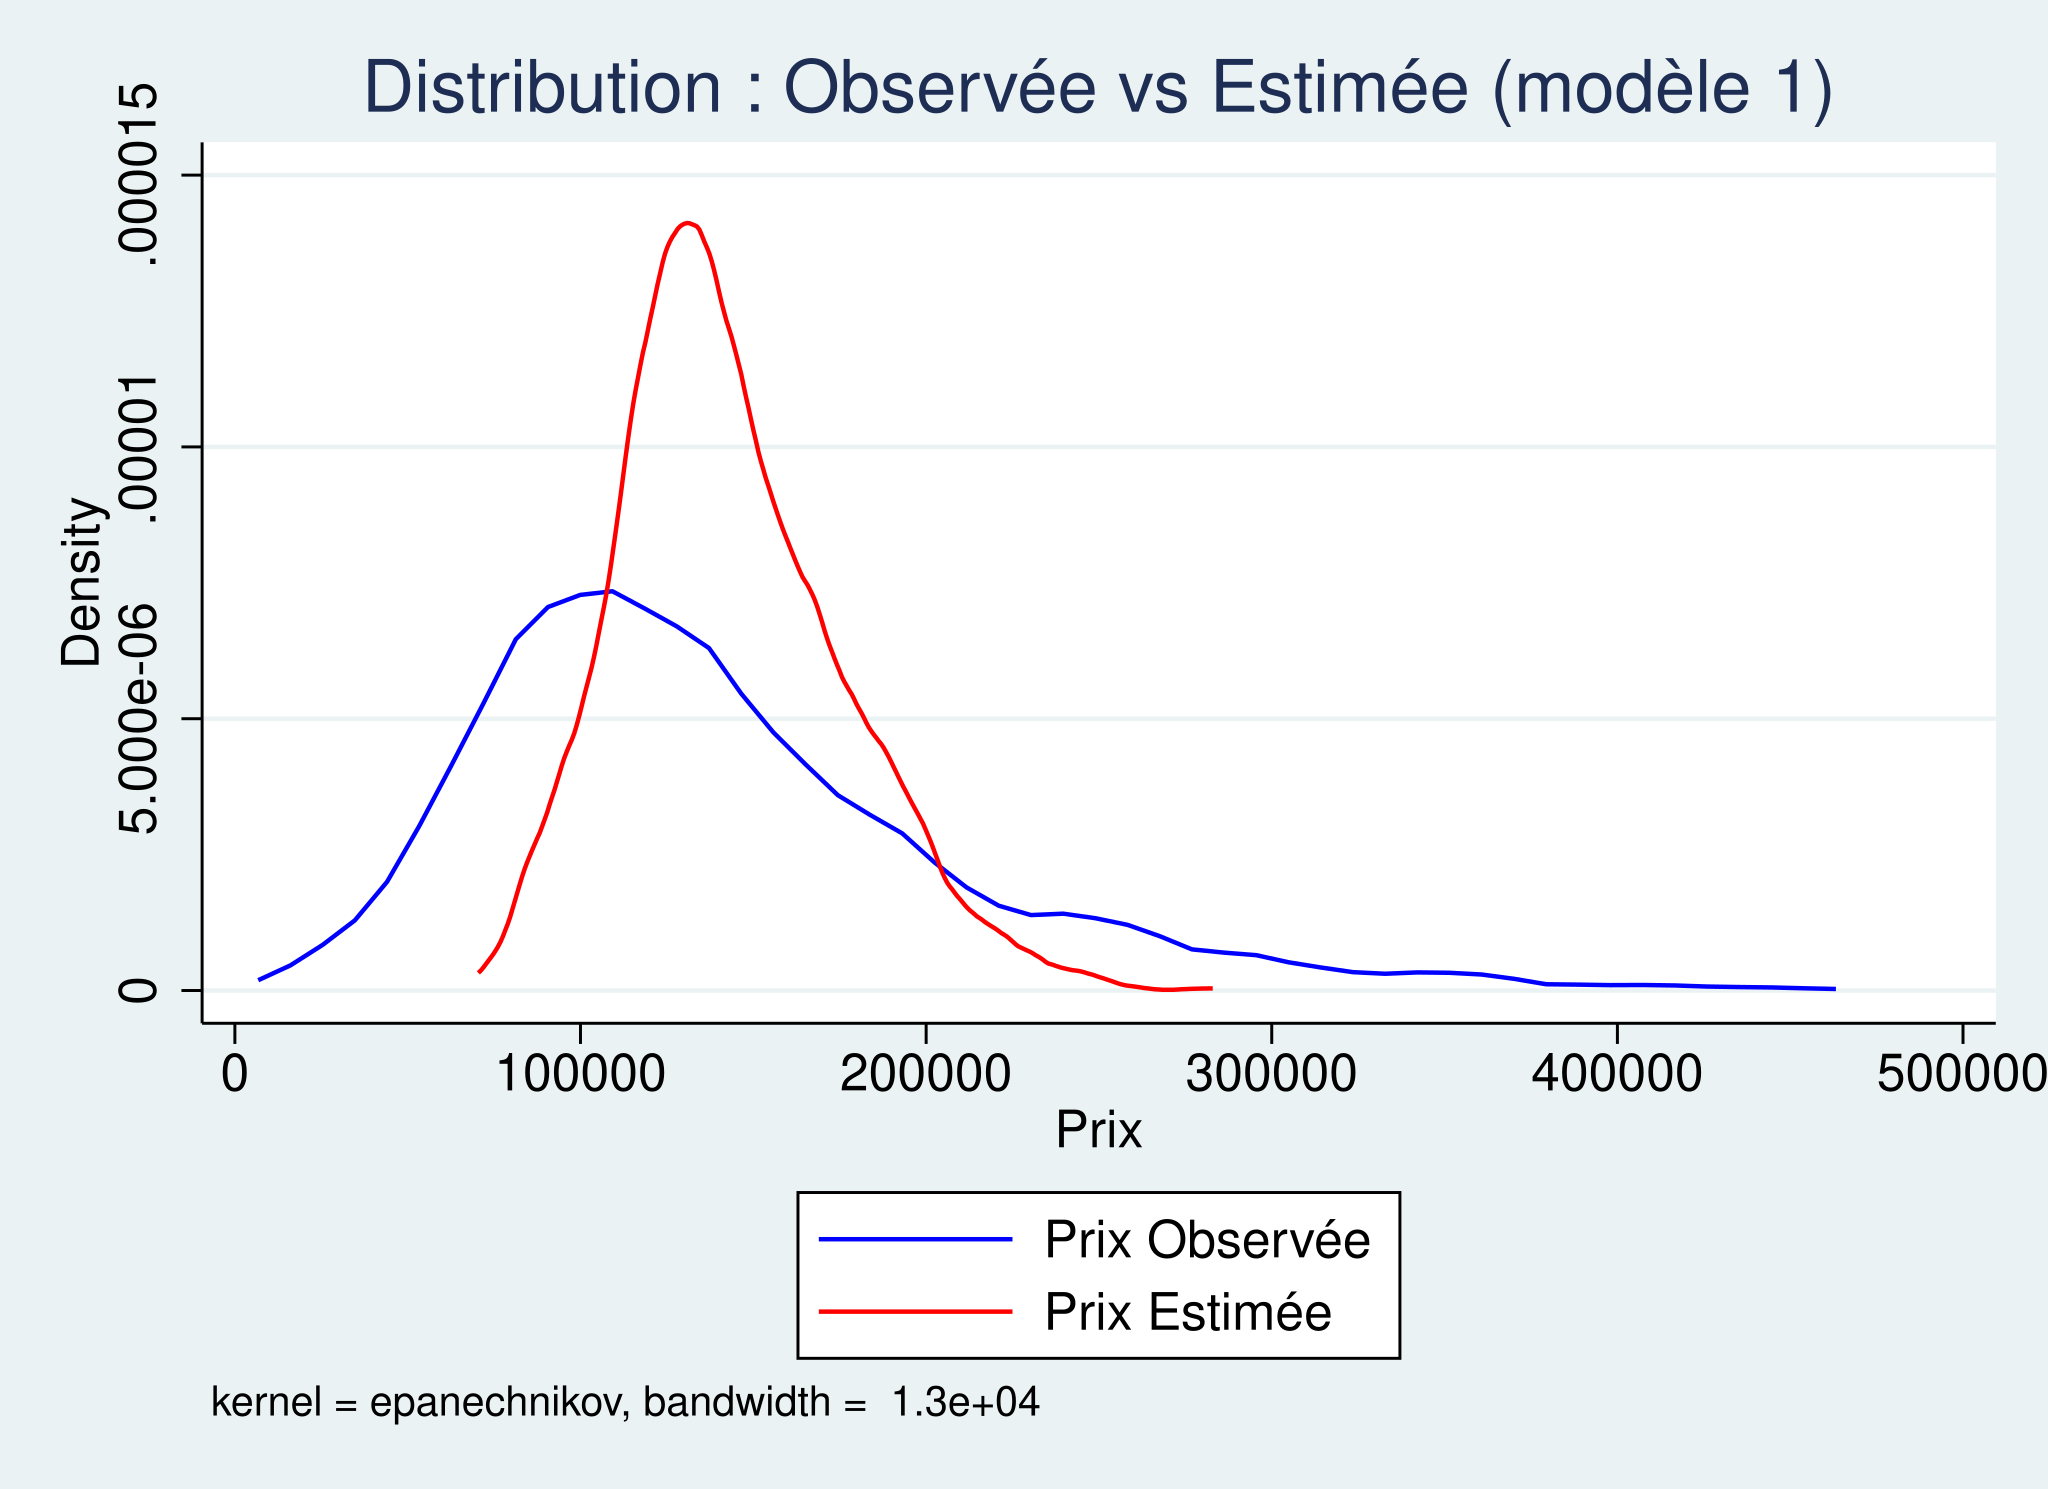

In [139]:
%%stata
//Valeurs prédites par le premier modèle
quietly predict Prix1

kdensity Prix, lcolor(blue) lwidth(medium) title("Distribution : Observée vs Estimée (modèle 1)") legend(order(1 "Prix Observée" 2 "Prix Estimée")) addplot(kdensity Prix1, lcolor(red) lwidth(medium))
graph export "${outputs}/estimations_modele1.png", replace                                                               


. // Normalité des résidus
. quietly predict resid1, residuals

. kdensity resid1

. 


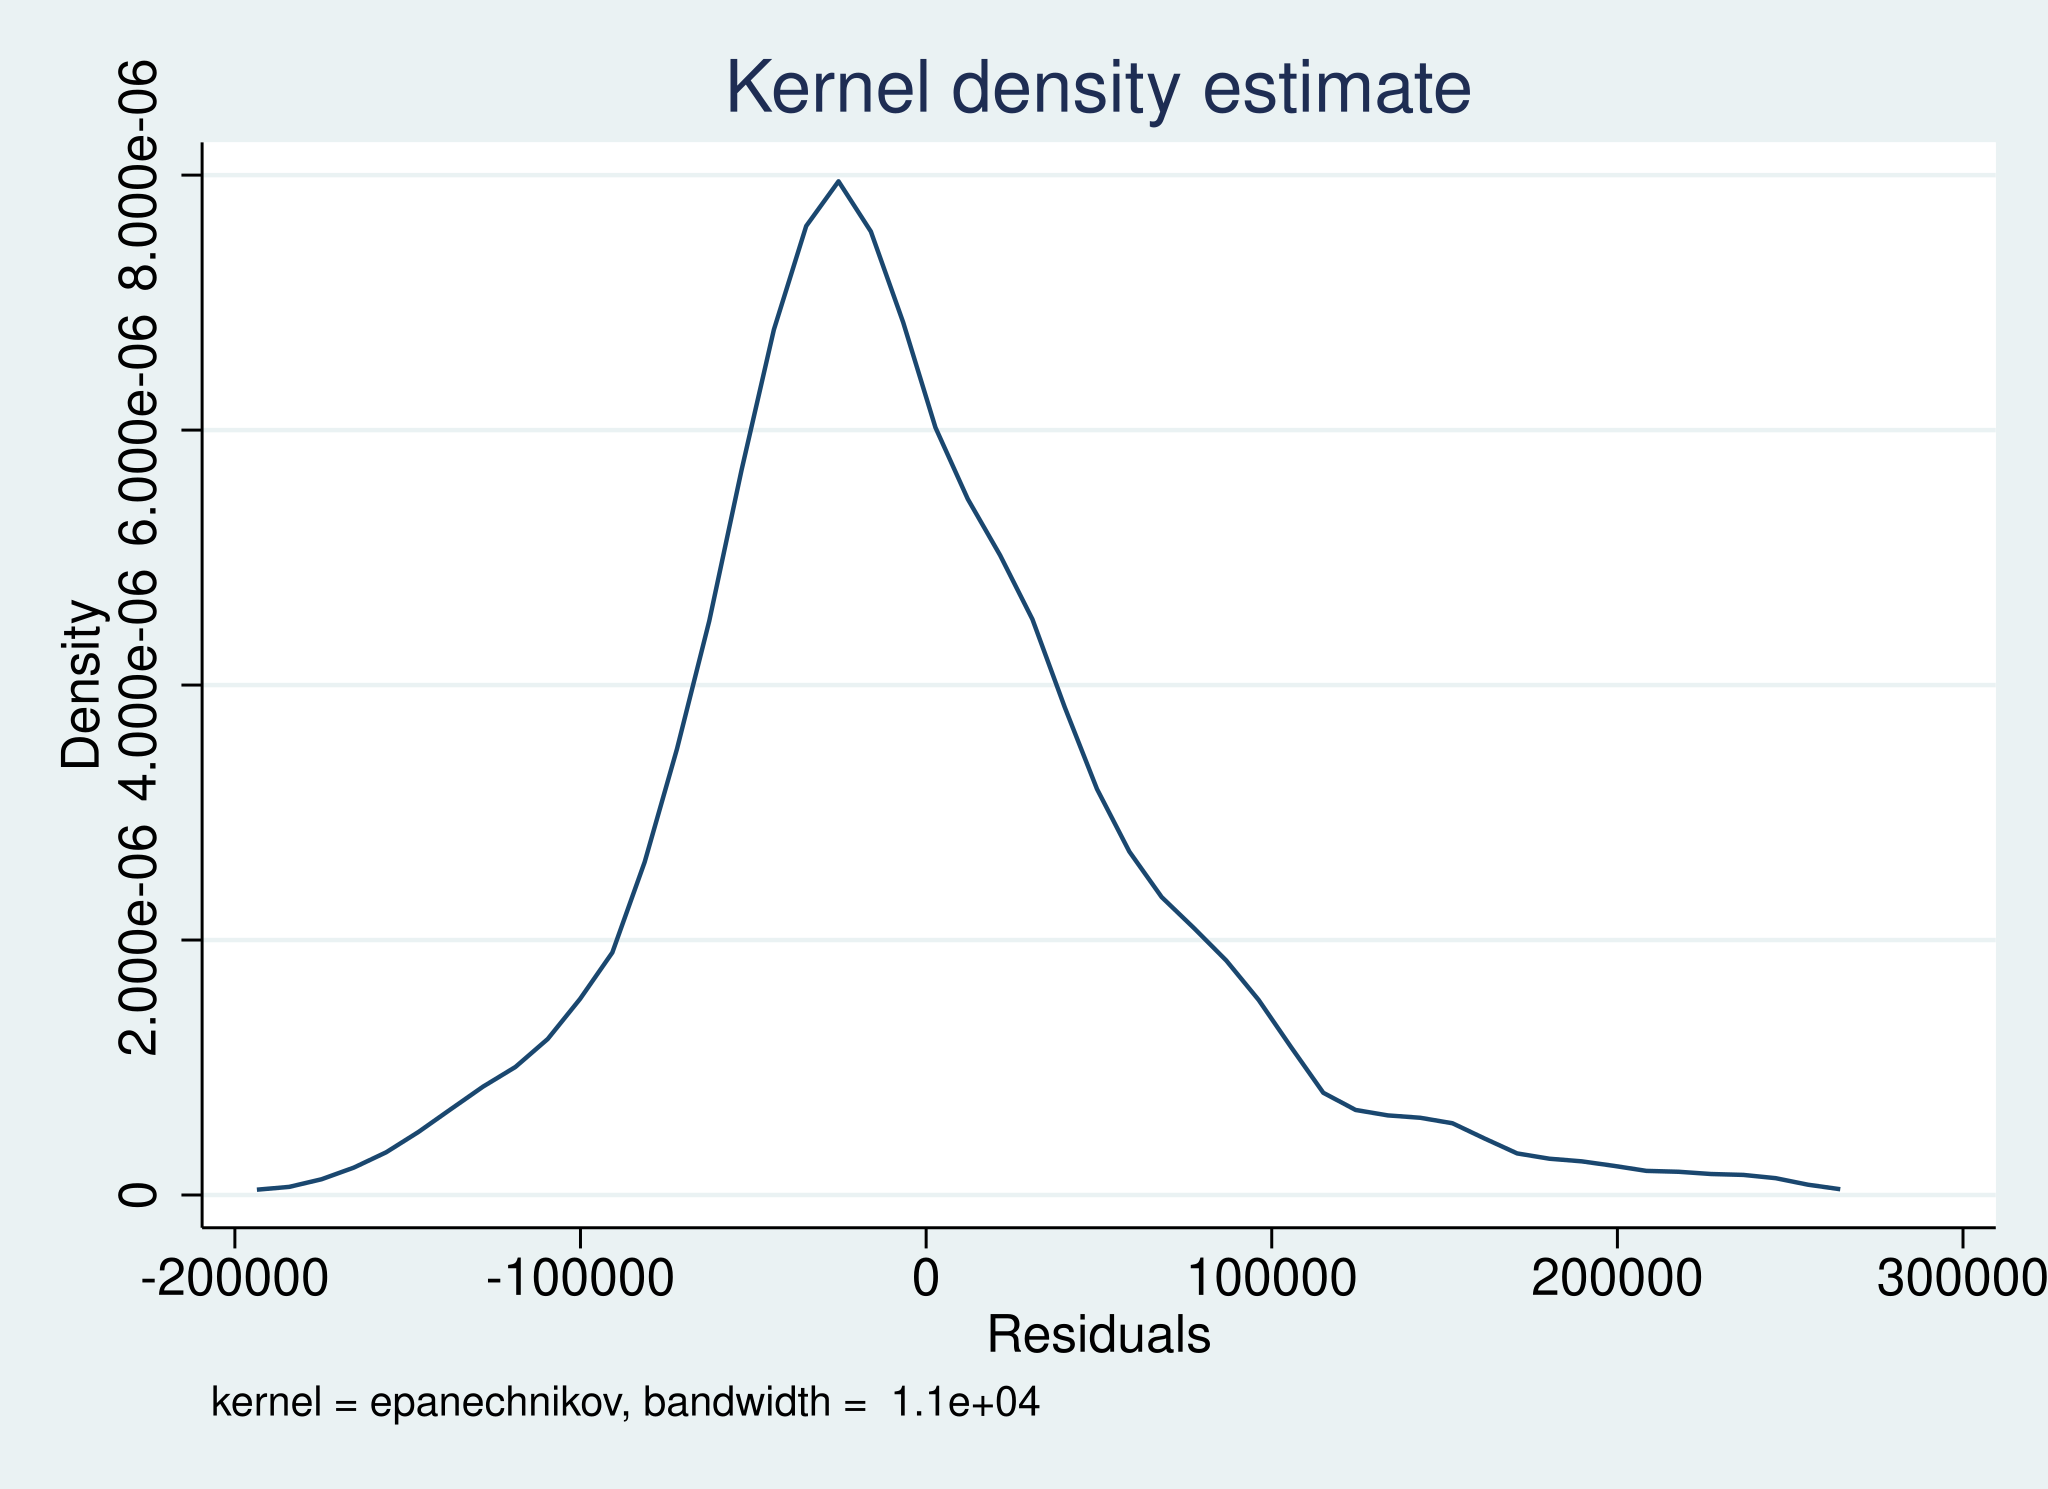

In [140]:
%%stata
// Normalité des résidus
quietly predict resid1, residuals
kdensity resid1


. // Graphique Q-Q
. qnorm resid1, title("Résidus estimés vs résidus normaux (modèle 1)")

. graph export "${outputs}/qqplot__modele1.png", replace 
file E:/Ecole/AS2/Semestre1/Stat_agricole/TP3_elevage_pastoral/TP_elevage/Outpu
> ts/qqplot__modele1.png written in PNG format

. 


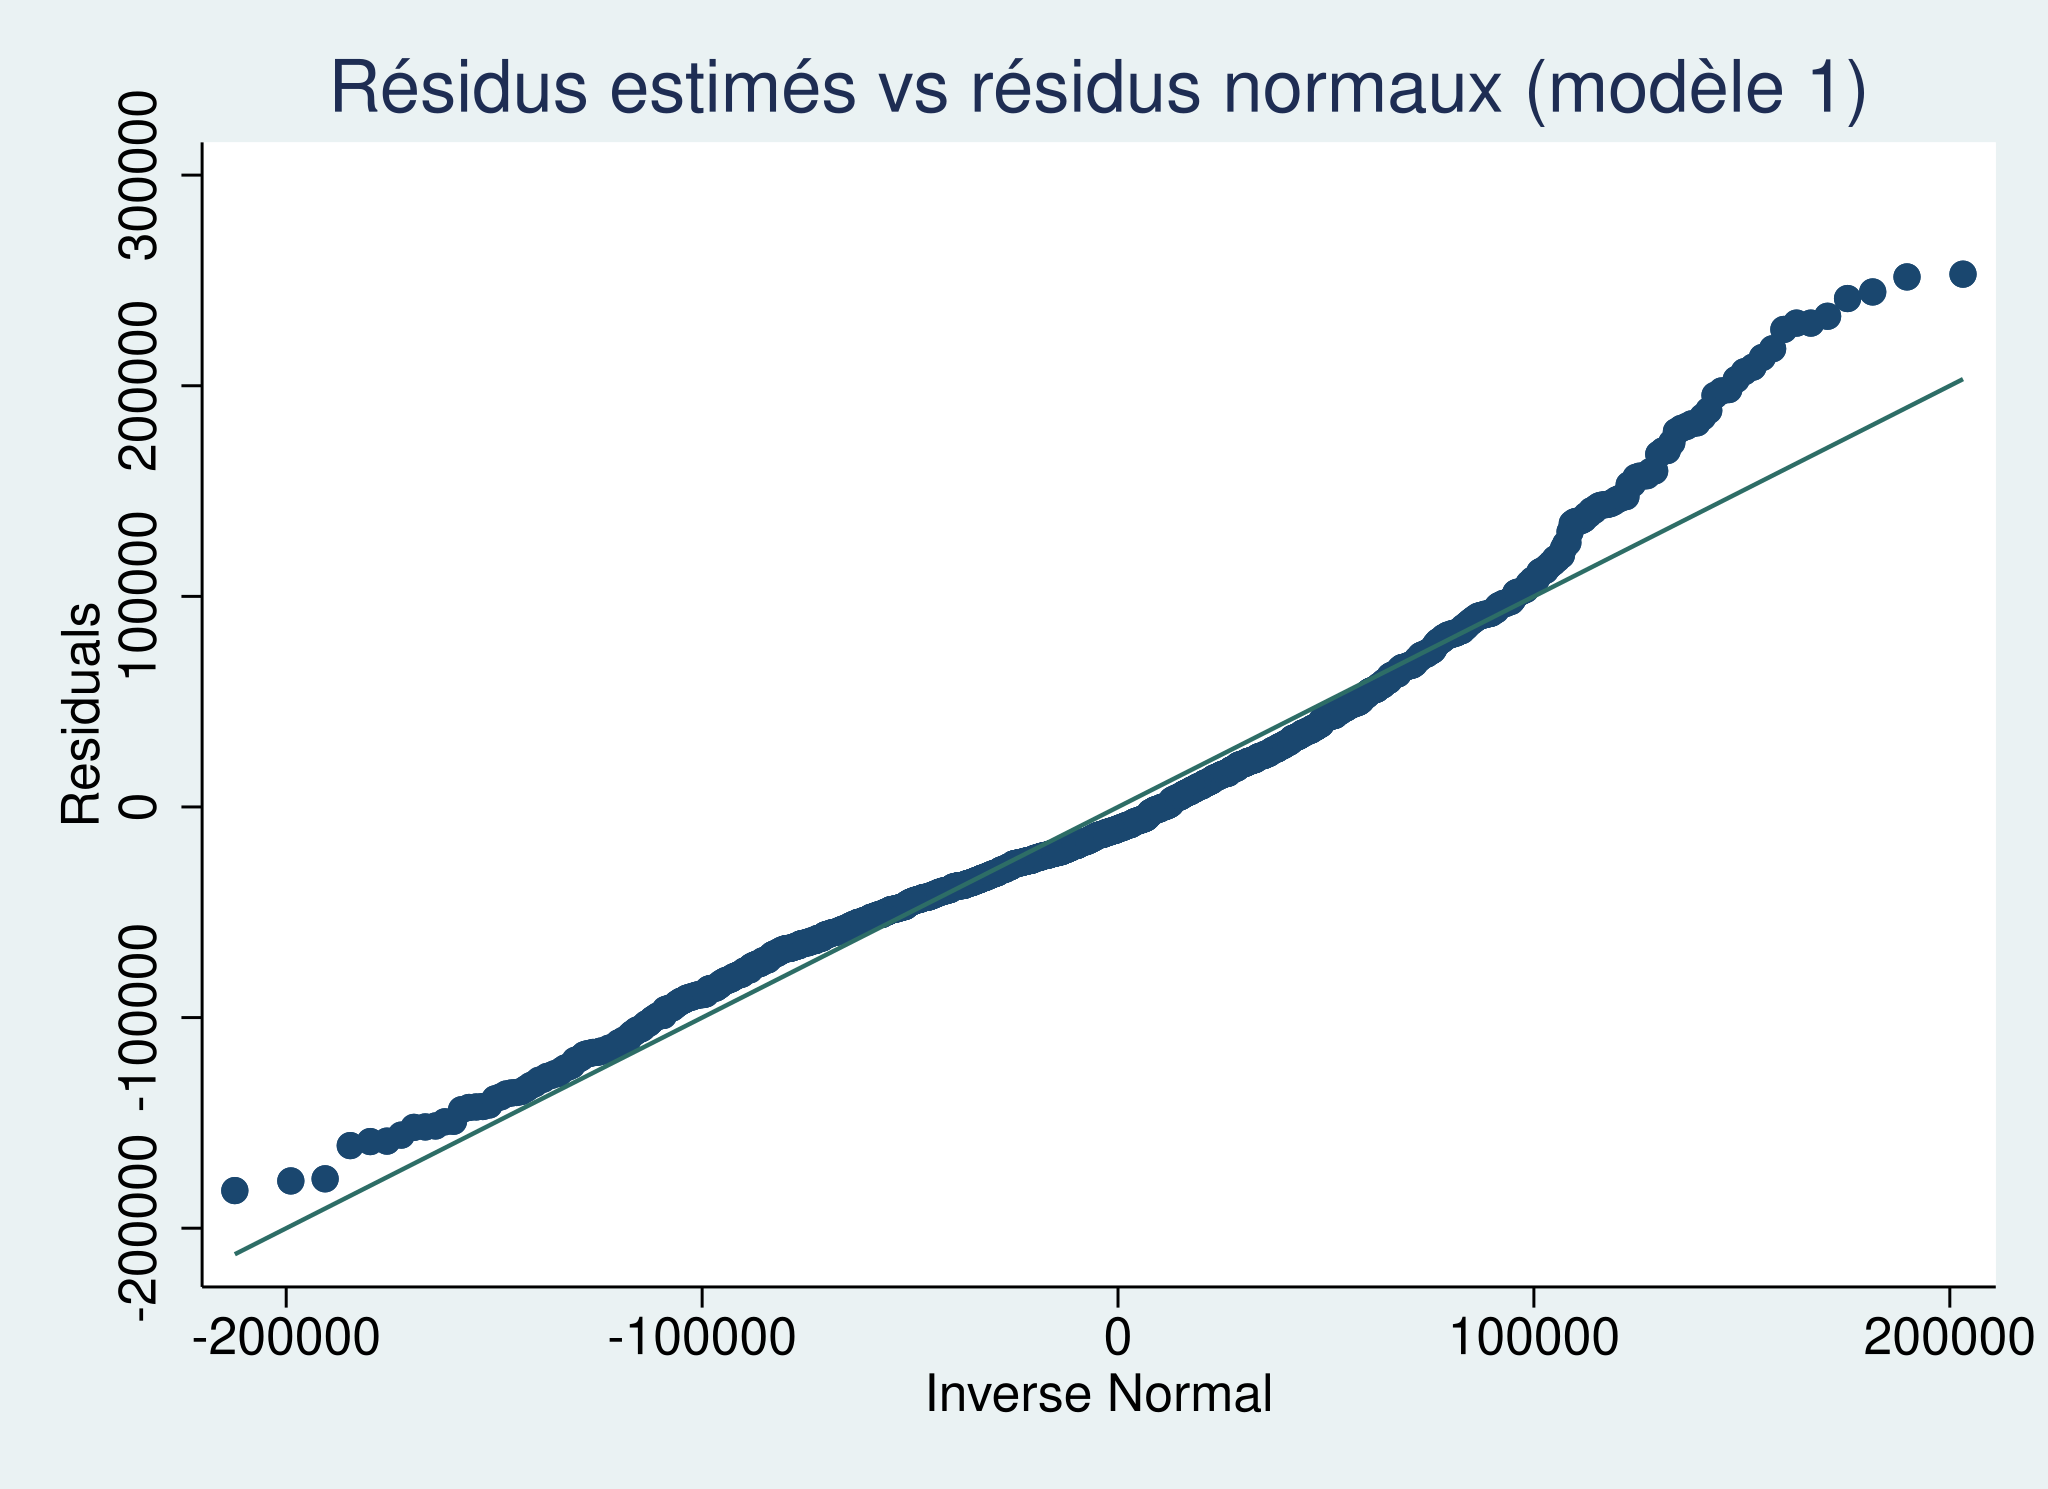

In [141]:
%%stata
// Graphique Q-Q
qnorm resid1, title("Résidus estimés vs résidus normaux (modèle 1)")
graph export "${outputs}/qqplot__modele1.png", replace 

In [142]:
%%stata
// Multicolinéarité
estat vif


. // Multicolinéarité
. estat vif

    Variable |       VIF       1/VIF  
-------------+----------------------
      Age_sd |      1.18    0.844079
        Sexe |      1.17    0.857448
  country_sd |      1.05    0.949687
     Aqui_sd |      1.04    0.963577
     Mois_sd |      1.00    0.995045
-------------+----------------------
    Mean VIF |      1.09

. 


**L'analyse de la multicolinéarité montre que les valeurs du VIF (Variance Inflation Factor) sont toutes inférieures à **10**, ce qui indique qu'il n'y a pas de multicolinéarité significative entre les variables incluses dans le modèle. En particulier, la **moyenne du VIF** est de **1.09**, ce qui est bien en dessous du seuil critique de **10** généralement utilisé pour identifier une multicolinéarité problématique. Les variables les plus fortement corrélées avec les autres variables sont **Age_sd** et **Sexe**, avec des VIF respectifs de **1.18** et **1.17**, ce qui reste acceptable. En somme, les variables incluses dans l'analyse ne montrent pas de signes préoccupants de multicolinéarité, et les résultats du modèle pourront donc être jugés fiables.**


. // Nuage de point de la distribution des residus en fonction de la variable c
> ible
. scatter resid1 Prix, title("Résidus en fonction de la variable cible (Prix) -
>  modèle 1")

. 


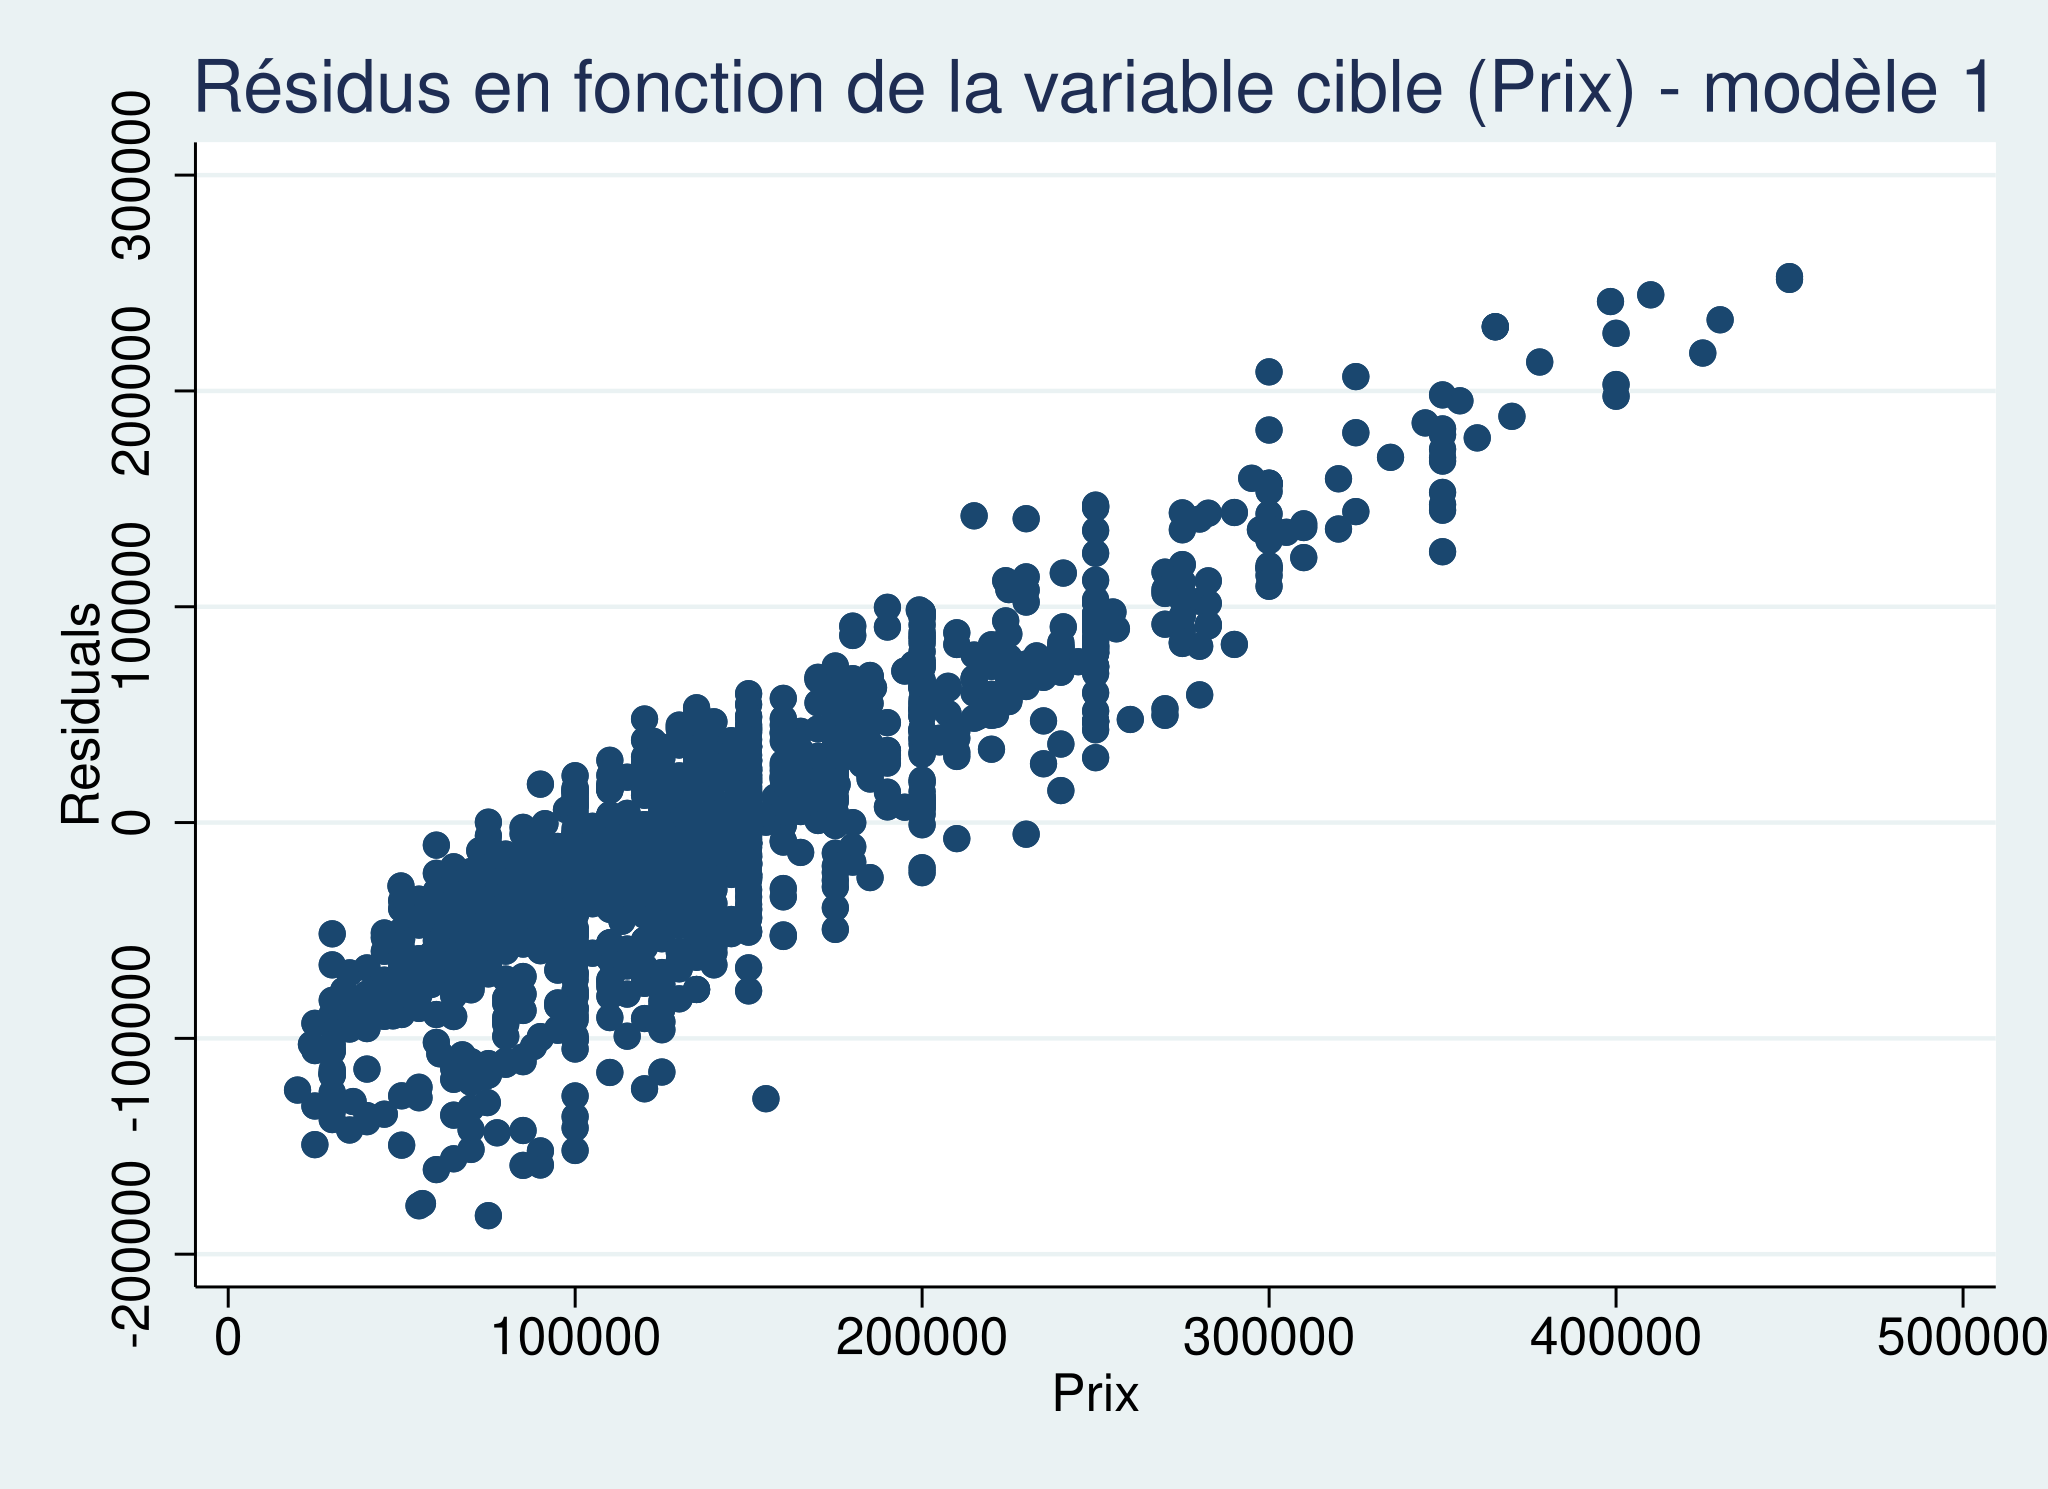

In [143]:
%%stata
// Nuage de point de la distribution des residus en fonction de la variable cible
scatter resid1 Prix, title("Résidus en fonction de la variable cible (Prix) - modèle 1")

**Le nuage des résidus en fonction du prix, montre une certaine correlation positive entre les deux distributions. Plus le prix augmente, plus les résidus sont importants. Cela suggère alors que les résidus ne sont pas distribués de façon aléatoire, revélant ainsi que le modèle est plutôt défaillant.**

In [144]:
%%stata
drop is_outlier

<span style="color:blue;font-weight:bold;font-size:13pt">Modèle 2 </span>

Pour ce modèle, nous traiterons les variables `Sexe`, `Origine`, `Aqui` et `country` comme des variables **catégorielles**. Cela suggère alors que des variables **dummies** seront crées, représentant chacune une modalité des variables ci-dessus mentionnées. Pour les autres prédicteurs, nous utiliserons les valeurs **normalisées**.

In [145]:
%%stata
capture{
// Identification des valeurs extrêmes
gen is_outlier=0
foreach varname in Age_norm Mois_norm{
    * Calculer les bornes inférieure et supérieure pour identifier les valeurs aberrantes
    summarize `varname', detail
    scalar lower_bound = r(p25) - 1.5 * (r(p75) - r(p25))  // Limite inférieure
    scalar upper_bound = r(p75) + 1.5 * (r(p75) - r(p25))  // Limite supérieure
    
    * Créer une variable qui identifie les valeurs aberrantes
    replace is_outlier = cond(`varname' < lower_bound |`varname'  > upper_bound,1,is_outlier)
}
}


. capture{

. 



. reg Prix i.Sexe Age_norm i.Origine i.Aqui Mois_norm i.country if !(is_outlier
> ==1)

      Source |       SS           df       MS      Number of obs   =     1,282
-------------+----------------------------------   F(10, 1271)     =     27.94
       Model |  1.1185e+12        10  1.1185e+11   Prob > F        =    0.0000
    Residual |  5.0880e+12     1,271  4.0031e+09   R-squared       =    0.1802
-------------+----------------------------------   Adj R-squared   =    0.1738
       Total |  6.2065e+12     1,281  4.8450e+09   Root MSE        =     63270

------------------------------------------------------------------------------
        Prix | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        Sexe |
     Female  |  -30154.24   3950.824    -7.63   0.000    -37905.09   -22403.39
    Age_norm |   171058.9   12135.57    14.10   0.000     147250.9    194866.9
             |
     Origin

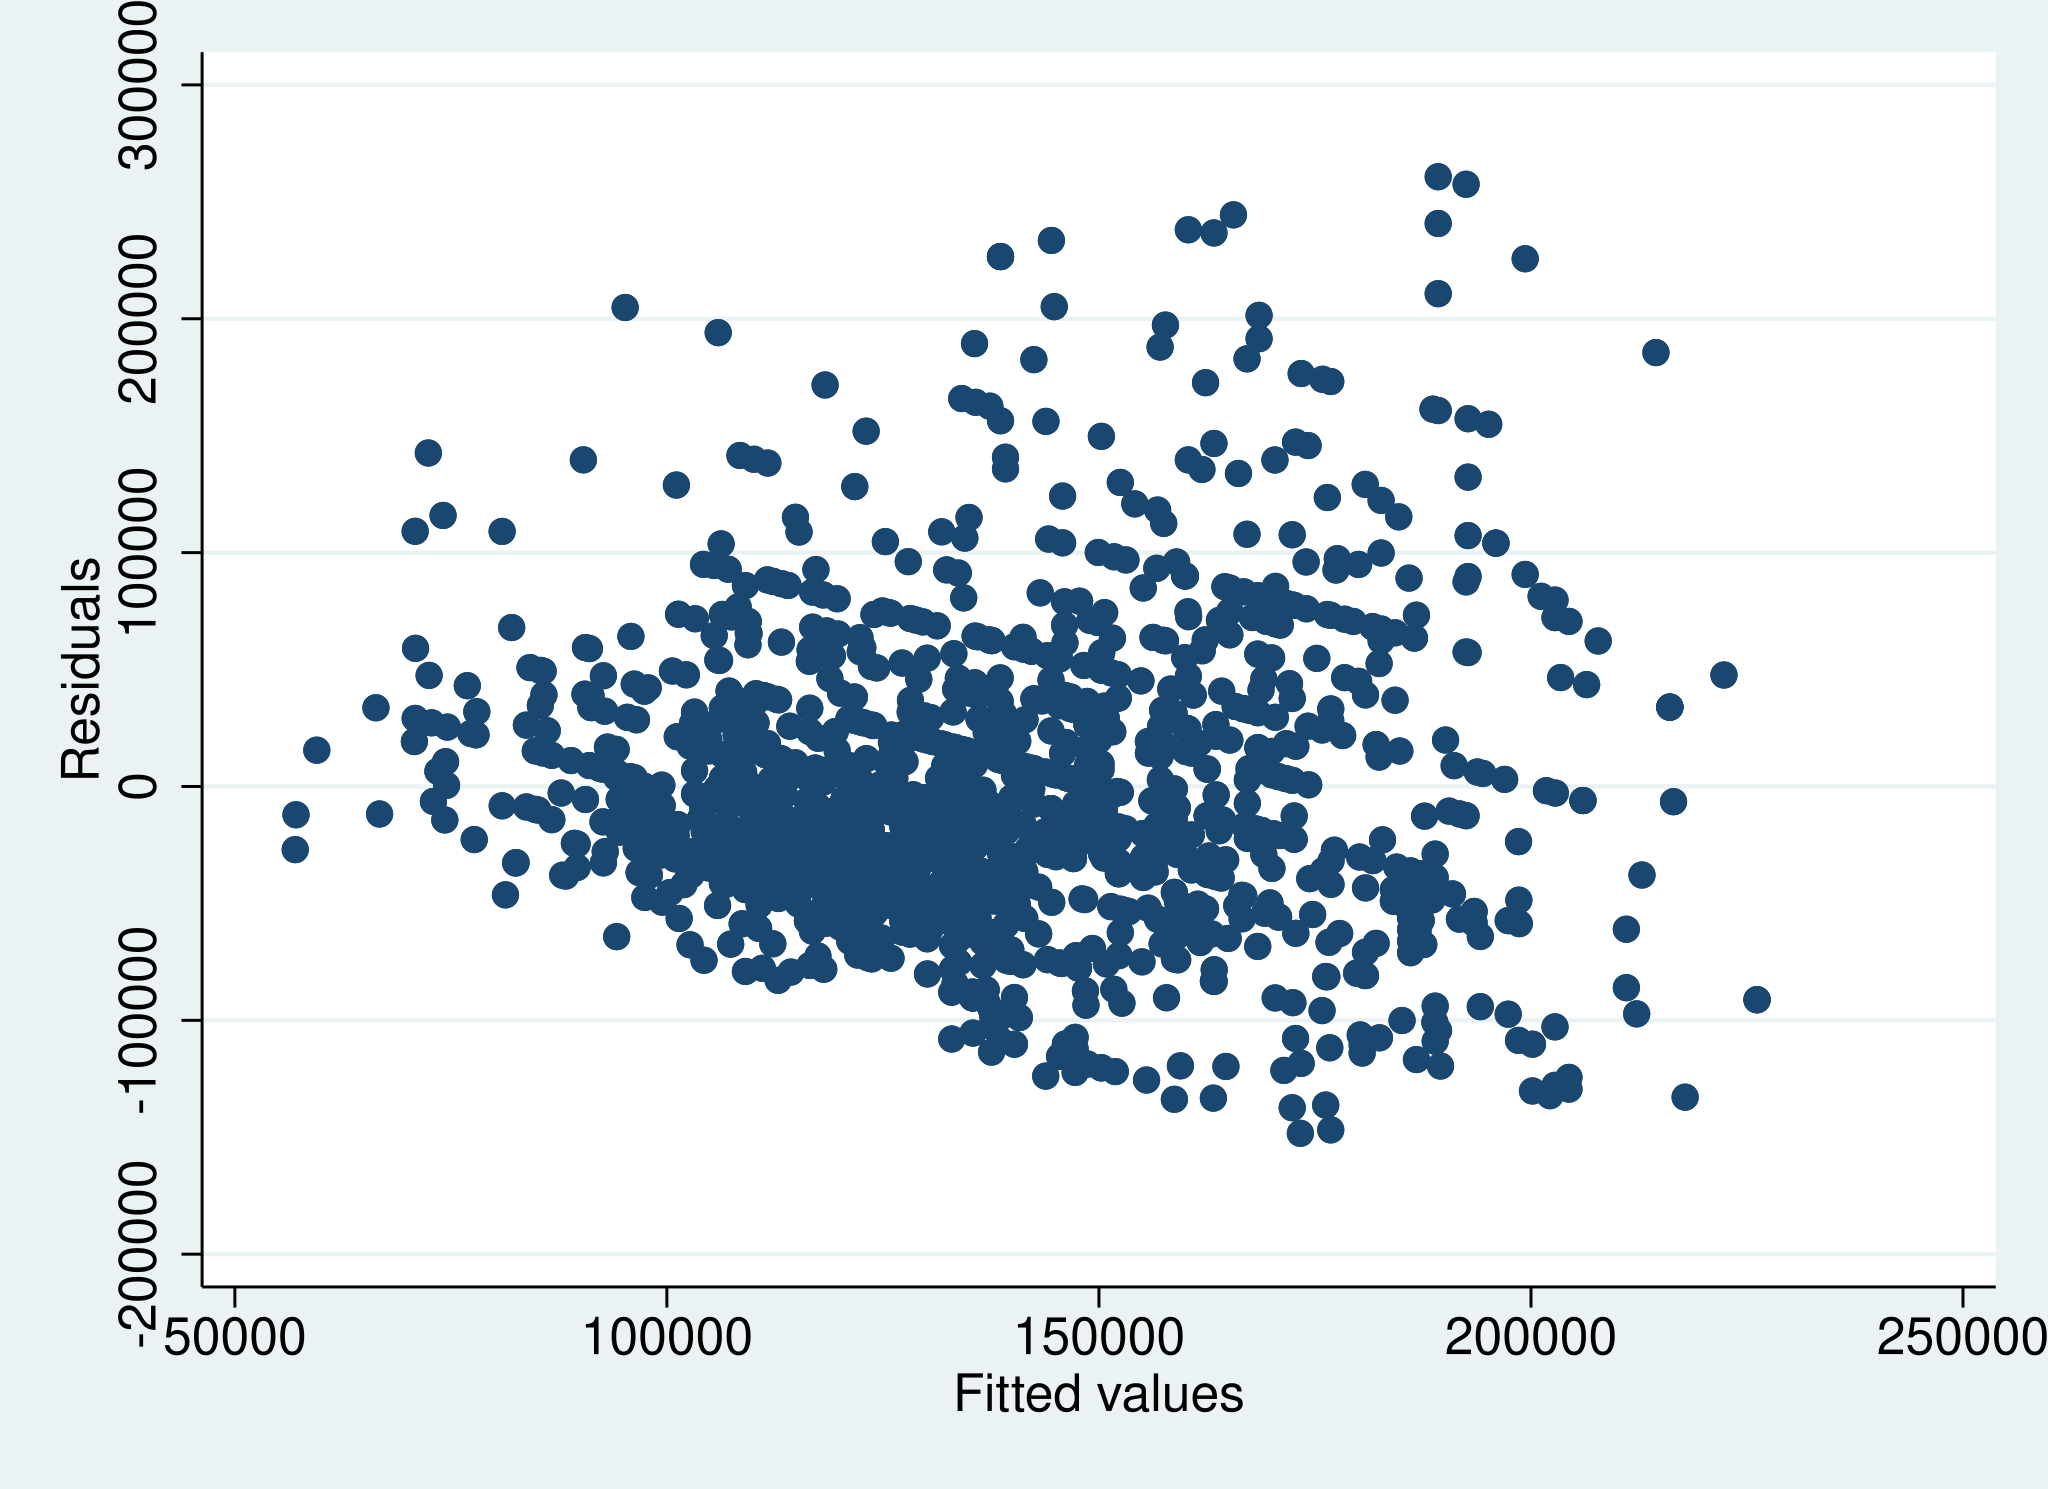

In [146]:
%%stata
reg Prix i.Sexe Age_norm i.Origine i.Aqui Mois_norm i.country if !(is_outlier==1)

// résidus vs valeurs ajustées
rvfplot
graph export "${outputs}/rvfplot_modele2.png", replace


. // Valeurs prédites par le premier modèle
. quietly predict Prix2

.         
. kdensity Prix, lcolor(blue) lwidth(medium) title("Distribution : Observée vs 
> Estimée (modèle 2)") legend(order(1 "Prix Observée" 2 "Prix Estimée")) addplo
> t(kdensity Prix2, lcolor(red) lwidth(medium))

. 


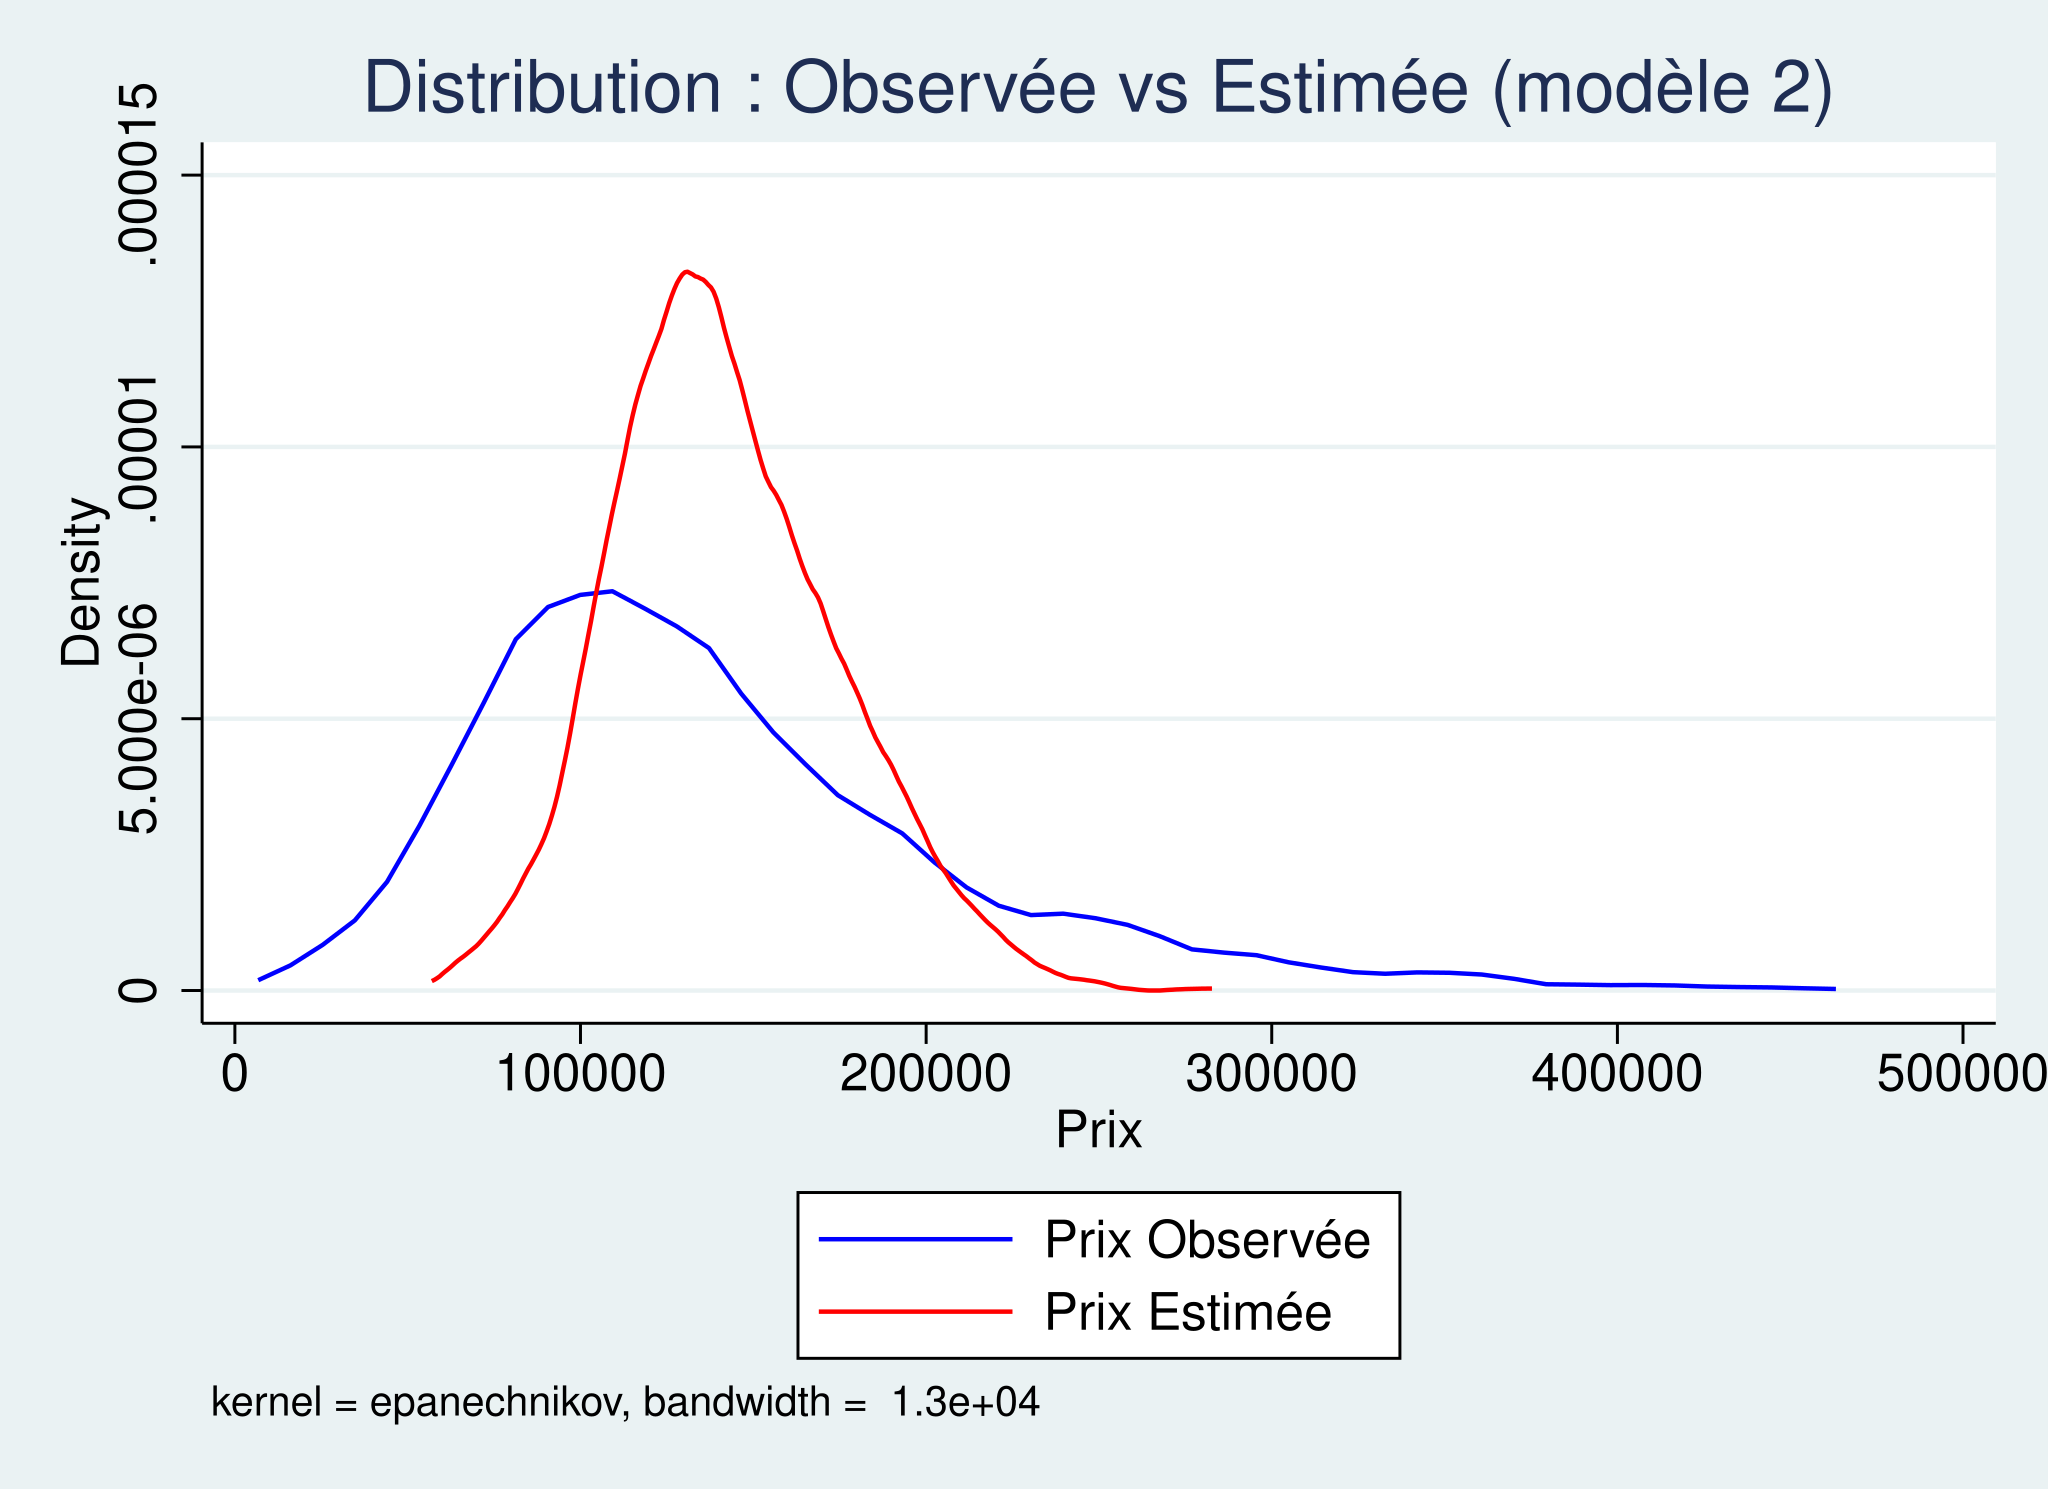

In [147]:
%%stata
// Valeurs prédites par le premier modèle
quietly predict Prix2
	
kdensity Prix, lcolor(blue) lwidth(medium) title("Distribution : Observée vs Estimée (modèle 2)") legend(order(1 "Prix Observée" 2 "Prix Estimée")) addplot(kdensity Prix2, lcolor(red) lwidth(medium))


. // Normalité des résidus
. quietly predict resid2, residuals

. kdensity resid2

. 


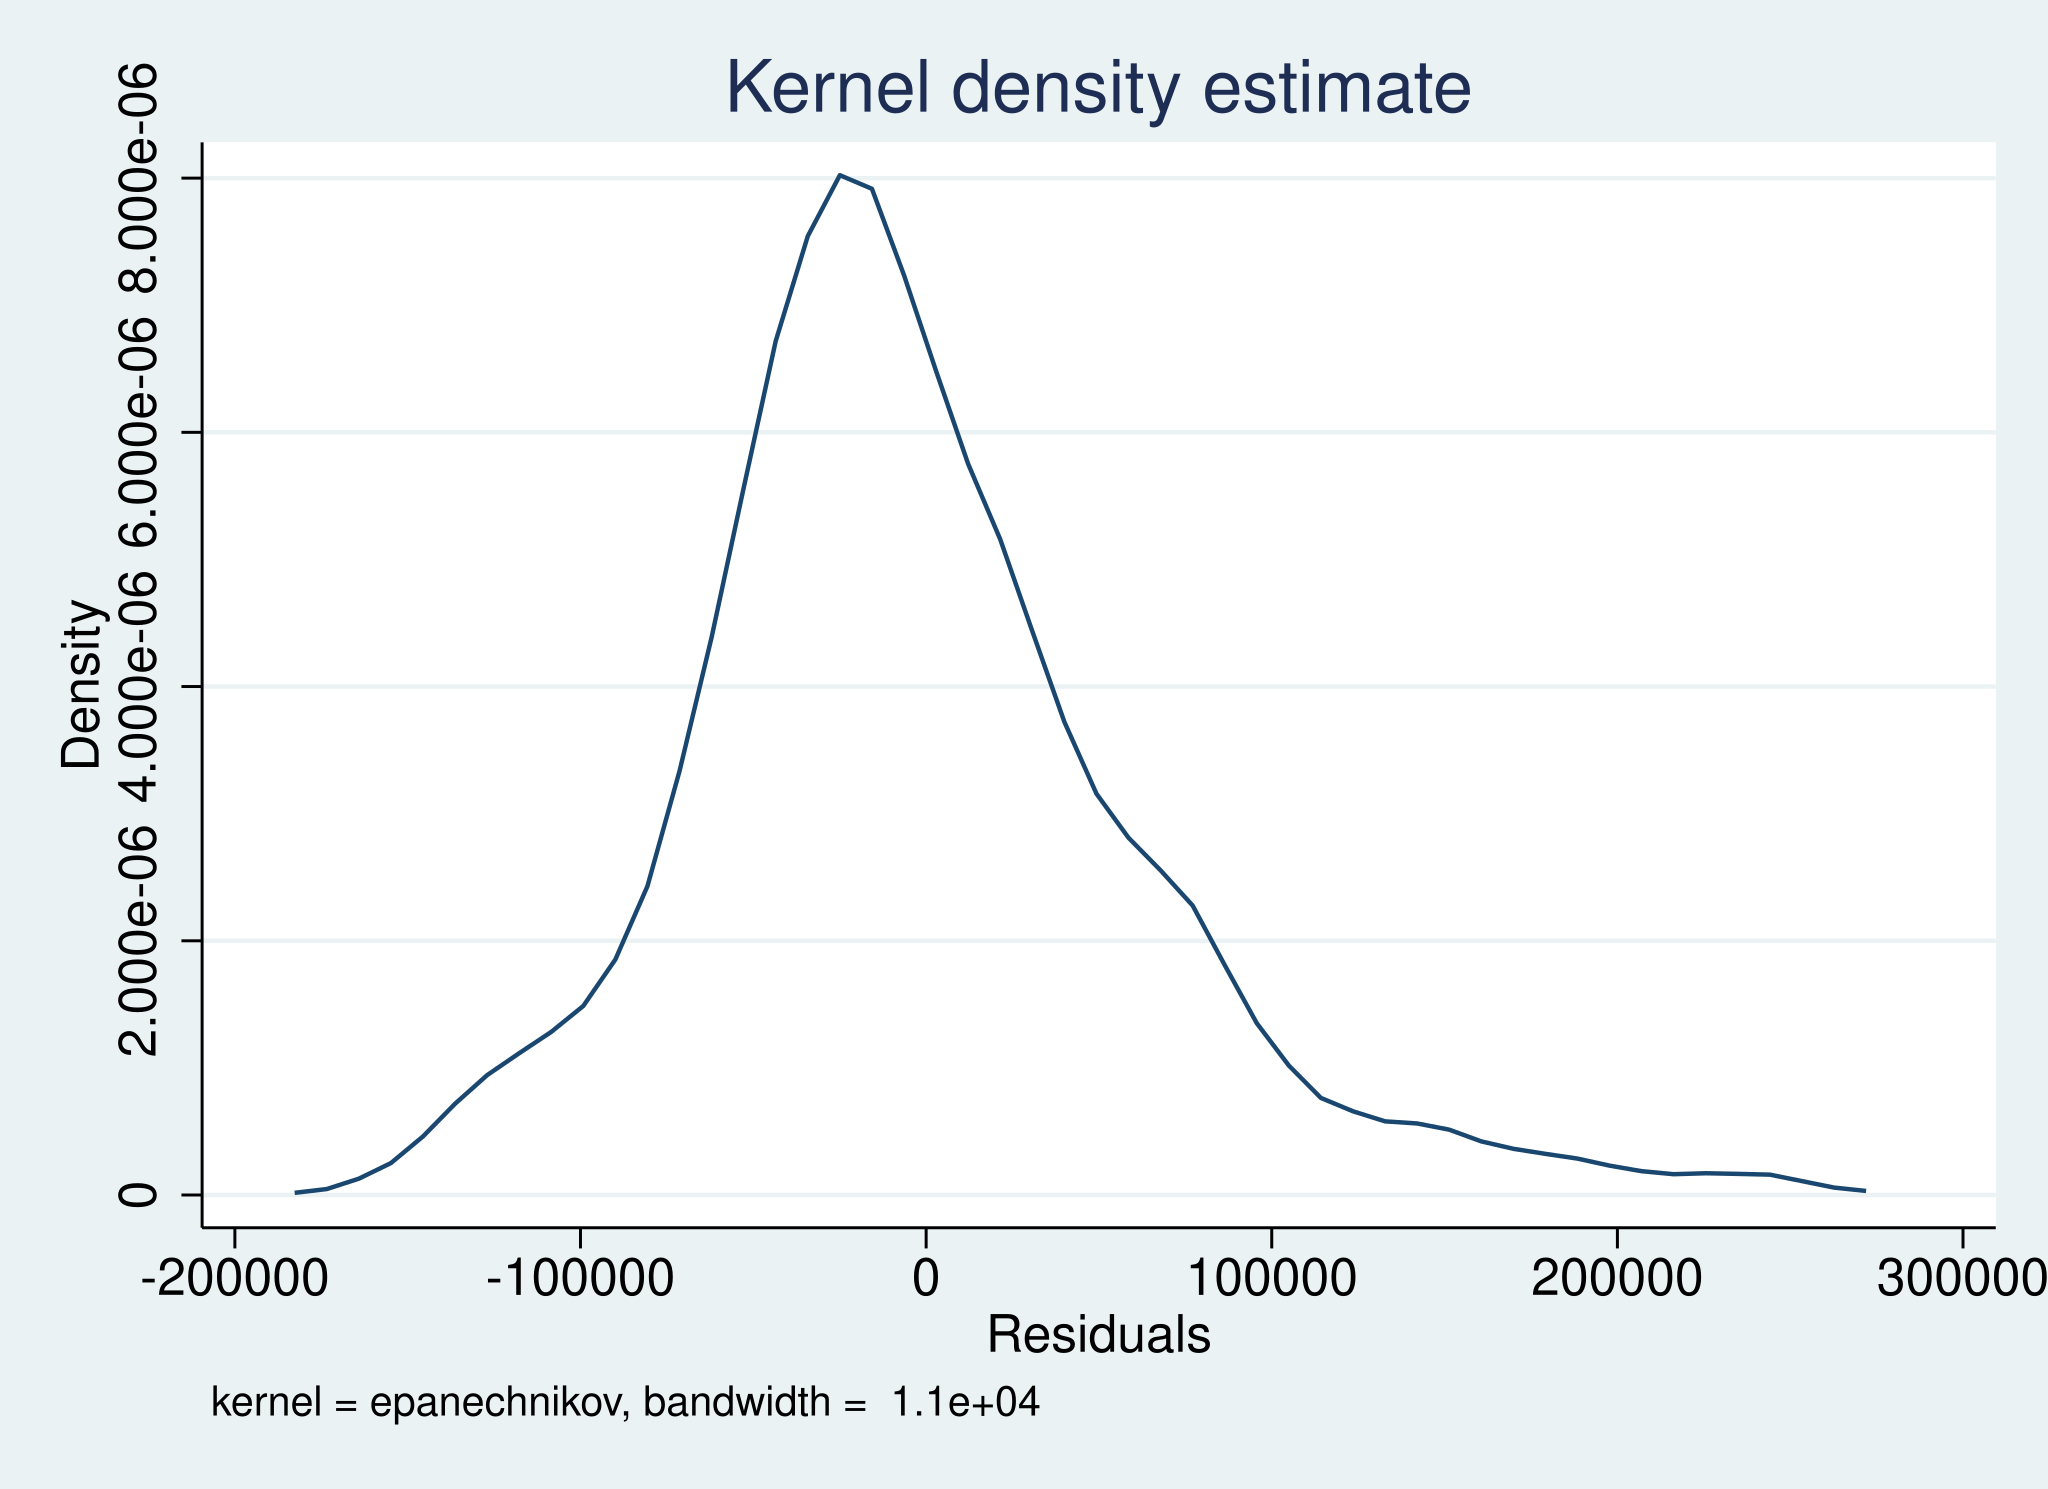

In [148]:
%%stata
// Normalité des résidus
quietly predict resid2, residuals
kdensity resid2

In [ ]:
%%stata
// Graphique Q-Q
qnorm resid2, title("Résidus estimés vs résidus normaux (modèle 2)")


. // Graphique Q-Q
. qnorm resid2, title("Résidus estimés vs résidus normaux (modèle 2)")

. 


In [ ]:
%%stata
// Nuage de point de la distribution des residus en fonction de la variable cible
scatter resid2 Prix, title("Résidus en fonction de la variable cible (Prix) - modèle 2")
graph export "${outputs}/qqplot_modele2.png", replace

In [ ]:
%%stata
drop is_outlier

<span style="color:blue;font-weight:bold;font-size:13pt">Modèle 3 </span>

Pour ce modèle, nous traiterons les variables `Sexe`, `Origine`, `Aqui` et `country` comme des variables **catégorielles**. Cela suggère alors que des variables **dummies** seront crées, représentant chacune une modalité des variables ci-dessus mentionnées. Pour les autres prédicteurs, nous utiliserons les valeurs **standardisées**.

In [ ]:
%%stata
capture{
// Identification des valeurs extrêmes
gen is_outlier=0
foreach varname in Age_sd Mois_sd {
    * Calculer les bornes inférieure et supérieure pour identifier les valeurs aberrantes
    summarize `varname', detail
    scalar lower_bound = r(p25) - 1.5 * (r(p75) - r(p25))  // Limite inférieure
    scalar upper_bound = r(p75) + 1.5 * (r(p75) - r(p25))  // Limite supérieure
    
    * Créer une variable qui identifie les valeurs aberrantes
    replace is_outlier = cond(`varname' < lower_bound |`varname'  > upper_bound,1,is_outlier)
}
}

In [ ]:
%%stata
reg Prix i.Sexe Age_sd i.Origine i.Aqui Mois_sd i.country if !(is_outlier==1)

// résidus vs valeurs ajustées
rvfplot
graph export "${outputs}/rvfplot_modele3.png", replace

In [ ]:
%%stata
// Valeurs prédites par le premier modèle
quietly predict Prix3

kdensity Prix, lcolor(blue) lwidth(medium) title("Distribution : Observée vs Estimée (modèle 3)") legend(order(1 "Prix Observée" 2 "Prix Estimée")) addplot(kdensity Prix3, lcolor(red) lwidth(medium))

In [ ]:
%%stata
// Normalité des résidus
quietly predict resid3, residuals
kdensity resid3

In [ ]:
%%stata
// Graphique Q-Q
qnorm resid3, title("Résidus estimés vs résidus normaux (modèle 3)")	
graph export "${outputs}/qqplot_modele3.png", replace

In [ ]:
%%stata
// Nuage de point de la distribution des residus en fonction de la variable cible
scatter resid3 Prix, title("Résidus en fonction de la variable cible (Prix) - modèle 3")

In [ ]:
%%stata
drop is_outlier

#### 📊 **Résumé de la Modélisation**  

| **Modèle**  | **R-squared** | **Root MSE**  |
|-------------|--------------|--------------|
| **Modèle 1** | **0.1624**   | **64 004**   |
| **Modèle 2** | **0.1802**   | **63 270**   |
| **Modèle 3** | **0.1914**   | **62 978**   |

#### 🔎 **Interprétation**  
La standardisation de variables dans les modèles et l'utilisation de variables **dummies** améliorent légèrement l'ajustement global. En effet, le **R-squared** (coefficient de détermination), qui mesure la proportion de la variance expliquée par le modèle, augmente de **0.1624** dans le Modèle 1 à **0.1914** dans le Modèle 3. Cela indique une meilleure capacité explicative du dernier modèle.  

Parallèlement, la **Root Mean Squared Error (RMSE)** diminue progressivement (**64 004 → 62 978**), ce qui traduit une amélioration de la précision des prédictions. Toutefois, ces améliorations restent relativement modestes, suggérant que d'autres voies de traitement, ou alors d'autres variables explicatives pourraient être explorées pour affiner davantage le modèle.


### **4. Quelles autres variables pourraient être pertinentes à cette régression?**
--------------------------------------------------------------------------------------------------------------------------------------------------------

Pour cette partie, nous évaluerons l'impact de la variable `animal_number` sur les performances globales du modèle.

In [ ]:
%%stata
pwcorr Sexe Age Origine Aqui Mois country animal_number Prix, sig

In [ ]:
%%stata
capture{
// Standardisation
foreach var in animal_number {
    egen mean_`var' = mean(`var')
    egen sd_`var' = sd(`var')
    gen `var'_sd = (`var' - mean_`var') / sd_`var'
    drop mean_`var' sd_`var'
    
    tabstat `var'_sd, stat(count mean sd)
}
}

// Box plot
graph box Age_sd Mois_sd animal_number_sd

<span style="color:blue; font-weight:bold;font-size:13pt">Modélisation</span>

In [ ]:
%%stata
capture{
// Identification des valeurs extrêmes
gen is_outlier=0
foreach varname in Age_sd Mois_sd animal_number_sd{
    * Calculer les bornes inférieure et supérieure pour identifier les valeurs aberrantes
    summarize `varname', detail
    scalar lower_bound = r(p25) - 1.5 * (r(p75) - r(p25))  // Limite inférieure
    scalar upper_bound = r(p75) + 1.5 * (r(p75) - r(p25))  // Limite supérieure
    
    * Créer une variable qui identifie les valeurs aberrantes
    replace is_outlier = cond(`varname' < lower_bound |`varname'  > upper_bound,1,is_outlier)
}
}

In [ ]:
%%stata
reg Prix i.Sexe Age_sd i.Origine i.Aqui Mois_sd i.country animal_number_sd if !(Age_sd > 2 | Mois_sd > 2 | animal_number_sd > 1.75)
	
// résidus vs valeurs ajustées
rvfplot

In [ ]:
%%stata
// Valeurs prédites par le premier modèle
quietly predict Prix4

kdensity Prix, lcolor(blue) lwidth(medium) title("Distribution : Observée vs Estimée (modèle 4)") legend(order(1 "Prix Observée" 2 "Prix Estimée")) addplot(kdensity Prix4, lcolor(red) lwidth(medium))

In [ ]:
%%stata
// Normalité des résidus
quietly predict resid4, residuals
kdensity resid4

In [ ]:
%%stata
// Graphique Q-Q
qnorm resid4, title("Résidus estimés vs résidus normaux (modèle 4)")

In [ ]:
%%stata
// Nuage de point de la distribution des residus en fonction de la variable cible
scatter resid4 Prix, title("Distribution des residus en fonction de la variable cible (Prix) - modèle 4")

#### 🚀 **Performance du Nouveau Modèle**  

- **R-squared** : **0.2060**  
- **Root MSE** : **60 735**  

#### 📊 **Analyse**  
L'ajout de la variable `animal_number` a contribué à améliorer la performance du modèle.  
En effet :  
- Le **R-squared** passe à **0.2060**, indiquant que le modèle explique mieux la variance des données.  
- La **Root MSE** diminue à **60 735**, traduisant une réduction de l'erreur de prédiction.  

Ces résultats suggèrent que la prise en compte du **nombre d'animaux** apporte une information pertinente pour déterminer le prix de vente. 📈


<h2 style="color:blue; font-size:18pt; font-weight:bold;font-family: 'Times New Roman', Times, serif;"> PARTIE 4: ELEVAGE ET EMIGRATION </h2>

**Tâches:**

1. Pour chaque ménage, calculer le nombre de personnes qui ont émigré durant les 5 années qui
ont précédé l’enquête.
2. calculer l’intensité de l’émigration en rapportant le nombre d’émigrés à la taille du ménage.
Résumer ce taux par pays.
3. Quelles sont les principales destinations des fils d’éleveurs du Sahel?
4. Quelles sont les destinations principales des émigrés?
5. Corréler l’intensité de l’émigration avec l’indicateur de viabilité de l’élevage. Conclure

**NB :** La base utilisée dans cette partie est la base **emigration_cleaned.dta**

In [ ]:
%%stata
use "${data}/emigration_cleaned.dta", clear

### **1. Pour chaque ménage, calculer le nombre de personnes qui ont émigré durant les 5 années qui ont précédé l’enquête.**
--------------------------------------------------------------------------------------------------------------------------------------------------------

Tout d'abord, nous avons remplacer les années valant **99** par des missing values. Ensuite, nous avons utilisé la variable `Liensdeparenté` afin de compter le nombre de personnes ayant émigré sans répétition, et en spécifiant que le nombre d'années doit être inférieur à 5. On constate que ce nombre se situe entre **0 et 4**, pour l'ensemble des ménages de notre base.

In [ ]:
%%stata
capture{
mvdecode Années, mv(99) // Remplacer les années valant 99 par missing
bys ID: egen nb_emigre = count(Liensdeparenté) if !missing(Années) & !(Liensdeparenté==" ") & Années <= 5
}
tabstat nb_emigre, by(ID) s(n) 

### **2. calculer l’intensité de l’émigration en rapportant le nombre d’émigrés à la taille du ménage. Résumer ce taux par pays.**
--------------------------------------------------------------------------------------------------------------------------------------------------------

Pour effectuer ce calcul, nous avons besoin de la **taille du ménage**, disponible dans la base **FT_cleaned.dta**. Ainsi, nous allons **fusionner** la base actuelle (**emigration_cleaned.dta**) avec cette dernière en utilisant la variable `ID` comme clé de correspondance.  

L'intensité de l'émigration est la plus élevée en **Mauritanie (16%)** et au **Niger (14%)**, dépassant la moyenne globale de **11,17%**. En revanche, les taux d'émigration par ménage sont relativement plus faibles au **Burkina Faso (10%)** et au **Sénégal (9%)**. Quant au **Mali**, son taux d’émigration (**11%**) est proche de la moyenne globale.

In [ ]:
%%stata
capture{
merge m:1 ID using "${data}/FT_cleanID.dta" // Merger la base actuelle avec la base FT_cleanID.dta
//tab _merge
keep if _merge == 3 // Conserver uniquement les observations ayant trouvé une correspondance
drop _merge

// Calcul de la taille du ménage 
egen HHsize =rsum(HommesadultesHA FemmesadultesFA VieuxV Garçonsde12ansG12 Fillesde12ansF12)

//codebook HHsize
//tabstat HHsize, by(Région) s(mean sd p50 min max n)
// En moyenne, la taille des ménages observés varie entre 9 et 39 individus

foreach var of varlist HommesadultesHA FemmesadultesFA VieuxV Garçonsde12ansG12 Fillesde12ansF12 {

replace `var'=0 if missing(`var') // On remplace les missing par '0', pour la variable considérée

}

// Calcul de la taille des ménages en équivalent adulte 
gen HHsizeEA = HommesadultesHA + FemmesadultesFA+ VieuxV +0.75*(Garçonsde12ansG12+Fillesde12ansF12)
    
// Intensité de l'émigration
gen intensité_emigr = nb_emigre / HHsize
}

// Résumer le taux par pays
tabstat intensité_emigr, by(country) s(mean)
bys country: egen intensité_emigr_pays = mean(intensité_emigr)
tab intensité_emigr_pays country


In [ ]:
%%stata
capture{
tabstat intensité_emigr, s(mean)
graph bar (mean) intensité_emigr, over(country, sort(1) descending) bar(1,color(blue)) blabel(bar,format(%9,2f)) yline(.1117379,lcolor(red) lwidth(medium) lpattern(solid)) ylabel(0(0.05)0.25 0.1117 , add) ytitle("Valeur") title("Intensité de l'émigration par pays") note("Base fournie, calculs de l'auteur")
graph export "${outputs}/intensite_emigration.png", replace
}

### **3. Quelles sont les principales destinations des fils d’éleveurs du Sahel?**
--------------------------------------------------------------------------------------------------------------------------------------------------------



In [ ]:
%%stata
tab destination if Liensdeparenté == "Fils" & migr_number >=1

### **4. Quelles sont les destinations principales des émigrés?**
--------------------------------------------------------------------------------------------------------------------------------------------------------

L’analyse des destinations principales des émigrés montre que la majorité d’entre eux restent dans leur pays d’origine (**36,81%**), tandis qu’une part importante migre vers les **pays côtiers** de la région (**26,92%**). L’émigration vers d’autres zones sahéliennes représente également une part non négligeable (**18,68%**). En revanche, les destinations plus éloignées, comme l’**Europe et les États-Unis (7,14%)**, l’**Afrique du Nord (5,49%)** et l’**Afrique centrale (4,95%)**, restent minoritaires. Cette répartition met en évidence une mobilité principalement intra-régionale, avec une migration hors du continent relativement faible.

In [ ]:
%%stata
tab destination if migr_number >=1, sort

In [ ]:
%%stata
graph bar (percent) migr_number, over(destination,sort(1) label(angle(45))) bar(1, color(blue)) blabel(bar,format(%9,2f)) ytitle("Valeur (%)") title("Destinations principales des émigrés") note("Base fournie, calculs de l'auteur")
graph export "${outputs}/destinations_emigres.png", replace

### **5. Corréler l’intensité de l’émigration avec l’indicateur de viabilité de l’élevage. Conclure**
--------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
%%stata
capture{
// Caluler la taille UBT et l'indicateur de viabilité
// Remplacer les tailles valant 999 par missing
foreach var in transh_Bovins transh_Ovins transh_Caprins transh_Camelins{
    mvdecode `var', mv(999)
}

// Calcul de la taille UBT
gen taille_UBT = 0.5*transh_Bovins + 0.1*transh_Ovins + 0.1*transh_Caprins + 0.7*transh_Camelins 

// Indicateur de viabilité
gen UBT_par_EA = taille_UBT/HHsizeEA
}

<span style="color:blue; font-weight:bold; font-size:13pt">Coefficient de correlation linéaire</span>

Le coefficient de corrélation linéaire entre l'**indicateur de viabilité de l'élevage** et l'**intensité de l'émigration** est de **0,3834**, avec une p-value inférieure à **1%**, suggérant une relation statistiquement significative entre ces deux variables. Cette corrélation positive, bien que modérée, indique que dans les contextes où l'élevage est plus viable (UBT/EA élevé), l'intensité de l'émigration tend également à être plus forte. 

In [ ]:
%%stata
pwcorr intensité_emigr UBT_par_EA, sig

<span style="color:blue; font-weight:bold; font-size:13pt">Coefficient de correlation de spearman</span>

L’analyse de la corrélation de Spearman entre **l’intensité de l’émigration** et **l’indicateur de viabilité de l’élevage (UBT/EA)** révèle un coefficient de **0,2459**, avec une p-value de **0,0016**. Cette valeur, bien que faible, indique une corrélation positive et statistiquement significative au seuil de **5%**, suggérant une association entre les deux variables. Autrement dit, une viabilité plus élevée de l’élevage est associée à une intensité migratoire légèrement plus forte. Cependant, cette relation reste faible, ce qui implique que d’autres facteurs structurels et contextuels influencent probablement l’émigration des ménages d’éleveurs.

Ce coefficient est privilégié car il est plus robuste face à la présence éventuelle d'outliers. De plus, étant non paramétrique, il ne fait aucune hypothèse sur la distribution des données.

In [ ]:
%%stata
spearman intensité_emigr UBT_par_EA 

<span style="color:blue; font-weight:bold; font-size:13pt">Méthode d'imputation des valeurs manquantes par regression</span>

La méthode des imputations multiples, prend en compte les relations entre les variables `UBT_par_EA` et `intensité_emigr`, et permet d'estimer de manière robuste les valeurs manquantes et de mieux comprendre l'impact de `UBT_par_EA` sur l'intensité de l'émigration. En générant cinq nouvelles variables imputées pour chaque observation manquante, cette approche tient compte des dépendances linéaires entre les variables, améliorant ainsi la précision des estimations. L'imputation par régression permet de combler les lacunes dans les données tout en conservant les relations statistiques présentes entre les variables.

Dans le cadre de l'analyse globale, les résultats montrent que l'intensité de l'émigration est modérément liée à `UBT_par_EA`, avec une corrélation positive de **0,40 à 0,47** pour les différentes imputations. Cette méthode non seulement remplace les données manquantes mais aussi renforce la cohérence des résultats en utilisant les informations disponibles dans les autres variables, ce qui permet d'obtenir une analyse plus fiable. Ainsi, les relations entre les variables sont mieux prises en compte, et les effets de `UBT_par_EA` sur l'émigration peuvent être observés de manière plus robuste.

In [ ]:
%%stata
capture{
// Identifier les valeurs manquantes
misstable summarize intensité_emigr UBT_par_EA

// Imputer les valeurs manquantes par regression
mi set wide
mi register imputed intensité_emigr UBT_par_EA
mi impute chained (regress) intensité_emigr UBT_par_EA, add(5) // générer les nouvelles variables

mi estimate: regress intensité_emigr UBT_par_EA
}

mi xeq: correlate intensité_emigr UBT_par_EA // On teste la correlation pour chaque variable générée

<span style="color:red; font-weight:bold; font-size:14pt">Conclusion</span>

En conclusion, les résultats des différents tests statistiques confirment une relation significative entre l'**intensité de l'émigration** et l'**indicateur de viabilité de l'élevage** (`UBT_par_EA`). Le test de corrélation de Pearson (**pwcorr**) a montré une corrélation modérée, positive et significative entre ces deux variables, indiquant que des améliorations dans la viabilité de l'élevage, mesurée par l'`UBT_par_EA`, sont associées à une augmentation de l'intensité de l'émigration. Le coefficient de **Spearman**, qui évalue la relation monotone, a renforcé cette observation en indiquant également une relation positive modérée. Enfin, la **méthode d'imputation multiple**, qui a permis de traiter les valeurs manquantes par régression, a montré que l'UBT_par_EA reste une variable significativement associée à l'intensité de l'émigration, même après l'imputation des données manquantes. Cette approche a permis de traiter efficacement les valeurs manquantes tout en conservant la robustesse des résultats. En résumé, **l'indicateur de viabilité de l'élevage (`UBT_par_EA`) apparaît comme un facteur influençant l'intensité de l'émigration**, et les analyses menées ont permis de solidifier cette conclusion à travers plusieurs méthodes statistiques.

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Fin du TP

---

### Merci de votre attention !

Ce travail a été réalisé par **NZONDE David Christ** et **Armand DJEKONBE**, élèves analystes statisticiens.

---

**Fin du Notebook** 

[**Voir la présentation**](https://www.canva.com/design/DAGdfpFnLzg/sZgd_KZvDhxL-pyDmIll3Q/view?utm_content=DAGdfpFnLzg&utm_campaign=designshare&utm_medium=link2&utm_source=uniquelinks&utlId=h1c1485d653)
